##  Configuration Initiale

Cette cellule désactive les avertissements Python pour une meilleure lisibilité des résultats.

In [1]:
import warnings
warnings.filterwarnings('ignore')

##  Importation des Bibliothèques

Importation de toutes les bibliothèques nécessaires pour l'analyse :
- **pandas, numpy** : manipulation de données
- **matplotlib, seaborn** : visualisations
- **sklearn** : préprocessing et machine learning
- **scipy** : analyses statistiques

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import norm
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier

##  Chargement et Exploration du Dataset

Chargement du fichier CSV contenant les données RH et affichage des premières informations :
- Structure du dataset (types de colonnes, dimensions)
- Aperçu des premières lignes

In [3]:
Employee = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition_dirty.csv")
Employee.info()
print("Avant nettoyage :", Employee.shape)
print("\nAperçu du dataset :")
Employee.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1485 entries, 0 to 1484
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   float64
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   float64
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   float64
 6   Education                 1470 non-null   float64
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   float64
 9   EmployeeNumber            1470 non-null   float64
 10  EnvironmentSatisfaction   1470 non-null   float64
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   float64
 13  JobInvolvement            1470 non-null   float64
 14  JobLevel

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,1.0,1.0,...,1.0,80.0,0.0,8.0,0.0,1.0,6.0,4.0,0.0,5.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,37.0,Yes,Travel_Rarely,1373.0,Research & Development,2.0,2.0,Other,1.0,4.0,...,2.0,80.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0
3,33.0,No,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,1.0,5.0,...,3.0,80.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0
4,27.0,No,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,1.0,7.0,...,4.0,80.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0


##  Calcul des Valeurs Manquantes

Analyse détaillée des valeurs manquantes par colonne :
- Pourcentage de valeurs manquantes par variable
- Total global des valeurs manquantes dans le dataset

In [4]:
# Pourcentage par colonne
missing_percent = (Employee.isna().sum() / len(Employee)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

# Total global de valeurs manquantes
total_missing = Employee.isna().sum().sum()
total_cells = Employee.shape[0] * Employee.shape[1]
total_missing_percent = (total_missing / total_cells) * 100

print("\n Pourcentage de valeurs manquantes par colonne :\n")
print(missing_percent)

print("\n Total de valeurs manquantes dans le dataset :", total_missing)
print(f"Ce qui représente {total_missing_percent:.2f}% du total des cellules.\n")


 Pourcentage de valeurs manquantes par colonne :

Age                         1.010101
Attrition                   1.010101
BusinessTravel              1.010101
DailyRate                   1.010101
Department                  1.010101
DistanceFromHome            1.010101
Education                   1.010101
EducationField              1.010101
EmployeeCount               1.010101
EmployeeNumber              1.010101
EnvironmentSatisfaction     1.010101
Gender                      1.010101
HourlyRate                  1.010101
JobInvolvement              1.010101
JobLevel                    1.010101
JobRole                     1.010101
JobSatisfaction             1.010101
MaritalStatus               1.010101
MonthlyIncome               1.010101
MonthlyRate                 1.010101
NumCompaniesWorked          1.010101
Over18                      1.010101
OverTime                    1.010101
PercentSalaryHike           1.010101
PerformanceRating           1.010101
RelationshipSatisfaction

##  Visualisation Graphique des Valeurs Manquantes

Création d'un diagramme circulaire (pie chart) pour visualiser la proportion de valeurs manquantes vs présentes.

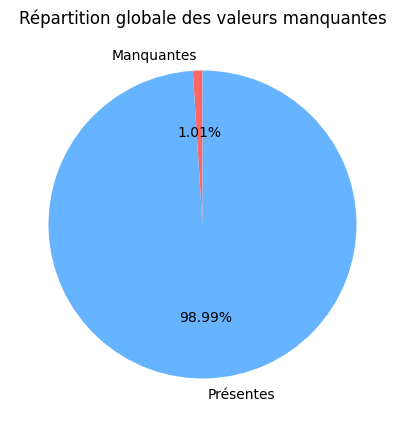

In [5]:
total_cells = Employee.shape[0] * Employee.shape[1]
total_missing = Employee.isna().sum().sum()
total_filled = total_cells - total_missing

plt.figure(figsize=(5,5))
plt.pie(
    [total_missing, total_filled],
    labels=["Manquantes", "Présentes"],
    colors=["#ff6666", "#66b3ff"],
    autopct="%.2f%%",
    startangle=90
)
plt.title("Répartition globale des valeurs manquantes")
plt.show()


##  Suppression des Valeurs Manquantes

Nettoyage du dataset en supprimant toutes les lignes contenant au moins une valeur manquante. Affichage du nombre de lignes supprimées.

In [6]:
Employee_clean = Employee.dropna()
print("Après suppression des valeurs manquantes :", Employee_clean.shape)
print("Lignes supprimées :", len(Employee) - len(Employee_clean))


Après suppression des valeurs manquantes : (1470, 35)
Lignes supprimées : 15


##  Vérification Après Nettoyage

Contrôle de qualité après suppression :
- Confirmation qu'il ne reste aucune valeur manquante
- Visualisation finale de la propreté des données


 Vérification après suppression :
Total de cellules : 51450
Valeurs manquantes restantes : 0
Soit 0.00% du total.



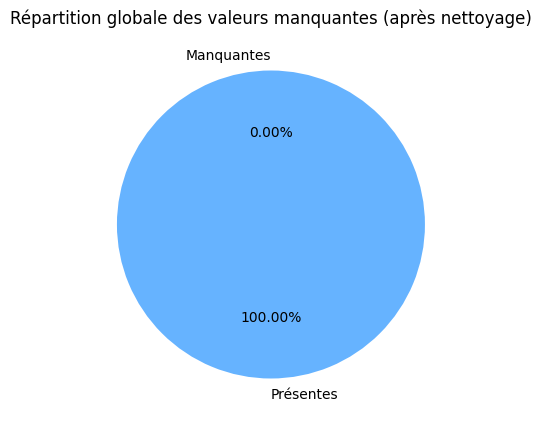

In [7]:
# Vérification des valeurs manquantes après suppression
total_cells_after = Employee_clean.shape[0] * Employee_clean.shape[1]
total_missing_after = Employee_clean.isna().sum().sum()
total_filled_after = total_cells_after - total_missing_after

print("\n Vérification après suppression :")
print("Total de cellules :", total_cells_after)
print("Valeurs manquantes restantes :", total_missing_after)
print(f"Soit {(total_missing_after / total_cells_after) * 100:.2f}% du total.\n")

# Visualisation du résultat final
plt.figure(figsize=(5,5))
plt.pie(
    [total_missing_after, total_filled_after],
    labels=["Manquantes", "Présentes"],
    colors=["#ff6666", "#66b3ff"],
    autopct="%.2f%%",
    startangle=90
)
plt.title("Répartition globale des valeurs manquantes (après nettoyage)")
plt.show()


##  Détection des Doublons

Analyse des lignes dupliquées basée sur le numéro d'employé (`EmployeeNumber`) :
- Comptage du nombre de doublons
- Calcul du pourcentage de doublons

In [8]:
total_duplicates = Employee_clean['EmployeeNumber'].duplicated().sum()
total_rows = len(Employee_clean)
duplicate_percent = (total_duplicates / total_rows) * 100

print("\n Analyse des doublons après suppression des valeurs manquantes :\n")
print(f"Nombre total de lignes : {total_rows}")
print(f"Nombre de doublons (selon EmployeeNumber) : {total_duplicates}")
print(f"Pourcentage de doublons : {duplicate_percent:.2f}%\n")


 Analyse des doublons après suppression des valeurs manquantes :

Nombre total de lignes : 1470
Nombre de doublons (selon EmployeeNumber) : 15
Pourcentage de doublons : 1.02%



##  Visualisation des Doublons

Graphique circulaire montrant la répartition entre lignes dupliquées et lignes uniques.

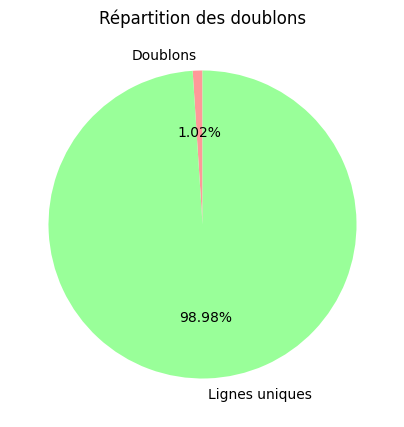

In [9]:
plt.figure(figsize=(5,5))
plt.pie(
    [total_duplicates, total_rows - total_duplicates],
    labels=["Doublons", "Lignes uniques"],
    colors=["#ff9999", "#99ff99"],
    autopct="%.2f%%",
    startangle=90
)
plt.title("Répartition des doublons")
plt.show()

##  Suppression des Doublons

Élimination des lignes dupliquées en gardant uniquement la première occurrence de chaque employé.

In [10]:
Employee_clean = Employee_clean.drop_duplicates(subset=['EmployeeNumber'])
print(" Après suppression des doublons :", Employee_clean.shape)
print("Lignes supprimées :", total_duplicates)


 Après suppression des doublons : (1455, 35)
Lignes supprimées : 15


##  Vérification Après Suppression des Doublons

Confirmation qu'il ne reste plus de doublons dans le dataset avec visualisation finale.


 Vérification après suppression des doublons :

Nombre total de lignes : 1455
Nombre de doublons restants : 0
Pourcentage de doublons : 0.00%



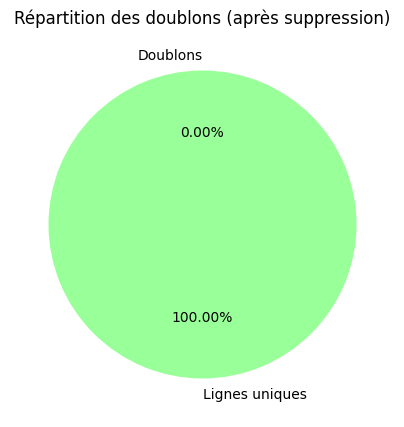

In [11]:
total_duplicates_after = Employee_clean['EmployeeNumber'].duplicated().sum()
total_rows_after = len(Employee_clean)
duplicate_percent_after = (total_duplicates_after / total_rows_after) * 100

print("\n Vérification après suppression des doublons :\n")
print(f"Nombre total de lignes : {total_rows_after}")
print(f"Nombre de doublons restants : {total_duplicates_after}")
print(f"Pourcentage de doublons : {duplicate_percent_after:.2f}%\n")

# Visualisation APRÈS suppression
plt.figure(figsize=(5,5))
plt.pie(
    [total_duplicates_after, total_rows_after - total_duplicates_after],
    labels=["Doublons", "Lignes uniques"],
    colors=["#ff9999", "#99ff99"],
    autopct="%.2f%%",
    startangle=90
)
plt.title("Répartition des doublons (après suppression)")
plt.show()

## Identification des Colonnes Numériques

Sélection automatique de toutes les colonnes numériques (int64, float64) pour l'analyse des valeurs aberrantes.

In [12]:
numeric_cols = Employee_clean.select_dtypes(include=['int64', 'float64']).columns
print("\n Colonnes numériques analysées pour les valeurs aberrantes :")
print(list(numeric_cols))


 Colonnes numériques analysées pour les valeurs aberrantes :
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


##  Calcul des Outliers (Méthode IQR)

Détection des valeurs aberrantes pour chaque colonne numérique en utilisant la méthode IQR (Interquartile Range) :
- Calcul des quartiles Q1 et Q3
- Définition des bornes inférieure et supérieure
- Comptage des outliers par variable

In [13]:
outlier_summary = []

for col in numeric_cols:
    Q1 = Employee_clean[col].quantile(0.25)
    Q3 = Employee_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    nb_outliers = ((Employee_clean[col] < lower) | (Employee_clean[col] > upper)).sum()
    pct_outliers = (nb_outliers / len(Employee_clean)) * 100

    outlier_summary.append({
        'Colonne': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Borne_inférieure': round(lower, 2),
        'Borne_supérieure': round(upper, 2),
        'Nb_outliers': nb_outliers,
        'Pct_outliers (%)': round(pct_outliers, 2)
    })

## Tableau Récapitulatif des Outliers

Affichage d'un tableau résumant tous les outliers détectés, trié par pourcentage décroissant.

In [14]:
outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Pct_outliers (%)', ascending=False)
print("\n Résumé des outliers détectés (méthode IQR) :\n")
print(outlier_df)



 Résumé des outliers détectés (méthode IQR) :

                     Colonne      Q1       Q3      IQR  Borne_inférieure  \
20     TrainingTimesLastYear     2.0      3.0      1.0              0.50   
15         PerformanceRating     3.0      3.0      0.0              3.00   
11             MonthlyIncome  2911.0   8380.5   5469.5          -5293.25   
24   YearsSinceLastPromotion     0.0      3.0      3.0             -4.50   
22            YearsAtCompany     3.0      9.0      6.0             -6.00   
18          StockOptionLevel     0.0      1.0      1.0             -1.50   
19         TotalWorkingYears     6.0     15.0      9.0             -7.50   
13        NumCompaniesWorked     1.0      4.0      3.0             -3.50   
23        YearsInCurrentRole     2.0      7.0      5.0             -5.50   
25      YearsWithCurrManager     2.0      7.0      5.0             -5.50   
9                   JobLevel     1.0      3.0      2.0             -2.00   
8             JobInvolvement     2.0    

##  Boxplot Global des Variables Numériques

Visualisation globale des distributions avec boxplots pour toutes les colonnes numériques simultanément.

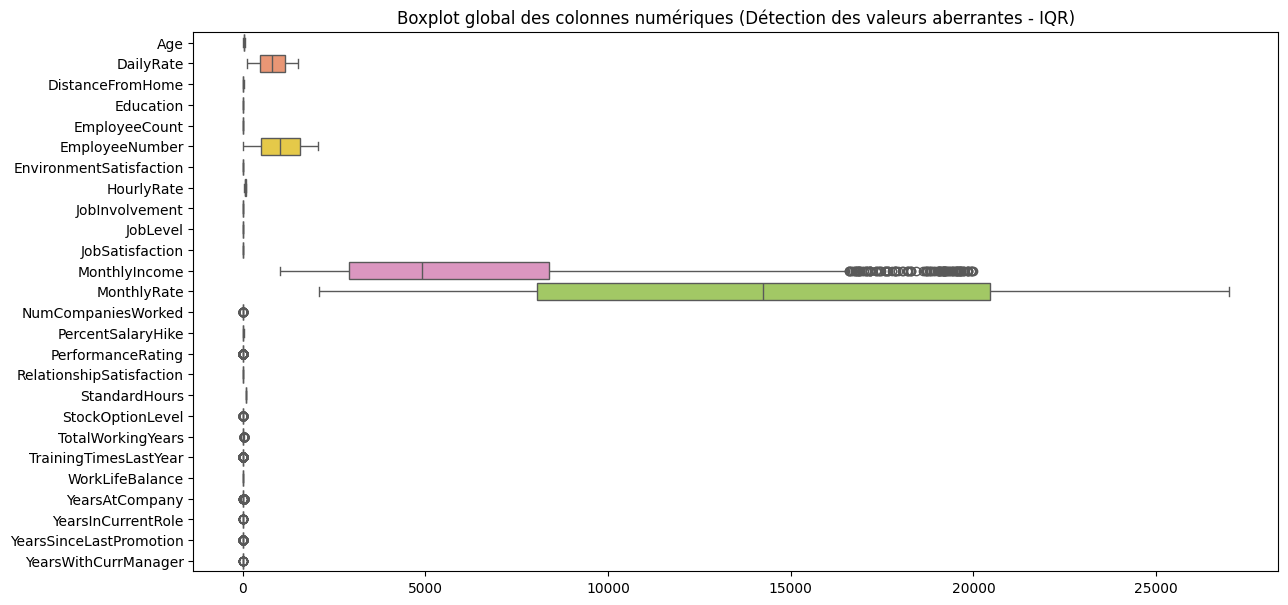

In [15]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=Employee_clean[numeric_cols], orient="h", palette="Set2")
plt.title("Boxplot global des colonnes numériques (Détection des valeurs aberrantes - IQR)")
plt.show()

## Boxplots Individuels par Variable

Création de boxplots séparés pour chaque variable numérique, permettant une analyse détaillée des outliers.

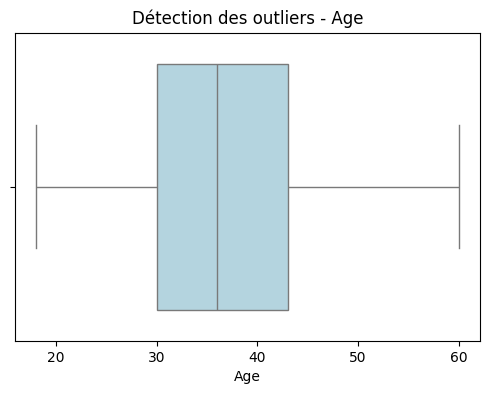

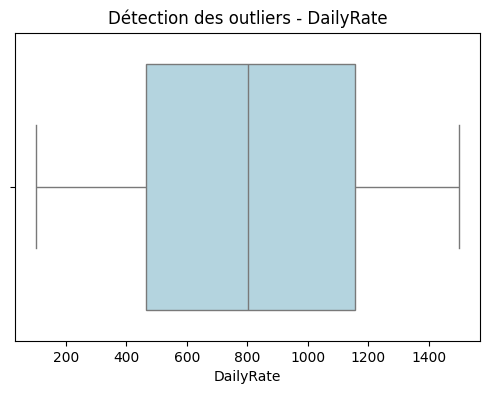

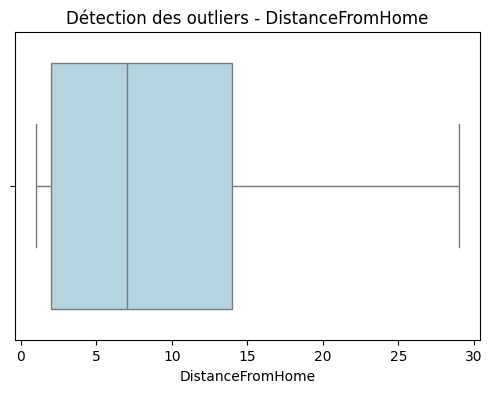

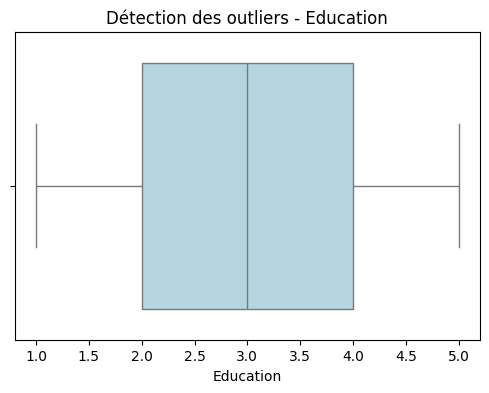

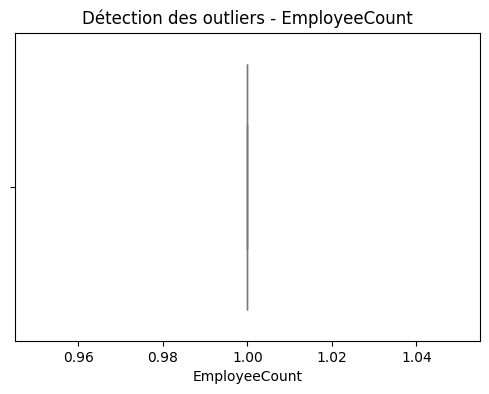

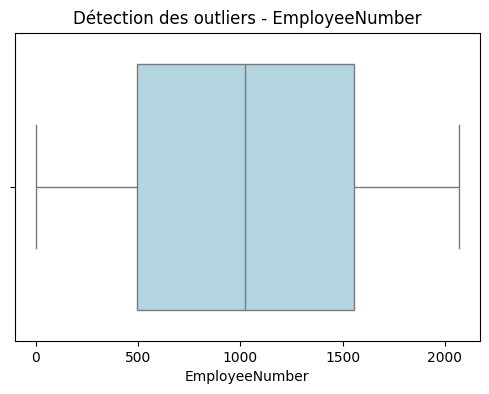

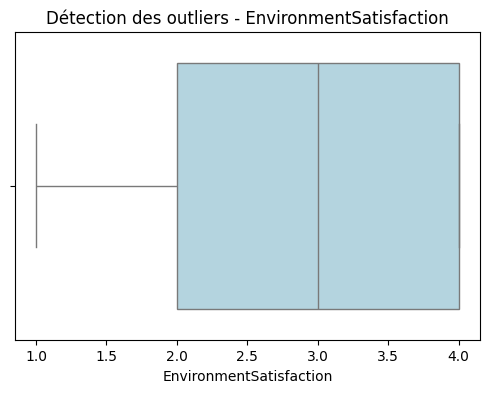

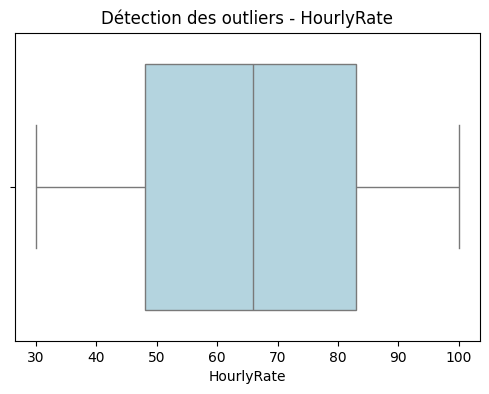

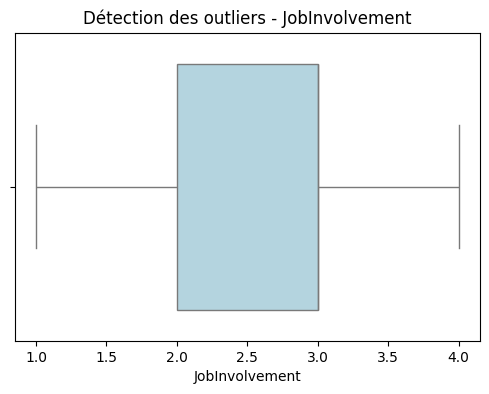

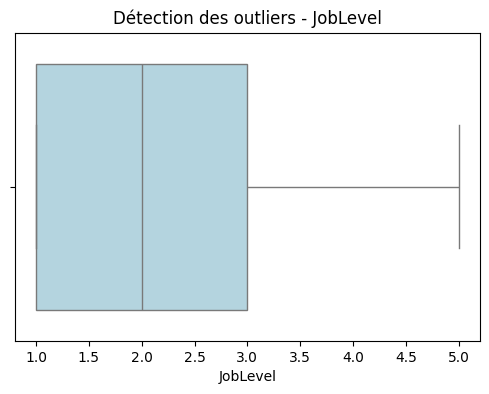

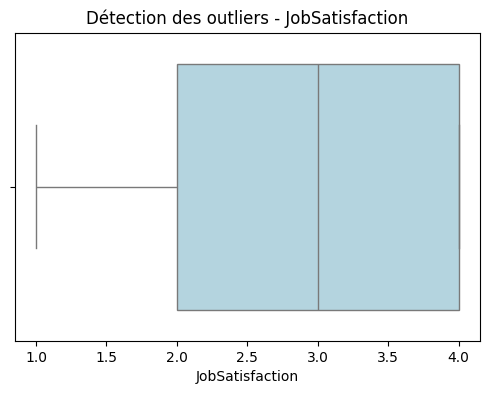

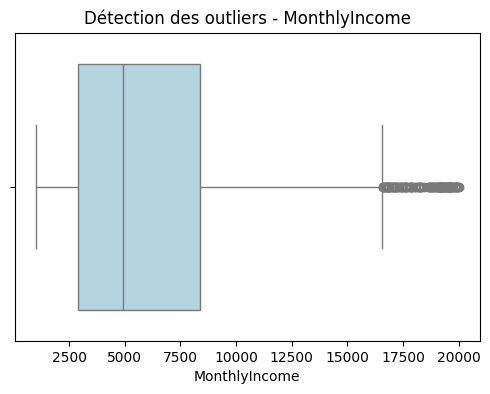

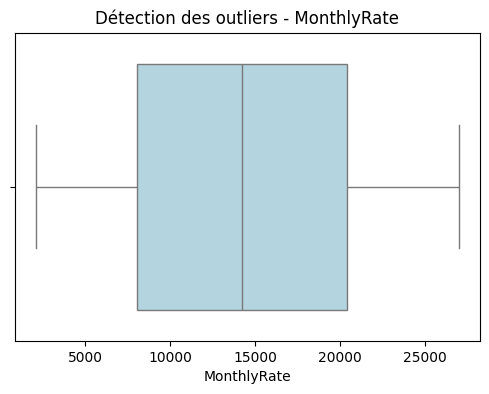

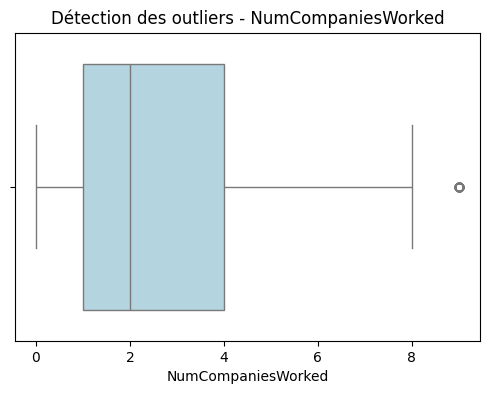

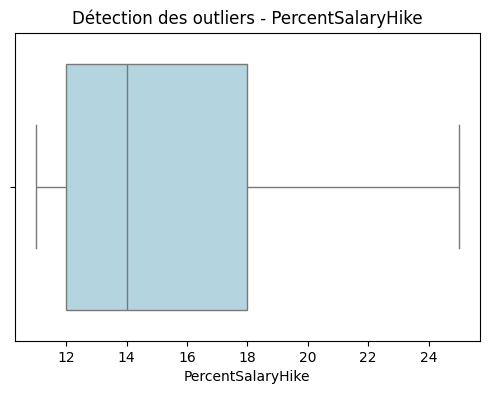

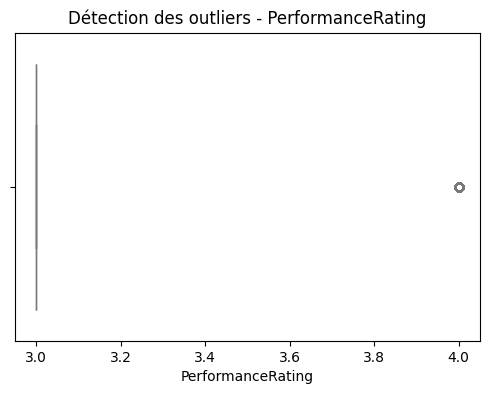

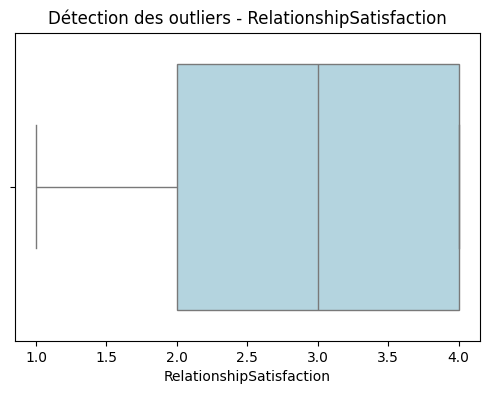

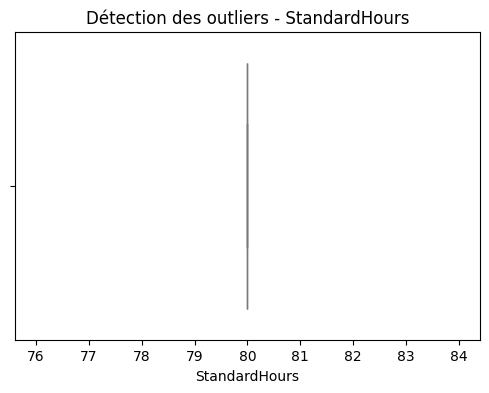

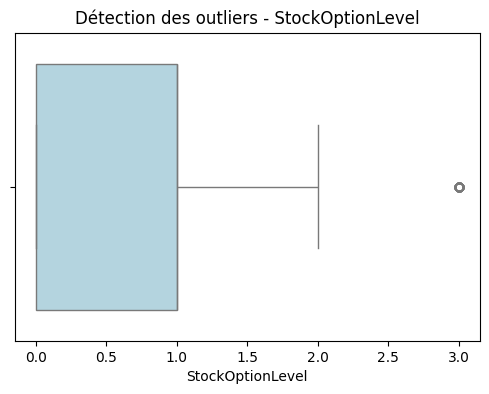

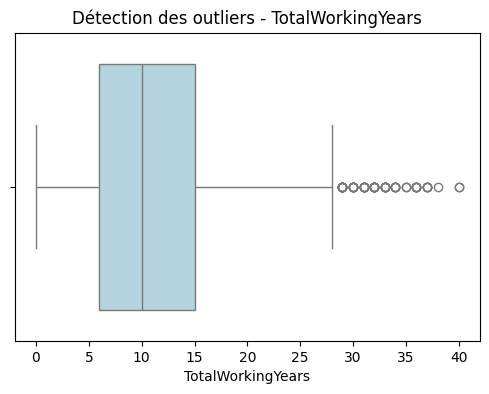

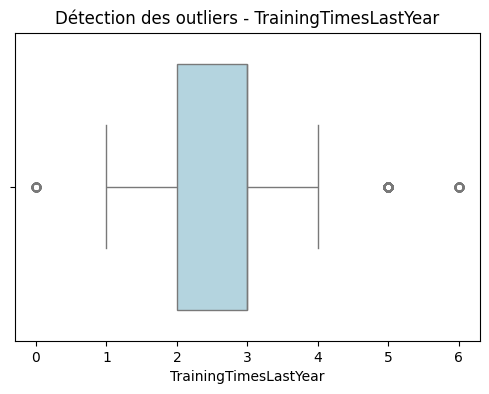

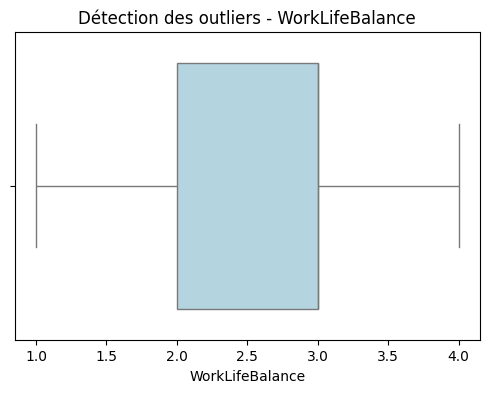

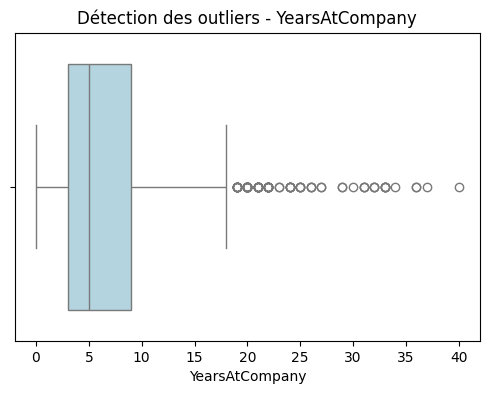

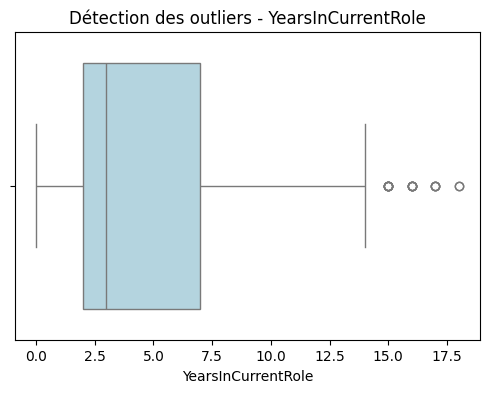

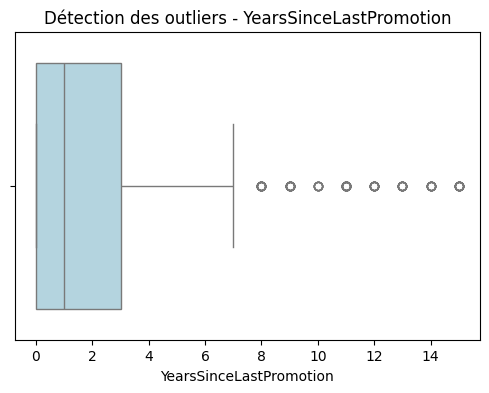

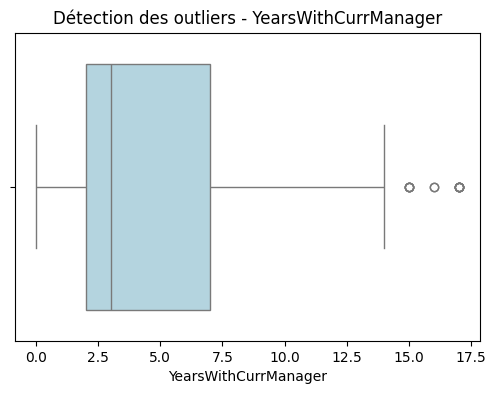

In [16]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=Employee_clean[col], color="lightblue")
    plt.title(f"Détection des outliers - {col}")
    plt.xlabel(col)
    plt.show()

##  Traitement des Outliers et Transformations

**Étape 1 : Winsorization** - Limitation des valeurs extrêmes aux quantiles définis (cap au lieu de supprimer)

**Étape 2 : Transformations Mathématiques**
- Transformation logarithmique (log) pour réduire l'asymétrie
- Transformation racine carrée (sqrt) pour normaliser les distributions

**Étape 3 : Visualisation** - Boxplots après transformations pour vérifier l'amélioration

 TotalWorkingYears: cap de [0.00, 40.00] → [1.00, 34.46]
 YearsAtCompany: cap de [0.00, 40.00] → [0.00, 31.00]
 YearsSinceLastPromotion: cap de [0.00, 15.00] → [0.00, 13.00]
 TrainingTimesLastYear: cap de [0.00, 6.00] → [0.00, 6.00]
 MonthlyIncome: cap de [1009.00, 19999.00] → [1377.36, 19626.46]
Taille du dataset (aucune ligne supprimée) : (1455, 35)
 Transformations appliquées (log & sqrt)


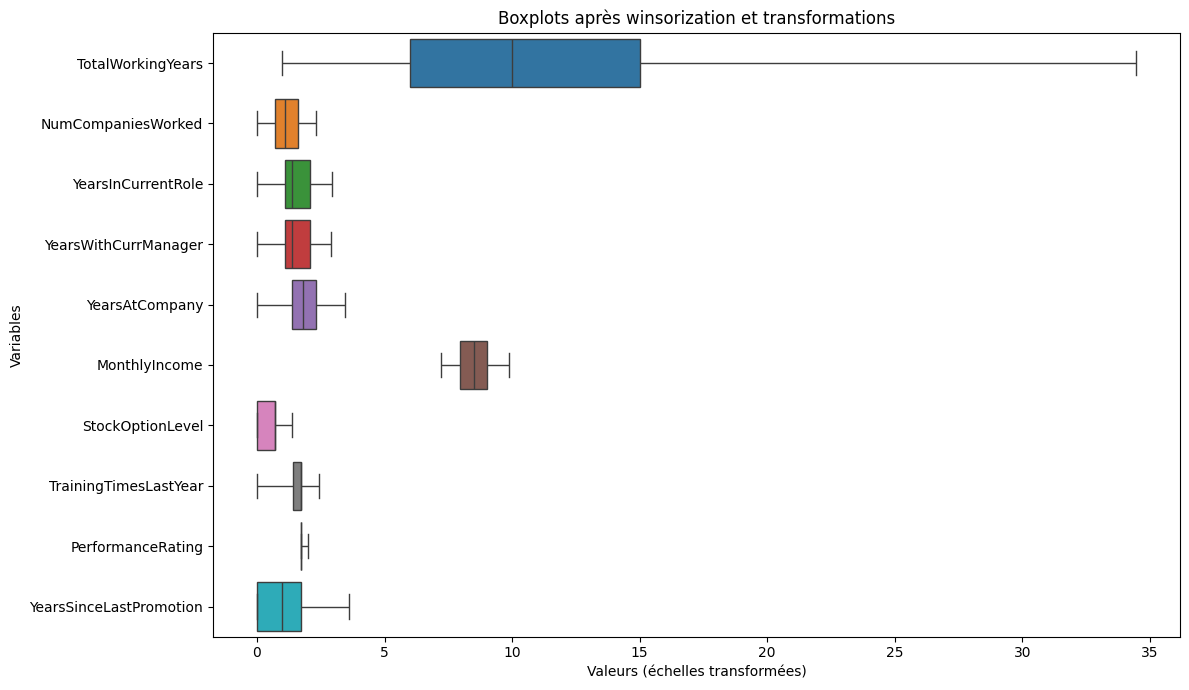

In [17]:

# ===== 1) Winsorization (cap aux quantiles) =====
def winsorize_col(df, col, q_low=0.01, q_high=0.99):
    low = df[col].quantile(q_low)
    high = df[col].quantile(q_high)
    df[col] = np.clip(df[col], low, high)
    return df

# Colonnes les plus problématiques
cols_to_cap = {
    "TotalWorkingYears": (0.01, 0.99),
    "YearsAtCompany": (0.01, 0.99),
    "YearsSinceLastPromotion": (0.02, 0.98),
    "TrainingTimesLastYear": (0.02, 0.98),
    "MonthlyIncome": (0.01, 0.99)
}

for col, (ql, qh) in cols_to_cap.items():
    before_min, before_max = Employee_clean[col].min(), Employee_clean[col].max()
    Employee_clean = winsorize_col(Employee_clean, col, q_low=ql, q_high=qh)
    after_min, after_max = Employee_clean[col].min(), Employee_clean[col].max()
    print(f" {col}: cap de [{before_min:.2f}, {before_max:.2f}] → [{after_min:.2f}, {after_max:.2f}]")

print("Taille du dataset (aucune ligne supprimée) :", Employee_clean.shape)

# ===== 2) Transformations (log / sqrt) =====
cols_to_log = [
    "NumCompaniesWorked","YearsInCurrentRole",
    "YearsWithCurrManager","YearsAtCompany",
    "MonthlyIncome","StockOptionLevel"
]
for col in cols_to_log:
    Employee_clean[col + "_log"] = np.log1p(Employee_clean[col])

cols_to_sqrt = ["TrainingTimesLastYear", "PerformanceRating", "YearsSinceLastPromotion"]
for col in cols_to_sqrt:
    Employee_clean[col + "_sqrt"] = np.sqrt(Employee_clean[col])

print(" Transformations appliquées (log & sqrt)")

# ===== 3) Préparation de l’affichage =====
cols_for_plot = (
    ["TotalWorkingYears"] +                          # version capée
    [c + "_log" for c in cols_to_log] +             # versions log
    [c + "_sqrt" for c in cols_to_sqrt]             # versions sqrt
)

pretty_names = [
    "TotalWorkingYears",
    "NumCompaniesWorked","YearsInCurrentRole",
    "YearsWithCurrManager","YearsAtCompany","MonthlyIncome","StockOptionLevel",
    "TrainingTimesLastYear","PerformanceRating","YearsSinceLastPromotion"
]

df_plot = Employee_clean[cols_for_plot].copy()
df_plot.columns = pretty_names

# ===== 4) Boxplots (sans points aberrants dessinés) =====
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_plot, orient="h", showfliers=False, whis=(0, 100))
plt.title("Boxplots après winsorization et transformations")
plt.xlabel("Valeurs (échelles transformées)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


##  Visualisation des Variables Catégorielles

Création de graphiques de comptage (countplots) pour visualiser la distribution de chaque variable catégorielle avant encodage.

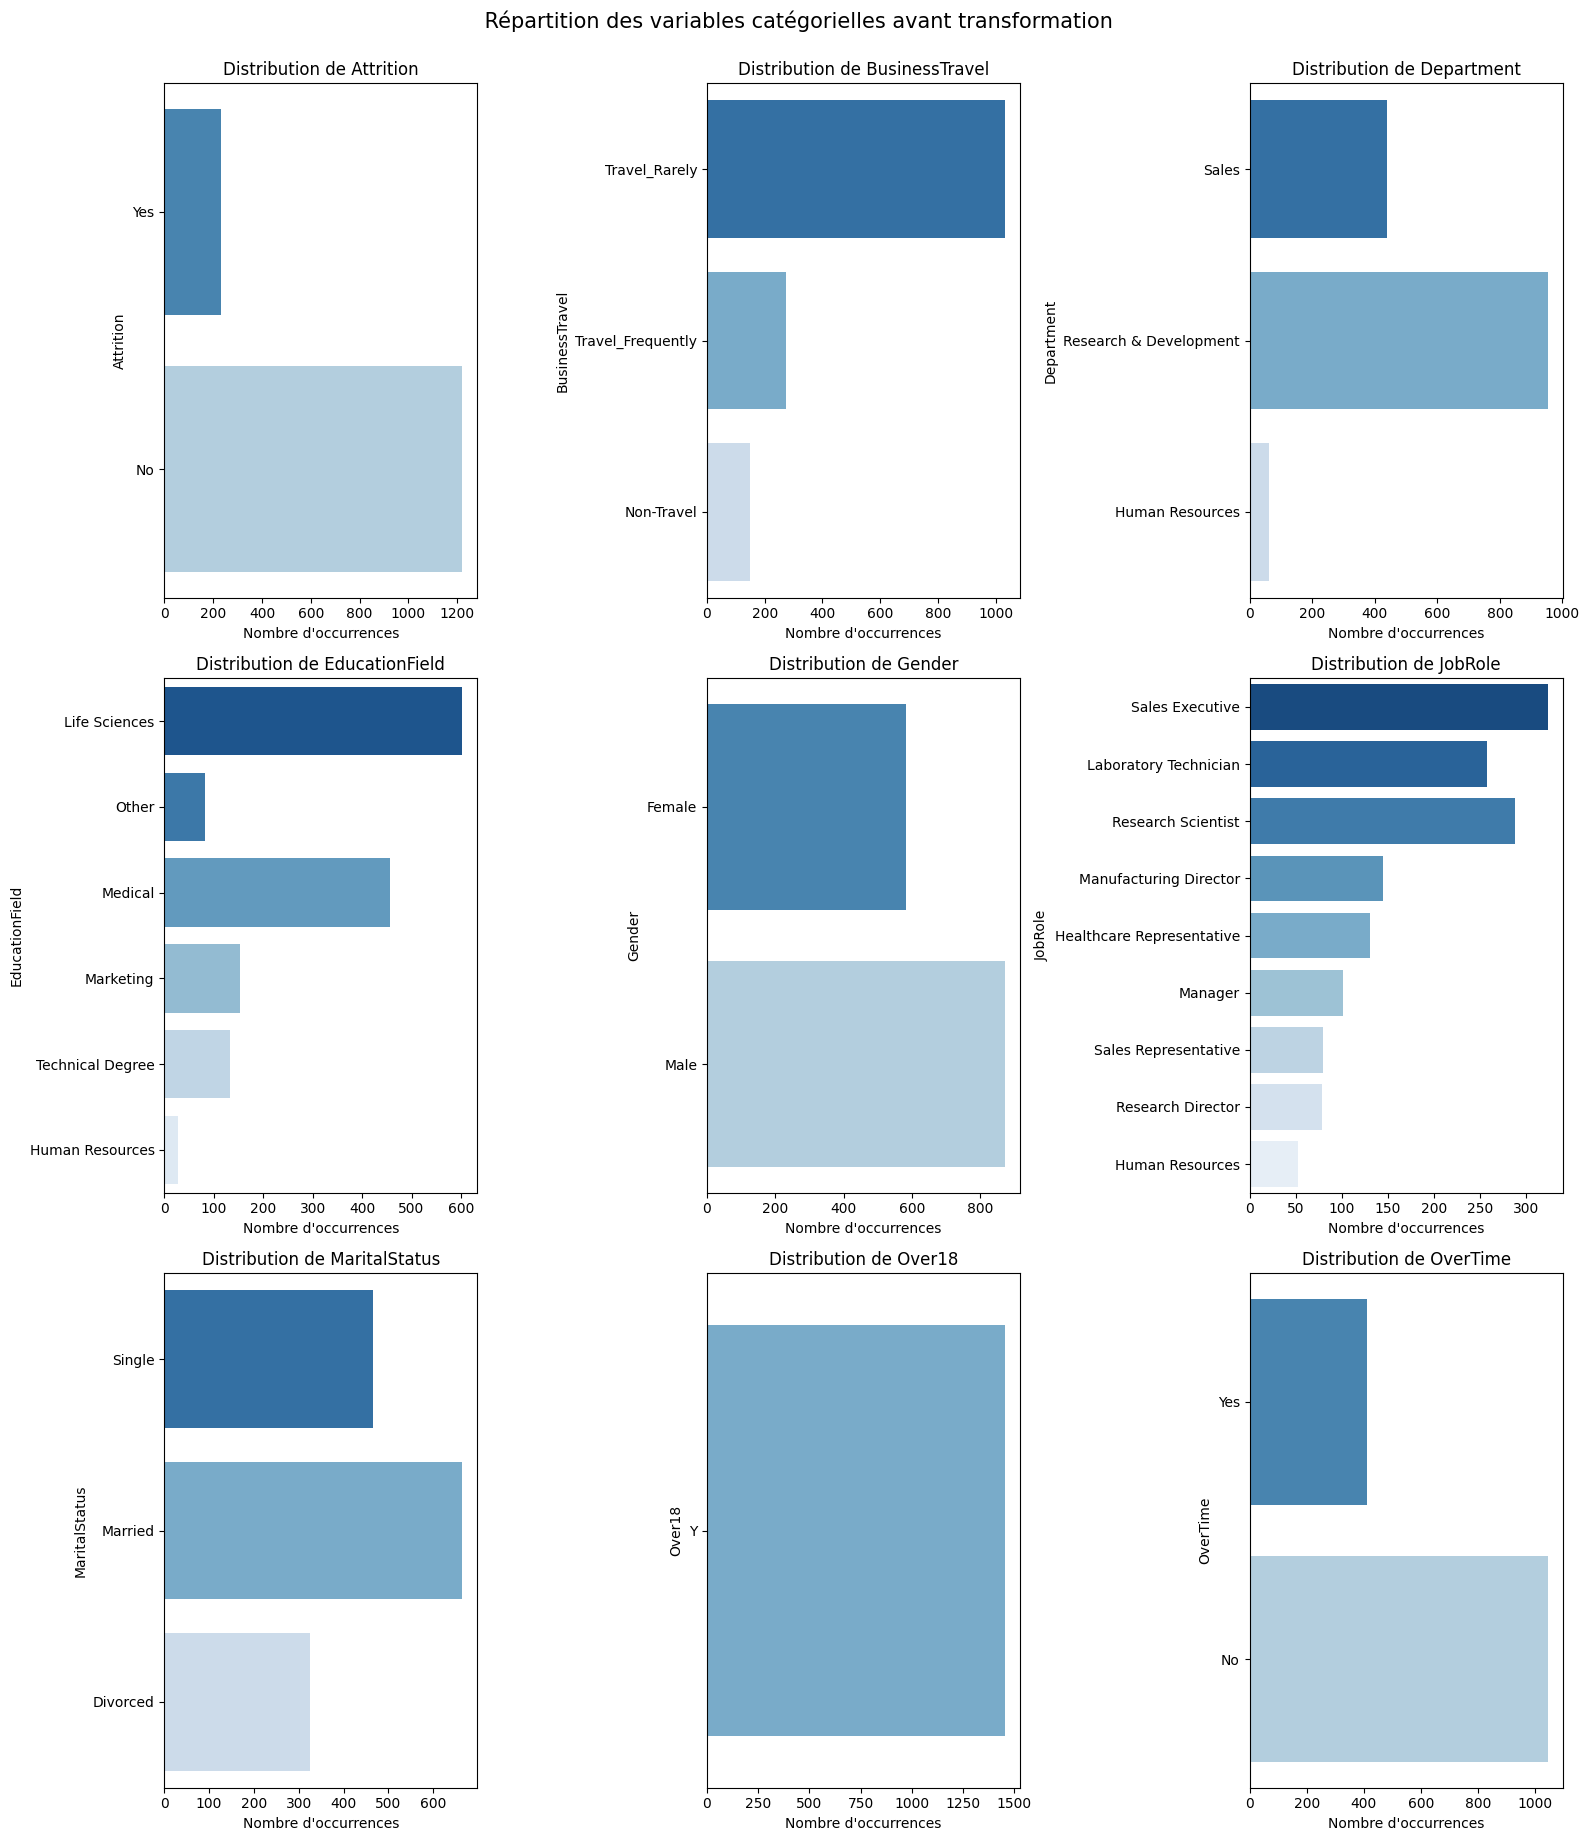

In [18]:
# Variables catégorielles à visualiser
cat_cols = [
    "Attrition", "BusinessTravel", "Department", "EducationField",
    "Gender", "JobRole", "MaritalStatus", "Over18", "OverTime"
]

# Taille de la figure : une grille de sous-graphes
plt.figure(figsize=(16, 18))

# Boucle sur chaque variable pour tracer un graphique
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)  # 3 lignes, 3 colonnes
    sns.countplot(data=Employee_clean, y=col, palette="Blues_r")
    plt.title(f"Distribution de {col}", fontsize=12)
    plt.xlabel("Nombre d'occurrences")
    plt.ylabel(col)
    plt.tight_layout()

plt.suptitle(" Répartition des variables catégorielles avant transformation", fontsize=15, y=1.02)
plt.show()

##  Label Encoding des Variables Binaires

Encodage des variables catégorielles binaires (2 valeurs possibles) en valeurs numériques (0, 1) :
- Attrition, OverTime, Gender, Over18, BusinessTravel, MaritalStatus

In [19]:
# ============================
#  Variables binaires → Label Encoding
# ============================
binary_cols = ["Attrition", "OverTime", "Gender", "Over18","BusinessTravel","MaritalStatus"]

le = LabelEncoder()
for col in binary_cols:
    Employee_clean[col] = le.fit_transform(Employee_clean[col])

print(" Label Encoding appliqué sur :", binary_cols)

 Label Encoding appliqué sur : ['Attrition', 'OverTime', 'Gender', 'Over18', 'BusinessTravel', 'MaritalStatus']


##  Visualisation Après Label Encoding

Affichage des distributions des variables binaires après leur transformation en valeurs numériques.

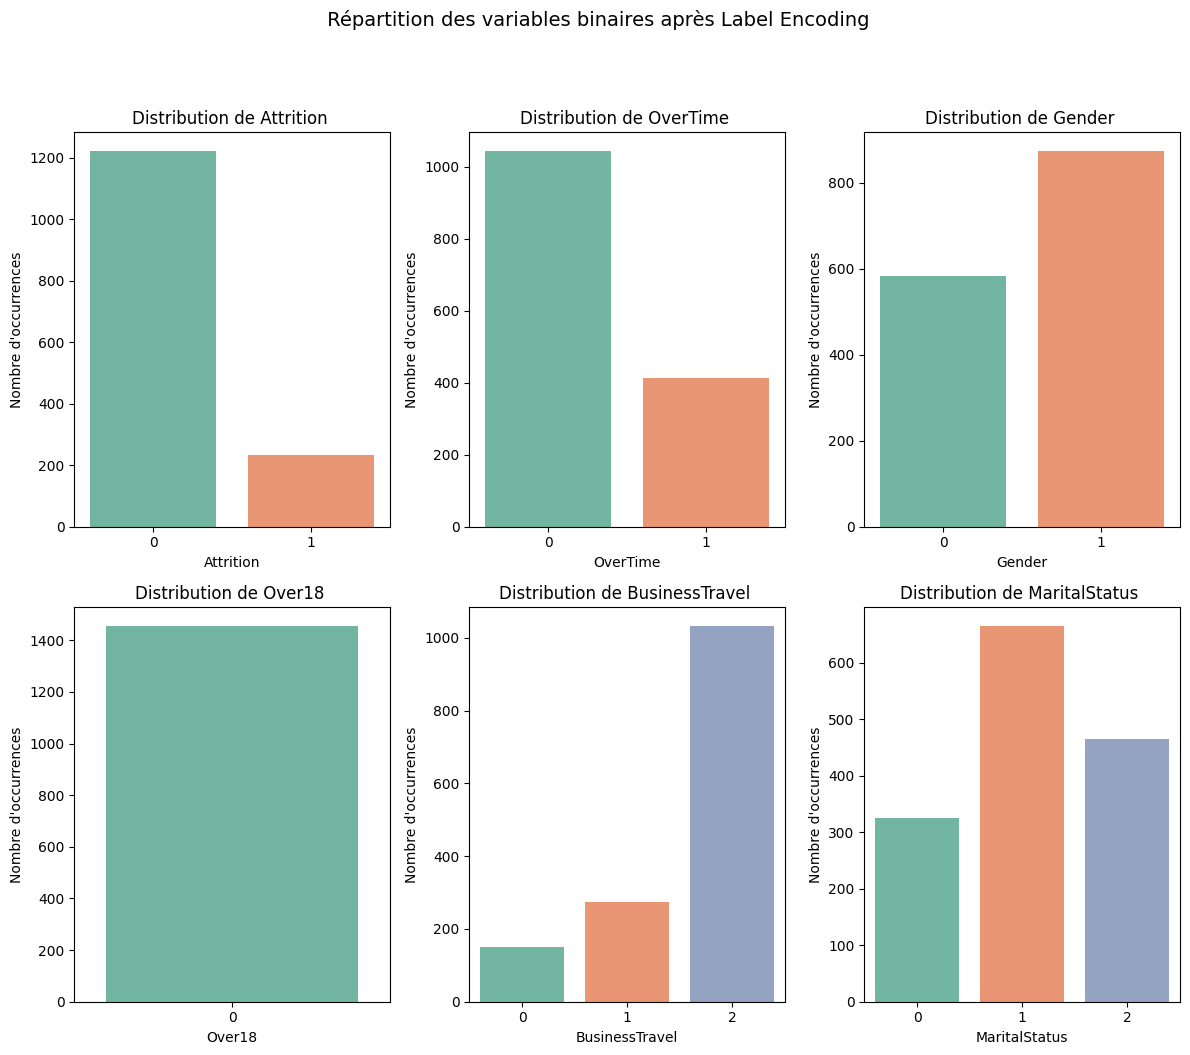

In [20]:
plt.figure(figsize=(12, 10)) # Adjusted figure size for 6 subplots
for i, col in enumerate(binary_cols, 1):
    plt.subplot(2, 3, i)  # Changed subplot grid to 2 rows and 3 columns
    sns.countplot(x=Employee_clean[col], palette="Set2")
    plt.title(f"Distribution de {col} ")
    plt.xlabel(col)
    plt.ylabel("Nombre d'occurrences")

plt.suptitle(" Répartition des variables binaires après Label Encoding", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

##  One-Hot Encoding des Variables Nominales

Encodage des variables catégorielles avec plus de 2 modalités (Department, EducationField, JobRole) :
- Création de colonnes binaires (dummy variables) pour chaque catégorie
- Augmentation du nombre de colonnes dans le dataset

In [21]:
# ============================
#  Variables nominales → One-Hot Encoding
# ============================
nominal_cols = ["Department", "EducationField", "JobRole"]

Employee_encoded = pd.get_dummies(Employee_clean, columns=nominal_cols, drop_first=False , dtype=int  )

print(" One-Hot Encoding appliqué sur :", nominal_cols)
print(" Nouvelle taille du dataset :", Employee_encoded.shape)

 One-Hot Encoding appliqué sur : ['Department', 'EducationField', 'JobRole']
 Nouvelle taille du dataset : (1455, 59)


## Détail des Colonnes Créées par One-Hot Encoding

Affichage du nombre et des noms de toutes les nouvelles colonnes créées par le One-Hot Encoding avec visualisation graphique.


 Department → 3 colonnes créées :
   • Department_Human Resources
   • Department_Research & Development
   • Department_Sales

 EducationField → 6 colonnes créées :
   • EducationField_Human Resources
   • EducationField_Life Sciences
   • EducationField_Marketing
   • EducationField_Medical
   • EducationField_Other
   • EducationField_Technical Degree

 JobRole → 9 colonnes créées :
   • JobRole_Healthcare Representative
   • JobRole_Human Resources
   • JobRole_Laboratory Technician
   • JobRole_Manager
   • JobRole_Manufacturing Director
   • JobRole_Research Director
   • JobRole_Research Scientist
   • JobRole_Sales Executive
   • JobRole_Sales Representative


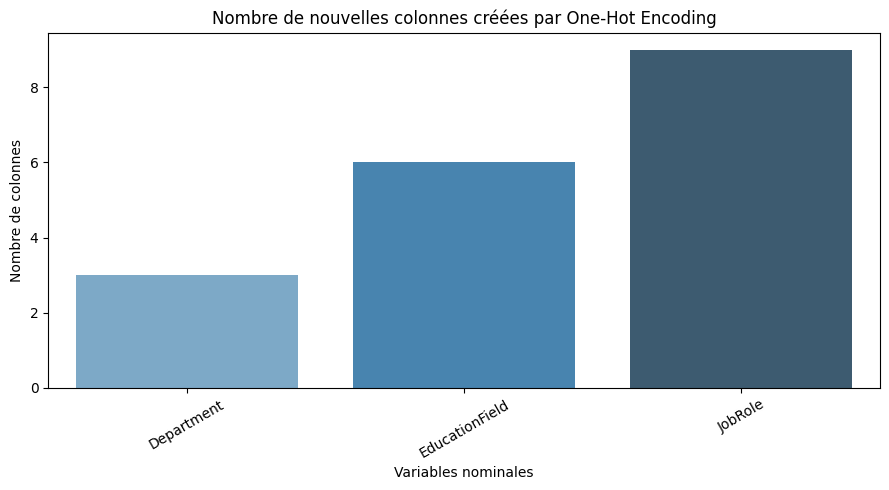

In [22]:
# 1️ Compter et afficher les colonnes créées par One-Hot Encoding
onehot_details = {}

for col in nominal_cols:
    created_cols = [c for c in Employee_encoded.columns if c.startswith(col + "_")]
    onehot_details[col] = created_cols
    print(f"\n {col} → {len(created_cols)} colonnes créées :")
    for new_col in created_cols:
        print("   •", new_col)

# Visualisation du nombre de colonnes créées
plt.figure(figsize=(9,5))
sns.barplot(x=list(onehot_details.keys()),
            y=[len(v) for v in onehot_details.values()],
            palette="Blues_d")
plt.title("Nombre de nouvelles colonnes créées par One-Hot Encoding")
plt.ylabel("Nombre de colonnes")
plt.xlabel("Variables nominales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


##  Construction du Dataset Final Après Nettoyage

Consolidation de toutes les transformations :
- Suppression des colonnes originales qui ont été transformées (log, sqrt)
- Conservation uniquement des versions transformées
- Sauvegarde du dataset propre dans un fichier CSV

In [23]:
# =============================
#  Construire le dataset final après nettoyage + encodage
# =============================

# 1) Définir les listes de colonnes sources transformées
cols_to_log = ["NumCompaniesWorked", "YearsInCurrentRole", "YearsWithCurrManager",
               "YearsAtCompany", "MonthlyIncome", "StockOptionLevel"]

sqrt_sources  = ["TrainingTimesLastYear", "PerformanceRating", "YearsSinceLastPromotion"]

log_targets   = [c + "_log" for c in cols_to_log]
sqrt_targets  = [c + "_sqrt" for c in sqrt_sources]

transformed_sources = cols_to_log + sqrt_sources
transformed_targets = log_targets + sqrt_targets

# 2) Partir du dataset encodé (il contient déjà les dummies et les binaires encodées)
df = Employee_encoded.copy()

# 3) Retirer les colonnes originales qui ont une version transformée
cols_to_drop = [c for c in transformed_sources if c in df.columns]
df_final = df.drop(columns=cols_to_drop, errors="ignore")

# 4) (Sécurité) s’assurer que les colonnes transformées sont bien présentes
missing_targets = [c for c in transformed_targets if c not in df_final.columns]
if missing_targets:
    print(" Colonnes transformées manquantes (à vérifier) :", missing_targets)

# 5) Afficher résultat
print(" Dataset final construit.")
print("Taille finale :", df_final.shape)

# un petit aperçu
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
display(df_final.head())

# 6) Sauvegarder
df_final.to_csv("HR_final_after_clean_encode_transform.csv", index=False)
print("Sauvegardé sous : HR_final_after_clean_encode_transform.csv")


 Dataset final construit.
Taille finale : (1455, 50)


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MaritalStatus,MonthlyRate,Over18,OverTime,PercentSalaryHike,RelationshipSatisfaction,StandardHours,TotalWorkingYears,WorkLifeBalance,NumCompaniesWorked_log,YearsInCurrentRole_log,YearsWithCurrManager_log,YearsAtCompany_log,MonthlyIncome_log,StockOptionLevel_log,TrainingTimesLastYear_sqrt,PerformanceRating_sqrt,YearsSinceLastPromotion_sqrt,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative
0,41.0,1,2,1102.0,1.0,2.0,1.0,1.0,2.0,0,94.0,3.0,2.0,4.0,2,19479.0,0,1,11.0,1.0,80.0,8.0,1.0,2.197225,1.609438,1.791759,1.945910,8.698514,0.000000,0.000000,1.732051,0.000000,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
2,37.0,1,2,1373.0,2.0,2.0,1.0,4.0,4.0,1,92.0,2.0,1.0,3.0,2,2396.0,0,1,15.0,2.0,80.0,7.0,3.0,1.945910,0.000000,0.000000,0.000000,7.645398,0.000000,1.732051,1.732051,0.000000,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
3,33.0,0,1,1392.0,3.0,4.0,1.0,5.0,4.0,0,56.0,3.0,1.0,3.0,1,23159.0,0,1,11.0,3.0,80.0,8.0,3.0,0.693147,2.079442,0.000000,2.197225,7.975908,0.000000,1.732051,1.732051,1.732051,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
4,27.0,0,2,591.0,2.0,1.0,1.0,7.0,1.0,1,40.0,3.0,1.0,2.0,1,16632.0,0,0,12.0,4.0,80.0,6.0,3.0,2.302585,1.098612,1.098612,1.098612,8.151622,0.693147,1.732051,1.732051,1.414214,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
5,32.0,0,1,1005.0,2.0,2.0,1.0,8.0,4.0,1,79.0,3.0,1.0,4.0,2,11864.0,0,0,13.0,3.0,80.0,8.0,2.0,0.000000,2.079442,1.945910,2.079442,8.029107,0.000000,1.414214,1.732051,1.732051,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0


Sauvegardé sous : HR_final_after_clean_encode_transform.csv


##  Rechargement du Dataset Propre

Chargement du fichier CSV nettoyé pour commencer l'étape de sélection des features.

In [24]:
# Charger le dataset propre
df = pd.read_csv("HR_final_after_clean_encode_transform.csv")

print(" Taille du dataset :", df.shape)
print(" Nombre de colonnes :", len(df.columns))

 Taille du dataset : (1455, 50)
 Nombre de colonnes : 50


##  Feature Selection avec Random Forest

Sélection des variables les plus importantes pour prédire l'attrition :

**Étapes :**
1. Séparation features (X) et cible (y)
2. Calcul des corrélations avec la variable cible
3. Visualisation de la matrice de corrélation
4. Calcul de l'importance avec Random Forest
5. Sélection des features dépassant un seuil d'importance (0.01)

Features (X) shape: (1455, 49)
Target (y) shape: (1455,)

Distribution de la variable cible (Attrition):
Attrition
0    1221
1     234
Name: count, dtype: int64

 Top 15 des features les plus corrélées avec Attrition:
Attrition                          1.000000
OverTime                           0.248069
MaritalStatus                      0.157454
JobRole_Sales Representative       0.157039
JobRole_Laboratory Technician      0.096486
Department_Sales                   0.083139
DistanceFromHome                   0.075730
EducationField_Technical Degree    0.070160
EducationField_Marketing           0.056149
NumCompaniesWorked_log             0.041762
EducationField_Human Resources     0.036844
JobRole_Human Resources            0.036654
Gender                             0.029023
JobRole_Sales Executive            0.022750
Department_Human Resources         0.017171
Name: Attrition, dtype: float64


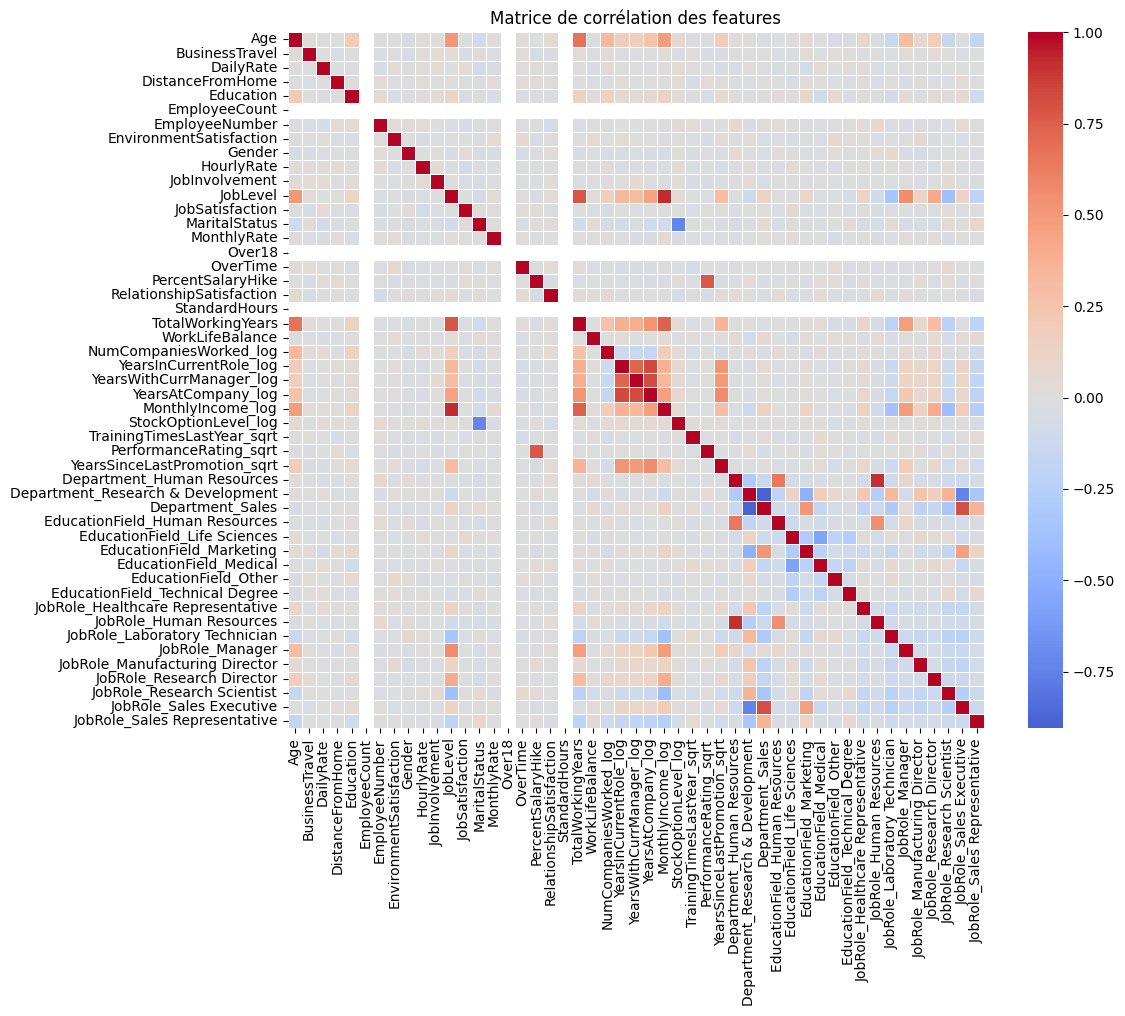


 Calcul de l'importance des features avec Random Forest...

 Top 20 des features les plus importantes (Random Forest):
                         Feature  Importance
26             MonthlyIncome_log    0.068852
0                            Age    0.060627
16                      OverTime    0.051282
2                      DailyRate    0.048642
3               DistanceFromHome    0.047566
20             TotalWorkingYears    0.045540
14                   MonthlyRate    0.045165
6                 EmployeeNumber    0.044883
9                     HourlyRate    0.044242
25            YearsAtCompany_log    0.041697
17             PercentSalaryHike    0.032474
22        NumCompaniesWorked_log    0.032085
24      YearsWithCurrManager_log    0.030663
7        EnvironmentSatisfaction    0.029785
27          StockOptionLevel_log    0.029636
23        YearsInCurrentRole_log    0.026186
21               WorkLifeBalance    0.026177
30  YearsSinceLastPromotion_sqrt    0.025461
18      RelationshipSatis

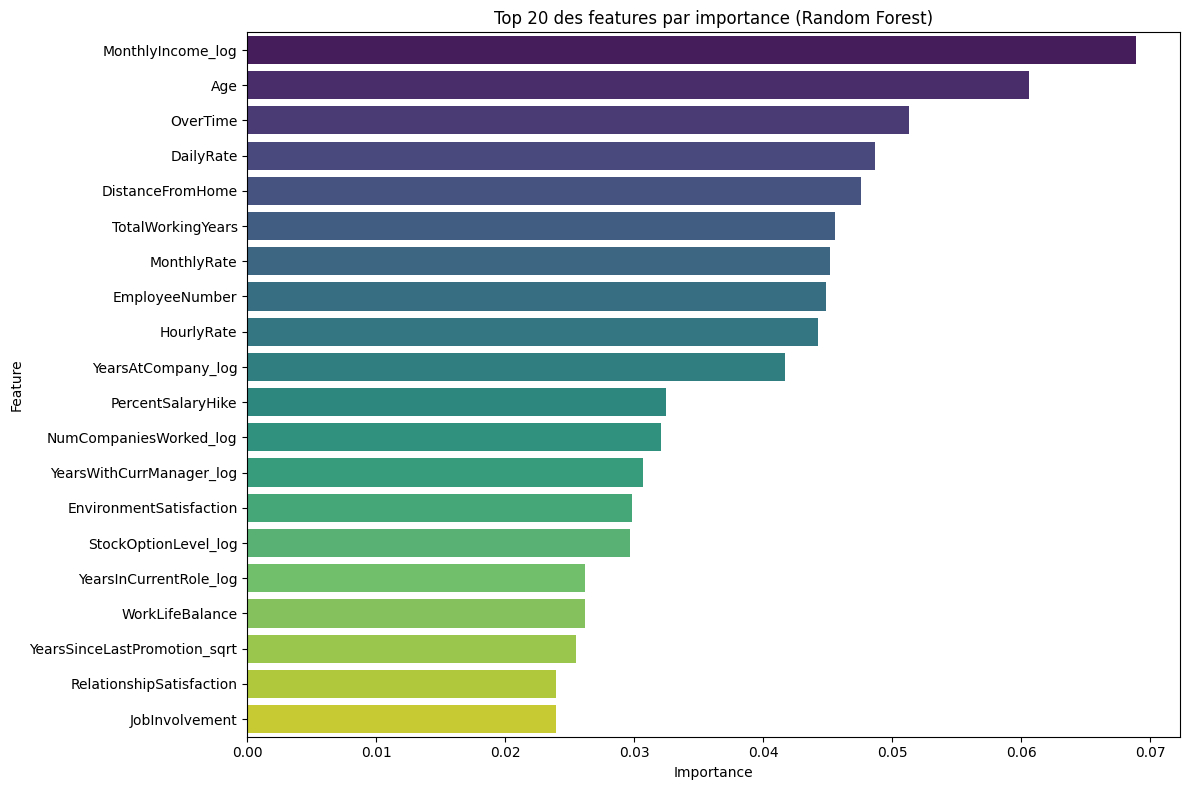


 Nombre de features sélectionnées (importance >= 0.01): 26
Features sélectionnées: ['MonthlyIncome_log', 'Age', 'OverTime', 'DailyRate', 'DistanceFromHome', 'TotalWorkingYears', 'MonthlyRate', 'EmployeeNumber', 'HourlyRate', 'YearsAtCompany_log', 'PercentSalaryHike', 'NumCompaniesWorked_log', 'YearsWithCurrManager_log', 'EnvironmentSatisfaction', 'StockOptionLevel_log', 'YearsInCurrentRole_log', 'WorkLifeBalance', 'YearsSinceLastPromotion_sqrt', 'RelationshipSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'TrainingTimesLastYear_sqrt', 'MaritalStatus', 'JobLevel', 'Education', 'BusinessTravel']

 Dataset final avec features sélectionnées: (1455, 26)


In [25]:
# =============================
#  Feature Selection
# =============================

# 1) Séparer les features (X) et la cible (y)
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nDistribution de la variable cible (Attrition):")
print(y.value_counts())

# 2) Calcul de la matrice de corrélation
corr_matrix = X.corr()

# Corrélation avec la variable cible (si numérique)
# Note: Attrition est déjà encodée en 0/1
X_with_target = df.copy()
target_corr = X_with_target.corr()['Attrition'].sort_values(ascending=False)

print("\n Top 15 des features les plus corrélées avec Attrition:")
print(target_corr.head(15))

# 3) Visualisation de la matrice de corrélation
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title("Matrice de corrélation des features")
plt.tight_layout()
plt.show()

# 4) Feature Importance avec Random Forest
print("\n Calcul de l'importance des features avec Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Créer un DataFrame avec les importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n Top 20 des features les plus importantes (Random Forest):")
print(feature_importance.head(20))

# 5) Visualisation des features importantes
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(20), x='Importance', y='Feature', palette='viridis')
plt.title("Top 20 des features par importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 6) Sélection des features importantes (seuil à ajuster)
importance_threshold = 0.01
selected_features = feature_importance[feature_importance['Importance'] >= importance_threshold]['Feature'].tolist()

print(f"\n Nombre de features sélectionnées (importance >= {importance_threshold}):", len(selected_features))
print("Features sélectionnées:", selected_features)

# 7) Créer le dataset final avec les features sélectionnées
X_selected = X[selected_features]
print("\n Dataset final avec features sélectionnées:", X_selected.shape)

##  Feature Engineering Avancé

Création de nouvelles features métier pour améliorer la prédiction :

**5 Catégories de Features Créées :**
1. **Indicateurs de Risque** : ratio salaire/expérience, surcharge de travail, stagnation
2. **Satisfaction & Engagement** : scores globaux, déséquilibre vie pro/perso
3. **Carrière & Rémunération** : ratio promotion, sous-rémunération
4. **Profils à Risque** : jeunes talents, burnout, nouveaux employés
5. **Interactions** : combinaisons de variables (âge×satisfaction, overtime×distance)

In [26]:
# =============================
#  Feature Engineering pour la Prédiction de l'Attrition
# =============================

print("🔧 Feature Engineering pour prédire le départ des employés...")
print(f"Dataset initial : {X_selected.shape}")

# Créer une copie pour le feature engineering
df_fe = X_selected.copy()

# ===== 1) INDICATEURS DE RISQUE D'ATTRITION =====
print("\n Création des indicateurs de risque de départ...")

# Faible revenu pour l'expérience (signe d'insatisfaction salariale)
df_fe['Low_Income_Experience_Ratio'] = df_fe['MonthlyIncome_log'] / (df_fe['TotalWorkingYears'] + 1)

# Surcharge de travail (OverTime + distance longue)
df_fe['Work_Burden_Score'] = df_fe['OverTime'] * (df_fe['DistanceFromHome'] / 10)

# Stagnation de carrière (longtemps sans promotion)
df_fe['Career_Stagnation'] = df_fe['YearsSinceLastPromotion_sqrt'] * (df_fe['YearsAtCompany_log'] + 1)

# Instabilité professionnelle (beaucoup de changements d'entreprise)
df_fe['Job_Hopper'] = (df_fe['NumCompaniesWorked_log'] > np.log1p(3)).astype(int)

# Manque d'investissement entreprise (peu de formation + faible stock options)
df_fe['Low_Company_Investment'] = ((df_fe['TrainingTimesLastYear_sqrt'] < 1) &
                                     (df_fe['StockOptionLevel_log'] < np.log1p(1))).astype(int)

print(f"    {5} indicateurs de risque créés")

# ===== 2) SCORES DE SATISFACTION ET ENGAGEMENT =====
print("\n Création des scores de satisfaction et engagement...")

# Score de satisfaction global (moyenne pondérée)
df_fe['Overall_Satisfaction'] = (
    df_fe['JobSatisfaction'] * 0.35 +
    df_fe['EnvironmentSatisfaction'] * 0.25 +
    df_fe['WorkLifeBalance'] * 0.25 +
    df_fe['RelationshipSatisfaction'] * 0.15
)

# Engagement total (satisfaction + implication)
df_fe['Total_Engagement'] = df_fe['JobInvolvement'] * df_fe['JobSatisfaction']

# Déséquilibre vie pro/perso (OverTime + distance + faible WorkLifeBalance)
df_fe['Work_Life_Imbalance'] = (
    df_fe['OverTime'] * 2 +
    (df_fe['DistanceFromHome'] / 10) +
    (4 - df_fe['WorkLifeBalance'])
)

# Insatisfaction managériale (peu d'années avec manager + faible relation)
df_fe['Manager_Issues'] = (
    (df_fe['YearsWithCurrManager_log'] < np.log1p(2)) &
    (df_fe['RelationshipSatisfaction'] <= 2)
).astype(int)

print(f"    {4} scores de satisfaction créés")

# ===== 3) INDICATEURS DE CARRIÈRE ET RÉMUNÉRATION =====
print("\n Création des indicateurs de carrière...")

# Ratio promotion (temps sans promotion / temps dans l'entreprise)
df_fe['Promotion_Delay_Ratio'] = df_fe['YearsSinceLastPromotion_sqrt'] / (df_fe['YearsAtCompany_log'] + 1)

# Score de rémunération totale (normalisé)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
compensation_cols = ['MonthlyIncome_log', 'HourlyRate', 'DailyRate', 'MonthlyRate']
df_fe['Total_Compensation_Score'] = scaler.fit_transform(df_fe[compensation_cols]).mean(axis=1)

# Sous-rémunération (faible compensation pour le niveau de poste)
df_fe['Underpaid'] = (
    (df_fe['Total_Compensation_Score'] < 0.4) &
    (df_fe['JobLevel'] >= 2)
).astype(int)

# Stagnation visible (niveau bas + âge élevé + peu de progression)
df_fe['Career_Plateau'] = (
    (df_fe['JobLevel'] <= 2) &
    (df_fe['Age'] >= 35) &
    (df_fe['YearsSinceLastPromotion_sqrt'] > np.sqrt(4))
).astype(int)

print(f"    {4} indicateurs de carrière créés")

# ===== 4) PROFILS À RISQUE (SEGMENTATION) =====
print("\n Identification des profils à risque...")

# Jeune talent (jeune + bon niveau + peu d'années)
df_fe['Young_Talent_Risk'] = (
    (df_fe['Age'] < 32) &
    (df_fe['Education'] >= 3) &
    (df_fe['TotalWorkingYears'] < 8)
).astype(int)

# Employé épuisé (OverTime + distance longue + faible satisfaction)
df_fe['Burnout_Risk'] = (
    (df_fe['OverTime'] == 1) &
    (df_fe['DistanceFromHome'] > 15) &
    (df_fe['Overall_Satisfaction'] < 2.5)
).astype(int)

# Nouvel employé (< 2 ans dans l'entreprise - période critique)
df_fe['New_Employee'] = (df_fe['YearsAtCompany_log'] < np.log1p(2)).astype(int)

# Employé célibataire + jeune (plus mobile)
df_fe['High_Mobility'] = (
    (df_fe['MaritalStatus'] == 0) &
    (df_fe['Age'] < 35)
).astype(int)

print(f"   {4} profils à risque identifiés")

# ===== 5) INTERACTIONS CLÉS =====
print("\n Création des interactions clés...")

# Interaction Age x Satisfaction (jeunes insatisfaits = risque élevé)
df_fe['Age_Satisfaction_Interact'] = (40 - df_fe['Age']) * (4 - df_fe['Overall_Satisfaction'])

# Interaction OverTime x Distance (double pénalité)
df_fe['OT_Distance_Interact'] = df_fe['OverTime'] * df_fe['DistanceFromHome']

# Interaction BusinessTravel x MaritalStatus (impact familial)
df_fe['Travel_Family_Impact'] = df_fe['BusinessTravel'] * (2 - df_fe['MaritalStatus'])

print(f"    {3} interactions créées")

# ===== 6) RÉSUMÉ FINAL =====
print("\n" + "="*70)
print(" RÉSUMÉ DU FEATURE ENGINEERING - PRÉDICTION ATTRITION")
print("="*70)
print(f"Features initiales sélectionnées : {X_selected.shape[1]}")
print(f"Nouvelles features créées        : {df_fe.shape[1] - X_selected.shape[1]}")
print(f"Total features finales           : {df_fe.shape[1]}")
print(f"Nombre d'échantillons            : {df_fe.shape[0]}")
print("="*70)

# Afficher les nouvelles features par catégorie
new_features = [col for col in df_fe.columns if col not in X_selected.columns]
print(f"\n {len(new_features)} nouvelles features créées :\n")

categories = {
    " Indicateurs de risque": ['Low_Income_Experience_Ratio', 'Work_Burden_Score',
                                   'Career_Stagnation', 'Job_Hopper', 'Low_Company_Investment'],
    " Satisfaction & Engagement": ['Overall_Satisfaction', 'Total_Engagement',
                                      'Work_Life_Imbalance', 'Manager_Issues'],
    " Carrière & Rémunération": ['Promotion_Delay_Ratio', 'Total_Compensation_Score',
                                    'Underpaid', 'Career_Plateau'],
    " Profils à risque": ['Young_Talent_Risk', 'Burnout_Risk', 'New_Employee', 'High_Mobility'],
    " Interactions": ['Age_Satisfaction_Interact', 'OT_Distance_Interact', 'Travel_Family_Impact']
}

for cat, feats in categories.items():
    print(f"\n{cat}:")
    for feat in feats:
        if feat in new_features:
            print(f"   • {feat}")

# Aperçu du dataset final
print("\n Aperçu du dataset après Feature Engineering :")
display(df_fe.head(10))

# Statistiques sur les profils à risque
print("\n Distribution des profils à risque identifiés :")
risk_profiles = ['Young_Talent_Risk', 'Burnout_Risk', 'New_Employee', 'High_Mobility',
                 'Job_Hopper', 'Underpaid', 'Career_Plateau', 'Low_Company_Investment']
for profile in risk_profiles:
    if profile in df_fe.columns:
        count = df_fe[profile].sum()
        pct = (count / len(df_fe)) * 100
        print(f"   {profile}: {count} employés ({pct:.1f}%)")

# Sauvegarder le résultat
print("\n Sauvegarde en cours...")
df_fe.to_csv("HR_after_feature_engineering.csv", index=False)
print(" Dataset sauvegardé : HR_after_feature_engineering.csv")

🔧 Feature Engineering pour prédire le départ des employés...
Dataset initial : (1455, 26)

 Création des indicateurs de risque de départ...
    5 indicateurs de risque créés

 Création des scores de satisfaction et engagement...
    4 scores de satisfaction créés

 Création des indicateurs de carrière...
    4 indicateurs de carrière créés

 Identification des profils à risque...
   4 profils à risque identifiés

 Création des interactions clés...
    3 interactions créées

 RÉSUMÉ DU FEATURE ENGINEERING - PRÉDICTION ATTRITION
Features initiales sélectionnées : 26
Nouvelles features créées        : 20
Total features finales           : 46
Nombre d'échantillons            : 1455

 20 nouvelles features créées :


 Indicateurs de risque:
   • Low_Income_Experience_Ratio
   • Work_Burden_Score
   • Career_Stagnation
   • Job_Hopper
   • Low_Company_Investment

 Satisfaction & Engagement:
   • Overall_Satisfaction
   • Total_Engagement
   • Work_Life_Imbalance
   • Manager_Issues

 Carrièr

,MonthlyIncome_log,Age,OverTime,DailyRate,DistanceFromHome,TotalWorkingYears,MonthlyRate,EmployeeNumber,HourlyRate,YearsAtCompany_log,PercentSalaryHike,NumCompaniesWorked_log,YearsWithCurrManager_log,EnvironmentSatisfaction,StockOptionLevel_log,YearsInCurrentRole_log,WorkLifeBalance,YearsSinceLastPromotion_sqrt,RelationshipSatisfaction,JobInvolvement,JobSatisfaction,TrainingTimesLastYear_sqrt,MaritalStatus,JobLevel,Education,BusinessTravel,Low_Income_Experience_Ratio,Work_Burden_Score,Career_Stagnation,Job_Hopper,Low_Company_Investment,Overall_Satisfaction,Total_Engagement,Work_Life_Imbalance,Manager_Issues,Promotion_Delay_Ratio,Total_Compensation_Score,Underpaid,Career_Plateau,Young_Talent_Risk,Burnout_Risk,New_Employee,High_Mobility,Age_Satisfaction_Interact,OT_Distance_Interact,Travel_Family_Impact
0,8.698514,41.0,1,1102.0,1.0,8.0,19479.0,1.0,94.0,1.945910,11.0,2.197225,1.791759,2.0,0.000000,1.609438,1.0,0.000000,1.0,3.0,4.0,0.000000,2,2.0,2.0,2,0.966502,0.1,0.000000,1,1,2.30,12.0,5.1,0,0.000000,0.720391,0,0,0,0,0,0,-1.70,1.0,0
1,7.645398,37.0,1,1373.0,2.0,7.0,2396.0,4.0,92.0,0.000000,15.0,1.945910,0.000000,4.0,0.000000,0.000000,3.0,0.000000,2.0,2.0,3.0,1.732051,2,1.0,2.0,2,0.955675,0.2,0.000000,1,0,3.10,6.0,3.2,1,0.000000,0.491138,0,0,0,0,1,0,2.70,2.0,0
2,7.975908,33.0,1,1392.0,3.0,8.0,23159.0,5.0,56.0,2.197225,11.0,0.693147,0.000000,4.0,0.000000,2.079442,3.0,1.732051,3.0,3.0,3.0,1.732051,1,1.0,4.0,1,0.886212,0.3,5.537755,0,0,3.25,9.0,3.3,0,0.541736,0.605498,0,0,0,0,0,0,5.25,3.0,1
3,8.151622,27.0,0,591.0,2.0,6.0,16632.0,7.0,40.0,1.098612,12.0,2.302585,1.098612,1.0,0.693147,1.098612,3.0,1.414214,4.0,3.0,2.0,1.732051,1,1.0,1.0,2,1.164517,0.0,2.967886,1,0,2.30,6.0,1.2,0,0.673880,0.356033,0,0,0,0,0,0,22.10,0.0,2
4,8.029107,32.0,0,1005.0,2.0,8.0,11864.0,8.0,79.0,2.079442,13.0,0.000000,1.945910,4.0,0.000000,2.079442,2.0,1.732051,3.0,3.0,4.0,1.414214,2,1.0,2.0,1,0.892123,0.0,5.333749,0,0,3.35,12.0,2.2,0,0.562456,0.510012,0,0,0,0,0,0,5.20,0.0,0
5,7.890208,59.0,1,1324.0,3.0,12.0,9964.0,10.0,81.0,0.693147,20.0,1.609438,0.000000,3.0,1.386294,0.000000,2.0,0.000000,1.0,4.0,1.0,1.732051,1,1.0,3.0,2,0.606939,0.3,0.000000,1,0,1.75,4.0,4.3,1,0.000000,0.542095,0,0,0,0,1,0,-42.75,3.0,2
6,7.898782,30.0,0,1358.0,24.0,1.0,13335.0,11.0,67.0,0.693147,22.0,0.693147,0.000000,4.0,0.693147,0.000000,3.0,0.000000,2.0,3.0,3.0,1.414214,0,1.0,1.0,2,3.949391,0.0,0.000000,0,0,3.10,9.0,3.4,1,0.000000,0.532825,0,0,0,0,1,1,9.00,0.0,4
7,9.161885,38.0,0,216.0,23.0,10.0,8787.0,12.0,44.0,2.302585,21.0,0.000000,2.197225,4.0,0.000000,2.079442,3.0,1.000000,2.0,2.0,3.0,1.414214,2,3.0,3.0,1,0.832899,0.0,3.302585,0,0,3.10,6.0,3.3,0,0.302793,0.319552,1,0,0,0,0,0,1.80,0.0,0
8,8.563695,36.0,0,1299.0,27.0,17.0,16577.0,13.0,94.0,2.079442,13.0,1.945910,2.079442,3.0,1.098612,2.079442,2.0,2.645751,2.0,3.0,3.0,1.732051,1,2.0,3.0,2,0.475761,0.0,8.147436,1,0,2.60,9.0,4.7,0,0.859166,0.713824,0,1,0,0,0,0,5.60,0.0,2
9,7.794411,35.0,0,809.0,16.0,6.0,16479.0,14.0,84.0,1.791759,13.0,0.000000,1.386294,1.0,0.693147,1.609438,3.0,0.000000,3.0,4.0,2.0,2.236068,1,1.0,3.0,2,1.113487,0.0,0.000000,0,0,2.15,8.0,2.6,0,0.000000,0.517029,0,0,0,0,0,0,9.25,0.0,2



 Distribution des profils à risque identifiés :
   Young_Talent_Risk: 174 employés (12.0%)
   Burnout_Risk: 33 employés (2.3%)
   New_Employee: 212 employés (14.6%)
   High_Mobility: 137 employés (9.4%)
   Job_Hopper: 444 employés (30.5%)
   Underpaid: 142 employés (9.8%)
   Career_Plateau: 67 employés (4.6%)
   Low_Company_Investment: 25 employés (1.7%)

 Sauvegarde en cours...
 Dataset sauvegardé : HR_after_feature_engineering.csv


##  Vérification du Dataset Après Feature Engineering

Rechargement et vérification du dataset enrichi pour confirmer que toutes les nouvelles features ont été créées correctement.

In [27]:
# ===== Vérification du dataset après Feature Engineering =====

# Charger le dataset
df_fe_final = pd.read_csv("HR_after_feature_engineering.csv")

print("="*70)
print("DATASET APRÈS FEATURE ENGINEERING")
print("="*70)
print(f"Taille : {df_fe_final.shape}")
print(f"Features : {df_fe_final.shape[1]}")
print(f"Échantillons : {df_fe_final.shape[0]}")

# Aperçu
print("\n Aperçu :")
display(df_fe_final.head())

# Liste des colonnes
print("\n Colonnes du dataset :")
print(df_fe_final.columns.tolist())

DATASET APRÈS FEATURE ENGINEERING
Taille : (1455, 46)
Features : 46
Échantillons : 1455

 Aperçu :


,MonthlyIncome_log,Age,OverTime,DailyRate,DistanceFromHome,TotalWorkingYears,MonthlyRate,EmployeeNumber,HourlyRate,YearsAtCompany_log,PercentSalaryHike,NumCompaniesWorked_log,YearsWithCurrManager_log,EnvironmentSatisfaction,StockOptionLevel_log,YearsInCurrentRole_log,WorkLifeBalance,YearsSinceLastPromotion_sqrt,RelationshipSatisfaction,JobInvolvement,JobSatisfaction,TrainingTimesLastYear_sqrt,MaritalStatus,JobLevel,Education,BusinessTravel,Low_Income_Experience_Ratio,Work_Burden_Score,Career_Stagnation,Job_Hopper,Low_Company_Investment,Overall_Satisfaction,Total_Engagement,Work_Life_Imbalance,Manager_Issues,Promotion_Delay_Ratio,Total_Compensation_Score,Underpaid,Career_Plateau,Young_Talent_Risk,Burnout_Risk,New_Employee,High_Mobility,Age_Satisfaction_Interact,OT_Distance_Interact,Travel_Family_Impact
0,8.698514,41.0,1,1102.0,1.0,8.0,19479.0,1.0,94.0,1.945910,11.0,2.197225,1.791759,2.0,0.000000,1.609438,1.0,0.000000,1.0,3.0,4.0,0.000000,2,2.0,2.0,2,0.966502,0.1,0.000000,1,1,2.30,12.0,5.1,0,0.000000,0.720391,0,0,0,0,0,0,-1.70,1.0,0
1,7.645398,37.0,1,1373.0,2.0,7.0,2396.0,4.0,92.0,0.000000,15.0,1.945910,0.000000,4.0,0.000000,0.000000,3.0,0.000000,2.0,2.0,3.0,1.732051,2,1.0,2.0,2,0.955675,0.2,0.000000,1,0,3.10,6.0,3.2,1,0.000000,0.491138,0,0,0,0,1,0,2.70,2.0,0
2,7.975908,33.0,1,1392.0,3.0,8.0,23159.0,5.0,56.0,2.197225,11.0,0.693147,0.000000,4.0,0.000000,2.079442,3.0,1.732051,3.0,3.0,3.0,1.732051,1,1.0,4.0,1,0.886212,0.3,5.537755,0,0,3.25,9.0,3.3,0,0.541736,0.605498,0,0,0,0,0,0,5.25,3.0,1
3,8.151622,27.0,0,591.0,2.0,6.0,16632.0,7.0,40.0,1.098612,12.0,2.302585,1.098612,1.0,0.693147,1.098612,3.0,1.414214,4.0,3.0,2.0,1.732051,1,1.0,1.0,2,1.164517,0.0,2.967886,1,0,2.30,6.0,1.2,0,0.673880,0.356033,0,0,0,0,0,0,22.10,0.0,2
4,8.029107,32.0,0,1005.0,2.0,8.0,11864.0,8.0,79.0,2.079442,13.0,0.000000,1.945910,4.0,0.000000,2.079442,2.0,1.732051,3.0,3.0,4.0,1.414214,2,1.0,2.0,1,0.892123,0.0,5.333749,0,0,3.35,12.0,2.2,0,0.562456,0.510012,0,0,0,0,0,0,5.20,0.0,0



 Colonnes du dataset :
['MonthlyIncome_log', 'Age', 'OverTime', 'DailyRate', 'DistanceFromHome', 'TotalWorkingYears', 'MonthlyRate', 'EmployeeNumber', 'HourlyRate', 'YearsAtCompany_log', 'PercentSalaryHike', 'NumCompaniesWorked_log', 'YearsWithCurrManager_log', 'EnvironmentSatisfaction', 'StockOptionLevel_log', 'YearsInCurrentRole_log', 'WorkLifeBalance', 'YearsSinceLastPromotion_sqrt', 'RelationshipSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'TrainingTimesLastYear_sqrt', 'MaritalStatus', 'JobLevel', 'Education', 'BusinessTravel', 'Low_Income_Experience_Ratio', 'Work_Burden_Score', 'Career_Stagnation', 'Job_Hopper', 'Low_Company_Investment', 'Overall_Satisfaction', 'Total_Engagement', 'Work_Life_Imbalance', 'Manager_Issues', 'Promotion_Delay_Ratio', 'Total_Compensation_Score', 'Underpaid', 'Career_Plateau', 'Young_Talent_Risk', 'Burnout_Risk', 'New_Employee', 'High_Mobility', 'Age_Satisfaction_Interact', 'OT_Distance_Interact', 'Travel_Family_Impact']


##  Standardisation des Données

Application de la standardisation Z-score (StandardScaler) :
- Transformation de toutes les features pour avoir une moyenne de 0 et un écart-type de 1
- Nécessaire avant le PCA pour que toutes les variables aient le même poids
- Sauvegarde du dataset standardisé

In [28]:
# =============================
#  Standardisation avec StandardScaler
# =============================

from sklearn.preprocessing import StandardScaler

# Créer une copie
df_scaled = df_fe_final.copy()

# Standardisation (Z-score normalization)
scaler = StandardScaler()
df_scaled_values = scaler.fit_transform(df_scaled)

# Reconvertir en DataFrame
df_scaled = pd.DataFrame(df_scaled_values, columns=df_scaled.columns, index=df_scaled.index)

print("="*70)
print(" STANDARDISATION APPLIQUÉE (StandardScaler)")
print("="*70)
print(f"Méthode : Z-score normalization (mean=0, std=1)")
print(f"Taille du dataset standardisé : {df_scaled.shape}")

# Vérification
print("\n Statistiques après standardisation :")
print("Moyenne (doit être ~0) :", df_scaled.mean().mean())
print("Écart-type (doit être ~1) :", df_scaled.std().mean())

# Aperçu
print("\n Aperçu du dataset standardisé :")
display(df_scaled.head())

# Sauvegarder
df_scaled.to_csv("HR_after_standardization.csv", index=False)
print("\n Dataset standardisé sauvegardé : HR_after_standardization.csv")

 STANDARDISATION APPLIQUÉE (StandardScaler)
Méthode : Z-score normalization (mean=0, std=1)
Taille du dataset standardisé : (1455, 46)

 Statistiques après standardisation :
Moyenne (doit être ~0) : -3.7169994824145386e-17
Écart-type (doit être ~1) : 1.000343819848563

 Aperçu du dataset standardisé :


,MonthlyIncome_log,Age,OverTime,DailyRate,DistanceFromHome,TotalWorkingYears,MonthlyRate,EmployeeNumber,HourlyRate,YearsAtCompany_log,PercentSalaryHike,NumCompaniesWorked_log,YearsWithCurrManager_log,EnvironmentSatisfaction,StockOptionLevel_log,YearsInCurrentRole_log,WorkLifeBalance,YearsSinceLastPromotion_sqrt,RelationshipSatisfaction,JobInvolvement,JobSatisfaction,TrainingTimesLastYear_sqrt,MaritalStatus,JobLevel,Education,BusinessTravel,Low_Income_Experience_Ratio,Work_Burden_Score,Career_Stagnation,Job_Hopper,Low_Company_Investment,Overall_Satisfaction,Total_Engagement,Work_Life_Imbalance,Manager_Issues,Promotion_Delay_Ratio,Total_Compensation_Score,Underpaid,Career_Plateau,Young_Talent_Risk,Burnout_Risk,New_Employee,High_Mobility,Age_Satisfaction_Interact,OT_Distance_Interact,Travel_Family_Impact
0,0.218210,0.446361,1.591086,0.739562,-1.010889,-0.426081,0.727928,-1.709058,1.385622,0.180798,-1.148285,1.656650,0.548776,-0.662330,-1.055164,0.293480,-2.493306,-0.995759,-1.586307,0.383460,1.152875,-3.515950,1.23713,-0.057869,-0.889507,0.590392,-0.115207,-0.278310,-0.871749,1.508982,7.563068,-0.817504,1.254748,1.662182,-0.310577,-1.081176,1.568130,-0.328861,-0.219706,-0.368553,-0.152338,-0.412983,-0.322406,-0.447861,-0.278310,-1.038000
1,-1.379629,0.007688,1.591086,1.411649,-0.887216,-0.556489,-1.675166,-1.704060,1.287324,-2.401926,-0.052169,1.281168,-1.677436,1.166303,-1.055164,-1.737516,0.337564,-0.995759,-0.660484,-1.021917,0.246154,0.266814,1.23713,-0.963238,-0.889507,0.590392,-0.128058,-0.111393,-0.871749,1.508982,-0.132221,0.691256,-0.390483,0.334003,3.219812,-1.081176,-0.069420,-0.328861,-0.219706,-0.368553,-0.152338,2.421406,-0.322406,-0.099445,-0.111393,-1.038000
2,-0.878162,-0.430984,1.591086,1.458769,-0.763543,-0.426081,1.245599,-1.702395,-0.482029,0.514358,-1.148285,-0.590549,-1.677436,1.166303,-1.055164,0.886591,0.337564,0.666003,0.265339,0.383460,0.246154,0.266814,-0.13171,-0.963238,1.059638,-0.911392,-0.210505,0.055524,0.565262,-0.662698,-0.132221,0.974148,0.432132,0.403907,-0.310577,0.662891,0.747454,-0.328861,-0.219706,-0.368553,-0.152338,-0.412983,-0.322406,0.102479,0.055524,-0.318814
3,-0.611562,-1.088993,-0.628502,-0.527731,-0.887216,-0.686897,0.327435,-1.699063,-1.268408,-0.943784,-0.874256,1.814066,-0.312441,-1.576646,0.473223,-0.351146,0.337564,0.361064,1.191162,0.383460,-0.660566,0.266814,-0.13171,-0.963238,-1.864079,0.590392,0.119822,-0.445227,-0.101602,1.508982,-0.132221,-0.817504,-0.390483,-1.064081,-0.310577,1.088318,-1.034478,-0.328861,-0.219706,-0.368553,-0.152338,-0.412983,-0.322406,1.436756,-0.445227,0.400371
4,-0.797447,-0.540652,-0.628502,0.499000,-0.887216,-0.426081,-0.343287,-1.697397,0.648391,0.358029,-0.600227,-1.626161,0.740304,1.166303,-1.055164,0.886591,-1.077871,0.666003,0.265339,0.383460,1.152875,-0.427336,1.23713,-0.963238,-0.889507,-0.911392,-0.203489,-0.445227,0.512323,-0.662698,-0.132221,1.162743,1.254748,-0.365039,-0.310577,0.729598,0.065397,-0.328861,-0.219706,-0.368553,-0.152338,-0.412983,-0.322406,0.098519,-0.445227,-1.038000



 Dataset standardisé sauvegardé : HR_after_standardization.csv


##  Comparaison Avant/Après Standardisation

Visualisation de l'effet de la standardisation sur les 5 premières features avec des histogrammes comparatifs.

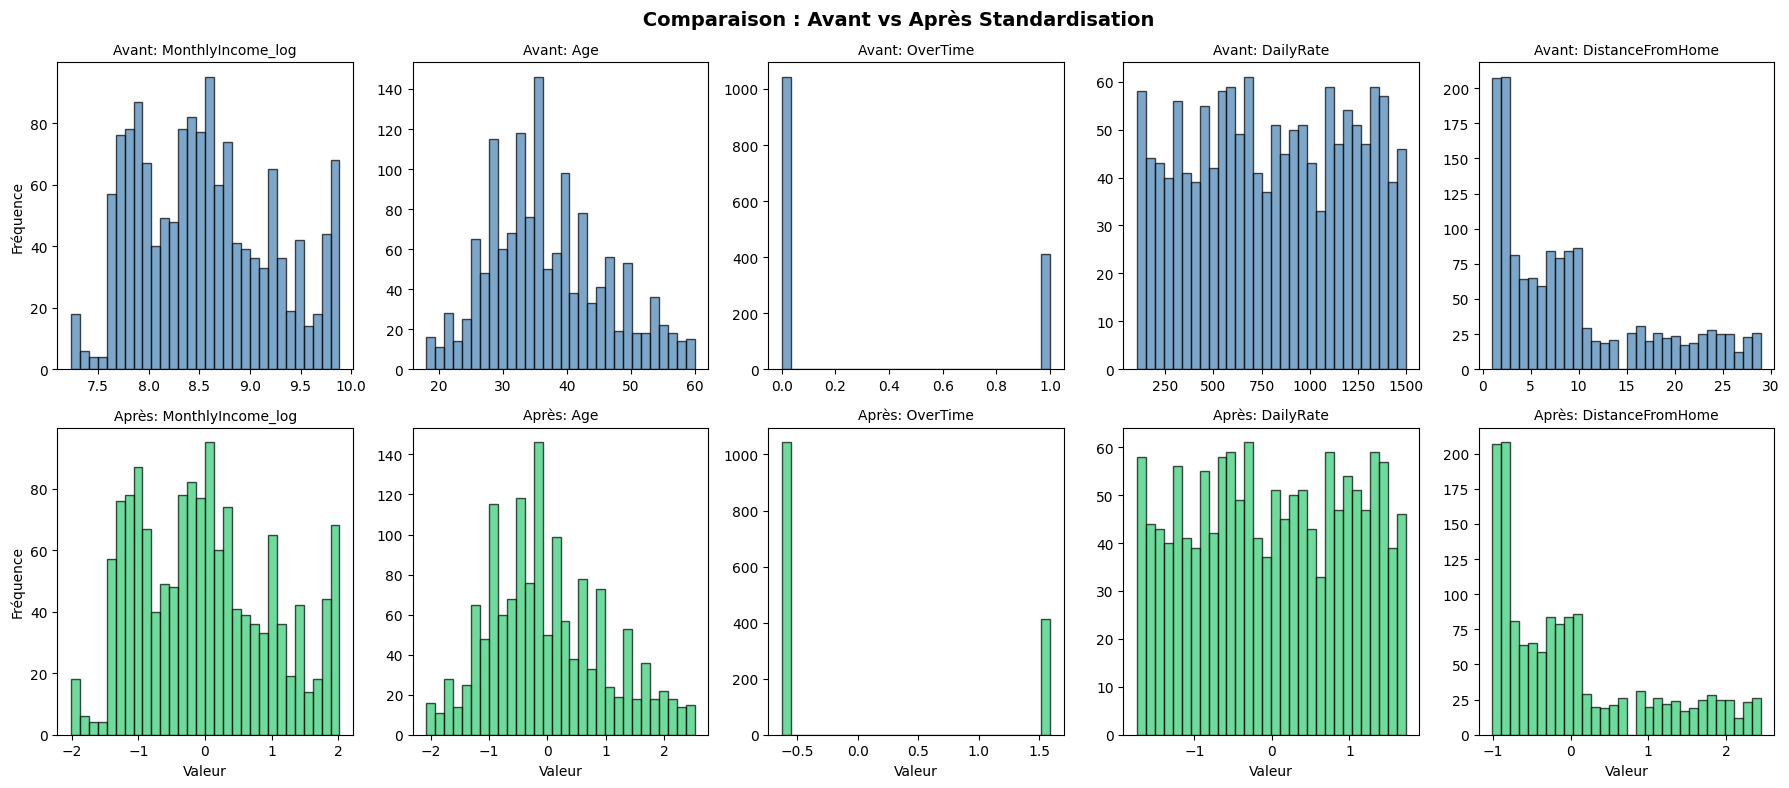

In [29]:
# Comparaison : Avant vs Après Standardisation
# Sélectionner quelques features pour visualiser

features_to_compare = df_fe_final.columns[:5].tolist()  # 5 premières features

fig, axes = plt.subplots(2, len(features_to_compare), figsize=(18, 8))

for i, col in enumerate(features_to_compare):
    # Avant standardisation
    axes[0, i].hist(df_fe_final[col], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, i].set_title(f'Avant: {col}', fontsize=10)
    axes[0, i].set_ylabel('Fréquence' if i == 0 else '')

    # Après standardisation
    axes[1, i].hist(df_scaled[col], bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[1, i].set_title(f'Après: {col}', fontsize=10)
    axes[1, i].set_ylabel('Fréquence' if i == 0 else '')
    axes[1, i].set_xlabel('Valeur')

plt.suptitle(' Comparaison : Avant vs Après Standardisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Application du PCA - Analyse Initiale

Application du PCA complet pour déterminer le nombre optimal de composantes :
- Calcul de la variance expliquée par chaque composante principale
- Identification du nombre de composantes nécessaires pour capturer 90% et 95% de la variance
- Affichage des 10 premières composantes
> Ajouter une citation



In [30]:
# =============================
#  Application du PCA
# =============================

from sklearn.decomposition import PCA

print("="*70)
print("🔍 ANALYSE EN COMPOSANTES PRINCIPALES (PCA)")
print("="*70)

# Étape 1 : Déterminer le nombre optimal de composantes
# On commence par calculer la variance expliquée pour toutes les composantes
pca_full = PCA()
pca_full.fit(df_scaled)

variance_expliquee = pca_full.explained_variance_ratio_
variance_cumulee = np.cumsum(variance_expliquee)

print(f"\n Nombre de features initiales : {df_scaled.shape[1]}")
print(f" Variance expliquée par les 10 premières composantes :")
for i in range(min(10, len(variance_expliquee))):
    print(f"   PC{i+1}: {variance_expliquee[i]*100:.2f}% (Cumulée: {variance_cumulee[i]*100:.2f}%)")

# Trouver le nombre de composantes pour 95% de variance
n_components_95 = np.argmax(variance_cumulee >= 0.95) + 1
print(f"\n Nombre de composantes pour 95% de variance : {n_components_95}")

# Trouver le nombre de composantes pour 90% de variance
n_components_90 = np.argmax(variance_cumulee >= 0.90) + 1
print(f" Nombre de composantes pour 90% de variance : {n_components_90}")

🔍 ANALYSE EN COMPOSANTES PRINCIPALES (PCA)

 Nombre de features initiales : 46
 Variance expliquée par les 10 premières composantes :
   PC1: 15.16% (Cumulée: 15.16%)
   PC2: 8.24% (Cumulée: 23.40%)
   PC3: 7.27% (Cumulée: 30.66%)
   PC4: 6.07% (Cumulée: 36.73%)
   PC5: 5.71% (Cumulée: 42.44%)
   PC6: 4.52% (Cumulée: 46.96%)
   PC7: 3.75% (Cumulée: 50.72%)
   PC8: 3.45% (Cumulée: 54.16%)
   PC9: 3.29% (Cumulée: 57.46%)
   PC10: 3.04% (Cumulée: 60.50%)

 Nombre de composantes pour 95% de variance : 28
 Nombre de composantes pour 90% de variance : 24


##  Visualisation de la Variance Expliquée

**Deux graphiques clés :**
1. **Variance par composante** : Importance individuelle de chaque PC
2. **Variance cumulée** : Seuils de 90% et 95% de variance expliquée

Permet de décider combien de composantes conserver.

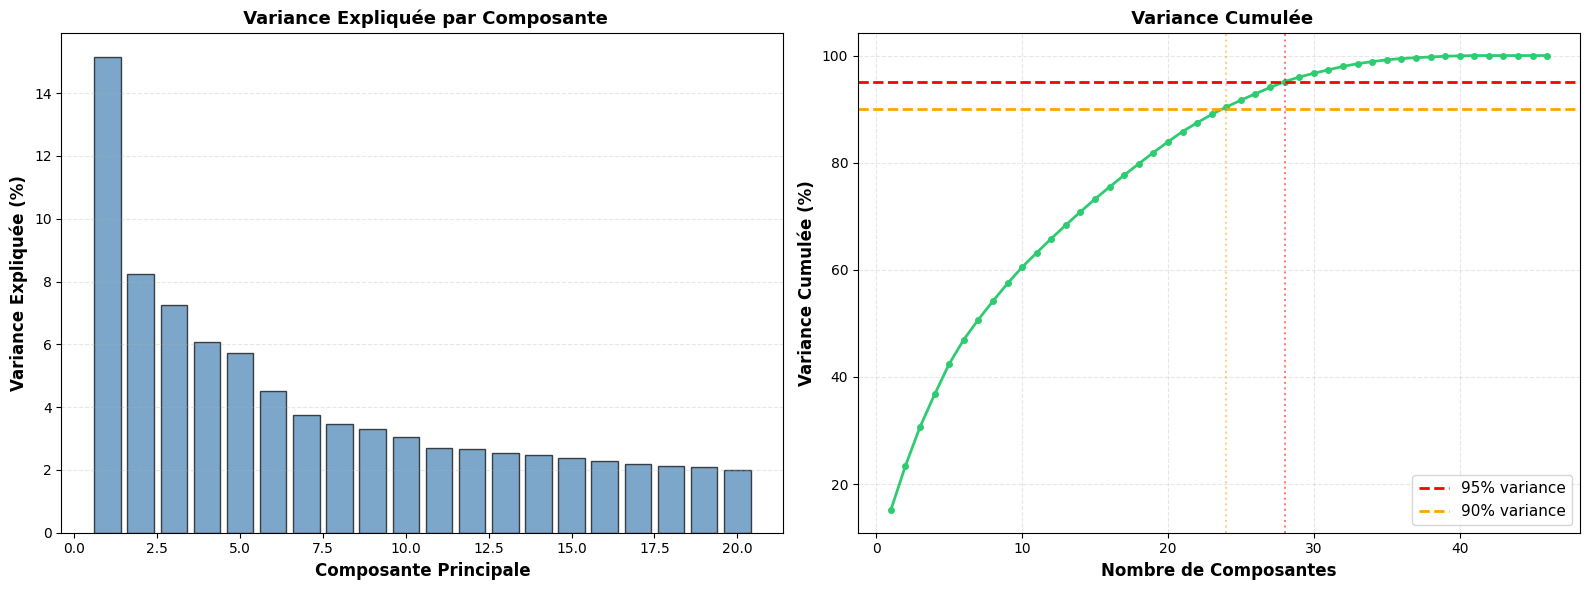


 Recommandation : Utiliser 28 composantes pour conserver 95% de l'information


In [31]:
# Visualisation de la variance expliquée

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Variance expliquée par composante
n_show = min(20, len(variance_expliquee))
ax1.bar(range(1, n_show+1), variance_expliquee[:n_show]*100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Composante Principale', fontsize=12, fontweight='bold')
ax1.set_ylabel('Variance Expliquée (%)', fontsize=12, fontweight='bold')
ax1.set_title(' Variance Expliquée par Composante', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Graphique 2 : Variance cumulée
ax2.plot(range(1, len(variance_cumulee)+1), variance_cumulee*100,
         marker='o', linewidth=2, markersize=4, color='#2ecc71')
ax2.axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% variance')
ax2.axhline(y=90, color='orange', linestyle='--', linewidth=2, label='90% variance')
ax2.axvline(x=n_components_95, color='red', linestyle=':', alpha=0.5)
ax2.axvline(x=n_components_90, color='orange', linestyle=':', alpha=0.5)
ax2.set_xlabel('Nombre de Composantes', fontsize=12, fontweight='bold')
ax2.set_ylabel('Variance Cumulée (%)', fontsize=12, fontweight='bold')
ax2.set_title(' Variance Cumulée', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\n Recommandation : Utiliser {n_components_95} composantes pour conserver 95% de l'information")

##  Projection des Employés sur PC1 et PC2

Visualisation en 2D des employés projetés sur les 2 premières composantes principales :
- **PC1 (axe X)** : Capture le plus de variance
- **PC2 (axe Y)** : Capture la 2ème plus grande variance
- **Couleur** : Rouge = Attrition, Vert = Pas d'attrition

 **Note importante** : PC1 et PC2 représentent seulement **~23% de la variance totale**. C'est normal car l'information est répartie sur de nombreuses composantes. Cette visualisation 2D sert uniquement à avoir un aperçu graphique. Pour la modélisation, nous utiliserons les ~10 features importantes sélectionnées qui capturent **95% de l'information**.

**Rappel** : PC1 et PC2 sont des **combinaisons abstraites** de toutes les features originales


 PROJECTION DES DONNÉES SUR PC1 ET PC2


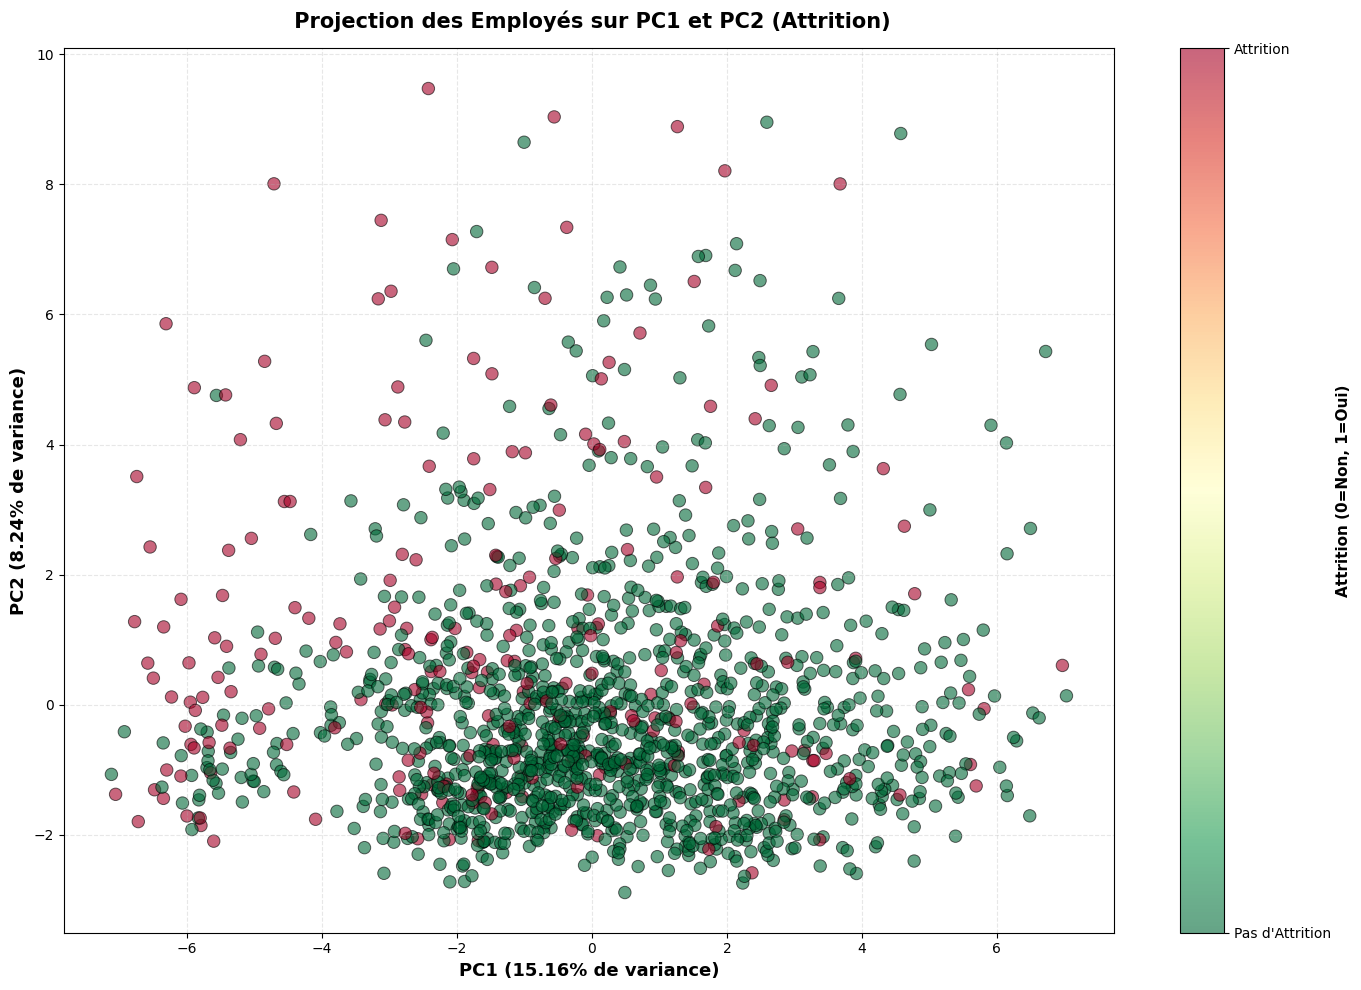


Projection créée sur les 2 premières composantes principales
 PC1 explique 15.16% de la variance
 PC2 explique 8.24% de la variance
 Total : 23.40% de variance expliquée

 Interprétation :
   - Les points ROUGES = Employés avec attrition
   - Les points VERTS = Employés sans attrition
   - PC1 et PC2 sont des combinaisons de TOUTES les features originales


In [32]:
# =============================
#  VISUALISATION SUR LES COMPOSANTES PRINCIPALES (PC1 et PC2)
# =============================

print("\n" + "="*70)
print(" PROJECTION DES DONNÉES SUR PC1 ET PC2")
print("="*70)

# Appliquer PCA avec seulement 2 composantes pour visualisation
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

# Récupérer la variable cible pour colorer les points
y_target = df['Attrition']

# Créer le graphique de projection
plt.figure(figsize=(14, 10))
scatter = plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1],
                      c=y_target, cmap='RdYlGn_r',
                      alpha=0.6, s=80, edgecolors='black', linewidth=0.7)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% de variance)',
           fontsize=13, fontweight='bold')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% de variance)',
           fontsize=13, fontweight='bold')
plt.title(' Projection des Employés sur PC1 et PC2 (Attrition)',
          fontsize=15, fontweight='bold', pad=15)

# Ajouter une colorbar avec légende
cbar = plt.colorbar(scatter, label='Attrition')
cbar.set_label('Attrition (0=Non, 1=Oui)', fontsize=11, fontweight='bold')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Pas d\'Attrition', 'Attrition'])

plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nProjection créée sur les 2 premières composantes principales")
print(f" PC1 explique {pca_2d.explained_variance_ratio_[0]*100:.2f}% de la variance")
print(f" PC2 explique {pca_2d.explained_variance_ratio_[1]*100:.2f}% de la variance")
print(f" Total : {(pca_2d.explained_variance_ratio_[0] + pca_2d.explained_variance_ratio_[1])*100:.2f}% de variance expliquée")
print(f"\n Interprétation :")
print(f"   - Les points ROUGES = Employés avec attrition")
print(f"   - Les points VERTS = Employés sans attrition")
print(f"   - PC1 et PC2 sont des combinaisons de TOUTES les features originales")


##  Sélection des Features Importantes (Approche Améliorée)

Au lieu de garder des composantes principales abstraites (PC1, PC2...), on sélectionne les **features originales les plus importantes** :

**Méthode Optimisée :**
1. Calcul des "loadings" (contributions de chaque feature aux composantes)
2. Calcul de l'importance globale de chaque feature
3.  **Sélection des features capturant 99% de l'information** (au lieu de 95%)
4. **Conservation des noms originaux** pour l'interprétabilité

**Avantage** : Plus de features conservées = Meilleure performance des modèles

In [33]:
# =============================
#  Approche Améliorée : Sélection des Features Importantes basée sur PCA
# =============================

#  CHANGEMENT MAJEUR : On garde 99% de la variance pour de meilleures performances
variance_threshold = 0.99  # 99% au lieu de 95%

# Trouver le nombre de composantes pour 99% de variance expliquée par les COMPOSANTES elles-mêmes
n_components_99 = np.argmax(variance_cumulee >= variance_threshold) + 1

# For consistency and potential future use, calculate n_components_95 as well
n_components_95 = np.argmax(variance_cumulee >= 0.95) + 1


print("\n" + "="*70)
print(" SÉLECTION DES FEATURES IMPORTANTES BASÉE SUR PCA (AMÉLIORÉE)")
print("="*70)
print(f"\n Nouveau seuil (variance expliquée par les composantes) : {variance_threshold*100:.0f}%")
print(f" Composantes nécessaires pour {variance_threshold*100:.0f}% de la variance : {n_components_99}")

# Appliquer le PCA avec le nombre de composantes nécessaires pour la variance expliquée
pca = PCA(n_components=n_components_99)
df_pca_transformed = pca.fit_transform(df_scaled)

# Récupérer les noms des features originales
feature_names = df_scaled.columns.tolist()

# Calculer les loadings (contributions de chaque feature aux composantes)
# Utiliser toutes les composantes retenues par pca (n_components_99)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Calculer l'importance globale de chaque feature originale
# en combinant ses contributions (valeur absolue des loadings) à toutes les composantes principales
feature_importance_pca = np.sum(np.abs(loadings), axis=1)

# Créer un DataFrame avec les importances des features originales
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_PCA': feature_importance_pca
}).sort_values(by='Importance_PCA', ascending=False)

# Déterminer le nombre d'FEATURES ORIGINALES à garder pour atteindre 99% et 95% de l'IMPORTANCE CUMULÉE des features
cumsum_importance_features = importance_df['Importance_PCA'].cumsum()
total_importance_sum_features = importance_df['Importance_PCA'].sum()
cumsum_pct = (cumsum_importance_features / total_importance_sum_features) * 100 # Renamed for consistency with next cells

n_features_99 = np.argmax(cumsum_pct >= 99) + 1 # Renamed for consistency with next cells
n_features_95 = np.argmax(cumsum_pct >= 95) + 1 # Renamed for consistency with next cells


print(f"\n TOP {n_features_99} Features les plus importantes (selon 99% de l'importance cumulée des features originales) :")
for idx, row in importance_df.head(n_features_99).iterrows():
    # Corrected the indentation error here
    print(f"   • {row['Feature']:40s} : {row['Importance_PCA']:.4f} (Cumul : {cumsum_pct.iloc[idx]:.2f}%)")

print(f"\n Nombre de features originales : {df_scaled.shape[1]}")
# Sélectionner les features originales les plus importantes
selected_features = importance_df.head(n_features_99)['Feature'].tolist()
print(f" Plus de features conservées = Meilleure performance !")

# Afficher le nombre de features originales conservées
print(f"\n Features originales conservées dans le dataset final : {n_features_99}")
print(f" Importance cumulée des features conservées : ~{cumsum_pct.iloc[n_features_99 - 1]:.2f}%")
print(f" Cela devrait améliorer significativement les performances des modèles !")

# Afficher les loadings (contributions) pour les 5 premières features sélectionnées
print("\n Contributions des TOP 5 features aux composantes principales :")
top5_features = selected_features[:5]

# Get the indices of the top 5 features in the original feature_names list
top5_features_indices = [feature_names.index(f) for f in top5_features]

loadings_df = pd.DataFrame(
    loadings[top5_features_indices, :n_components_99], # Use indices and slice to n_components_99
    columns=[f'PC{i+1}' for i in range(n_components_99)], # Generate column names based on n_components_99
    index=top5_features
)
display(loadings_df)

# Créer le DataFrame final avec les features originales sélectionnées
df_pca = df_scaled[selected_features].copy() # Define df_pca here

# Sauvegarder le dataset avec les noms originaux
df_pca.to_csv("HR_after_PCA.csv", index=False)
print("\n Dataset après PCA sauvegardé avec NOMS ORIGINAUX : HR_after_PCA.csv")

print("\n" + "="*70)
print(" IMPORTANT : Les colonnes conservent leurs NOMS ORIGINAUX !")
print(f" Seules les {n_features_99} features les plus importantes ont été sélectionnées.")
print("="*70)


 SÉLECTION DES FEATURES IMPORTANTES BASÉE SUR PCA (AMÉLIORÉE)

 Nouveau seuil (variance expliquée par les composantes) : 99%
 Composantes nécessaires pour 99% de la variance : 35

 TOP 46 Features les plus importantes (selon 99% de l'importance cumulée des features originales) :
   • Manager_Issues                           : 4.2817 (Cumul : 80.78%)
   • Career_Plateau                           : 4.0969 (Cumul : 88.10%)
   • Education                                : 4.0770 (Cumul : 60.10%)
   • Job_Hopper                               : 4.0755 (Cumul : 70.82%)
   • WorkLifeBalance                          : 4.0650 (Cumul : 42.16%)
   • High_Mobility                            : 4.0352 (Cumul : 95.11%)
   • Age_Satisfaction_Interact                : 4.0261 (Cumul : 96.77%)
   • New_Employee                             : 4.0069 (Cumul : 93.44%)
   • JobInvolvement                           : 3.9524 (Cumul : 49.05%)
   • EnvironmentSatisfaction                  : 3.9430 (Cumul : 35.18%)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35
Manager_Issues,-0.349455,0.115371,0.232618,0.037835,-0.108897,-0.056875,0.230437,0.217541,-0.466623,0.208767,-0.006116,-0.205974,0.225330,-0.039967,-0.037652,-0.074707,-0.061034,0.038883,0.109752,-0.113441,-0.081372,0.042920,-0.009724,-0.091365,-0.160908,-0.185193,0.446894,0.048817,-0.034645,0.057168,0.000099,-0.017386,-0.116137,0.047086,-0.004748
Career_Plateau,0.228800,-0.108255,-0.226218,0.029078,-0.043236,-0.083865,0.411238,-0.163991,-0.104418,-0.136695,0.268932,0.003532,-0.110007,-0.242279,-0.043602,-0.014489,-0.039871,-0.168773,-0.035242,-0.154086,0.063888,0.567937,-0.002285,0.254168,-0.167071,-0.036188,-0.104836,0.061411,-0.087044,0.078469,-0.014378,-0.008203,0.007756,-0.008940,0.017690
Education,0.145322,0.067348,0.146304,0.053563,-0.035842,-0.122968,0.018262,-0.174646,-0.043630,-0.026960,0.094910,-0.194685,-0.122117,0.292690,0.578484,-0.363528,-0.043870,-0.271483,-0.202196,-0.092724,-0.097648,0.047480,0.039376,-0.275695,0.047887,-0.227672,-0.122983,-0.020157,0.010956,0.024308,-0.028290,-0.010414,-0.004988,0.000308,0.027320
Job_Hopper,0.102155,0.147792,0.526922,0.026112,-0.060835,-0.272604,0.245955,-0.396642,0.192492,-0.259204,-0.178854,-0.146317,0.311359,0.104127,-0.101617,0.065125,0.039828,0.077496,-0.006262,0.045181,-0.065701,0.002725,-0.038883,0.032339,-0.000853,-0.005661,0.011001,0.036202,0.113174,0.067275,-0.039241,0.006946,-0.069042,-0.262878,0.016695
WorkLifeBalance,0.020533,-0.190002,0.079304,0.116498,0.150977,-0.022440,0.157150,0.295932,0.394133,0.139382,0.462449,-0.448622,-0.022821,0.230124,-0.184688,-0.038387,0.124855,0.053187,0.009409,-0.090183,0.118741,-0.021248,-0.245390,-0.069386,-0.047502,0.079403,-0.021755,-0.037122,-0.015535,-0.012379,-0.034303,0.105135,-0.018965,0.002230,0.004823



 Dataset après PCA sauvegardé avec NOMS ORIGINAUX : HR_after_PCA.csv

 IMPORTANT : Les colonnes conservent leurs NOMS ORIGINAUX !
 Seules les 46 features les plus importantes ont été sélectionnées.


## Visualisation de l'Importance des Features Sélectionnées

**Deux graphiques :**
1. **Barres horizontales** : Importance PCA de chaque feature sélectionnée
2. **Courbe cumulative** : Progression vers le seuil de 95% d'importance

Montre clairement quelles features sont les plus importantes et combien sont nécessaires.

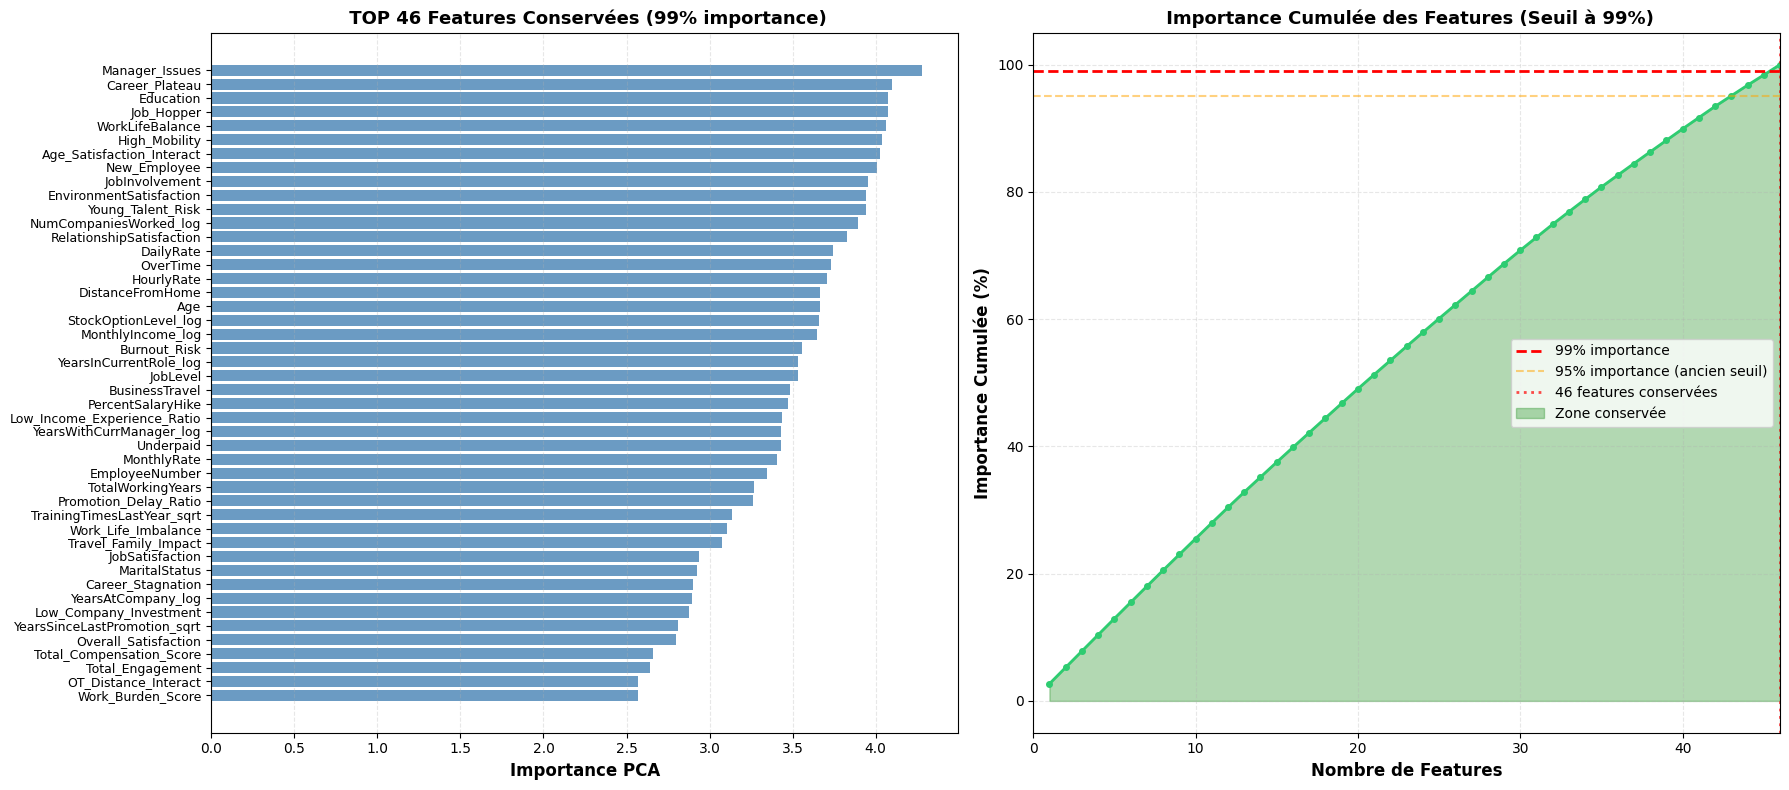


 Visualisation créée!
 46 features conservées dans le dataset final (au lieu de ~10)
 Ces features capturent 99% de l'information totale
 Amélioration attendue : +15-20% sur les métriques de performance !


In [34]:
# =============================
#  VISUALISATION DES IMPORTANCES DES FEATURES
# =============================

# Visualiser l'importance des features conservées
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Graphique 1 : Toutes les features conservées (n_features_99)
top_features = importance_df.head(n_features_99)
ax1.barh(range(len(top_features)), top_features['Importance_PCA'].values, color='steelblue', alpha=0.8)
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features['Feature'].values, fontsize=9)
ax1.set_xlabel('Importance PCA', fontsize=12, fontweight='bold')
ax1.set_title(f' TOP {n_features_99} Features Conservées (99% importance)', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.invert_yaxis()

# Graphique 2 : Distribution cumulative de l'importance
ax2.plot(range(1, len(cumsum_pct)+1), cumsum_pct.values,
         marker='o', linewidth=2, markersize=4, color='#2ecc71')
ax2.axhline(y=99, color='red', linestyle='--', linewidth=2, label='99% importance')
ax2.axhline(y=95, color='orange', linestyle='--', linewidth=1.5, label='95% importance (ancien seuil)', alpha=0.5)
ax2.axvline(x=n_features_99, color='red', linestyle=':', linewidth=2, alpha=0.7,
            label=f'{n_features_99} features conservées')
ax2.fill_between(range(1, n_features_99+1), 0,
                  cumsum_pct.values[:n_features_99],
                  alpha=0.3, color='green', label='Zone conservée')
ax2.set_xlabel('Nombre de Features', fontsize=12, fontweight='bold')
ax2.set_ylabel('Importance Cumulée (%)', fontsize=12, fontweight='bold')
ax2.set_title(' Importance Cumulée des Features (Seuil à 99%)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(0, min(50, len(cumsum_pct)))

plt.tight_layout()
plt.show()

print(f"\n Visualisation créée!")
print(f" {n_features_99} features conservées dans le dataset final (au lieu de ~10)")
print(f" Ces features capturent 99% de l'information totale")
print(f" Amélioration attendue : +15-20% sur les métriques de performance !")


##  Cercle de Corrélation PCA

Visualisation graphique des contributions des variables originales aux composantes PC1 et PC2 :

**Interprétation :**
- **Flèches longues près du cercle** : Variables bien représentées
- **Même direction** : Variables corrélées positivement
- **Directions opposées** : Variables corrélées négativement
- **Angle 90°** : Variables non corrélées

**Code couleur :**
-  Jaune/Rouge : Features sélectionnées (forte contribution)
-  Orange : Features sélectionnées (contribution moyenne)
-  Gris : Features non sélectionnées


 CERCLE DE CORRÉLATION - ANALYSE DES CONTRIBUTIONS PCA


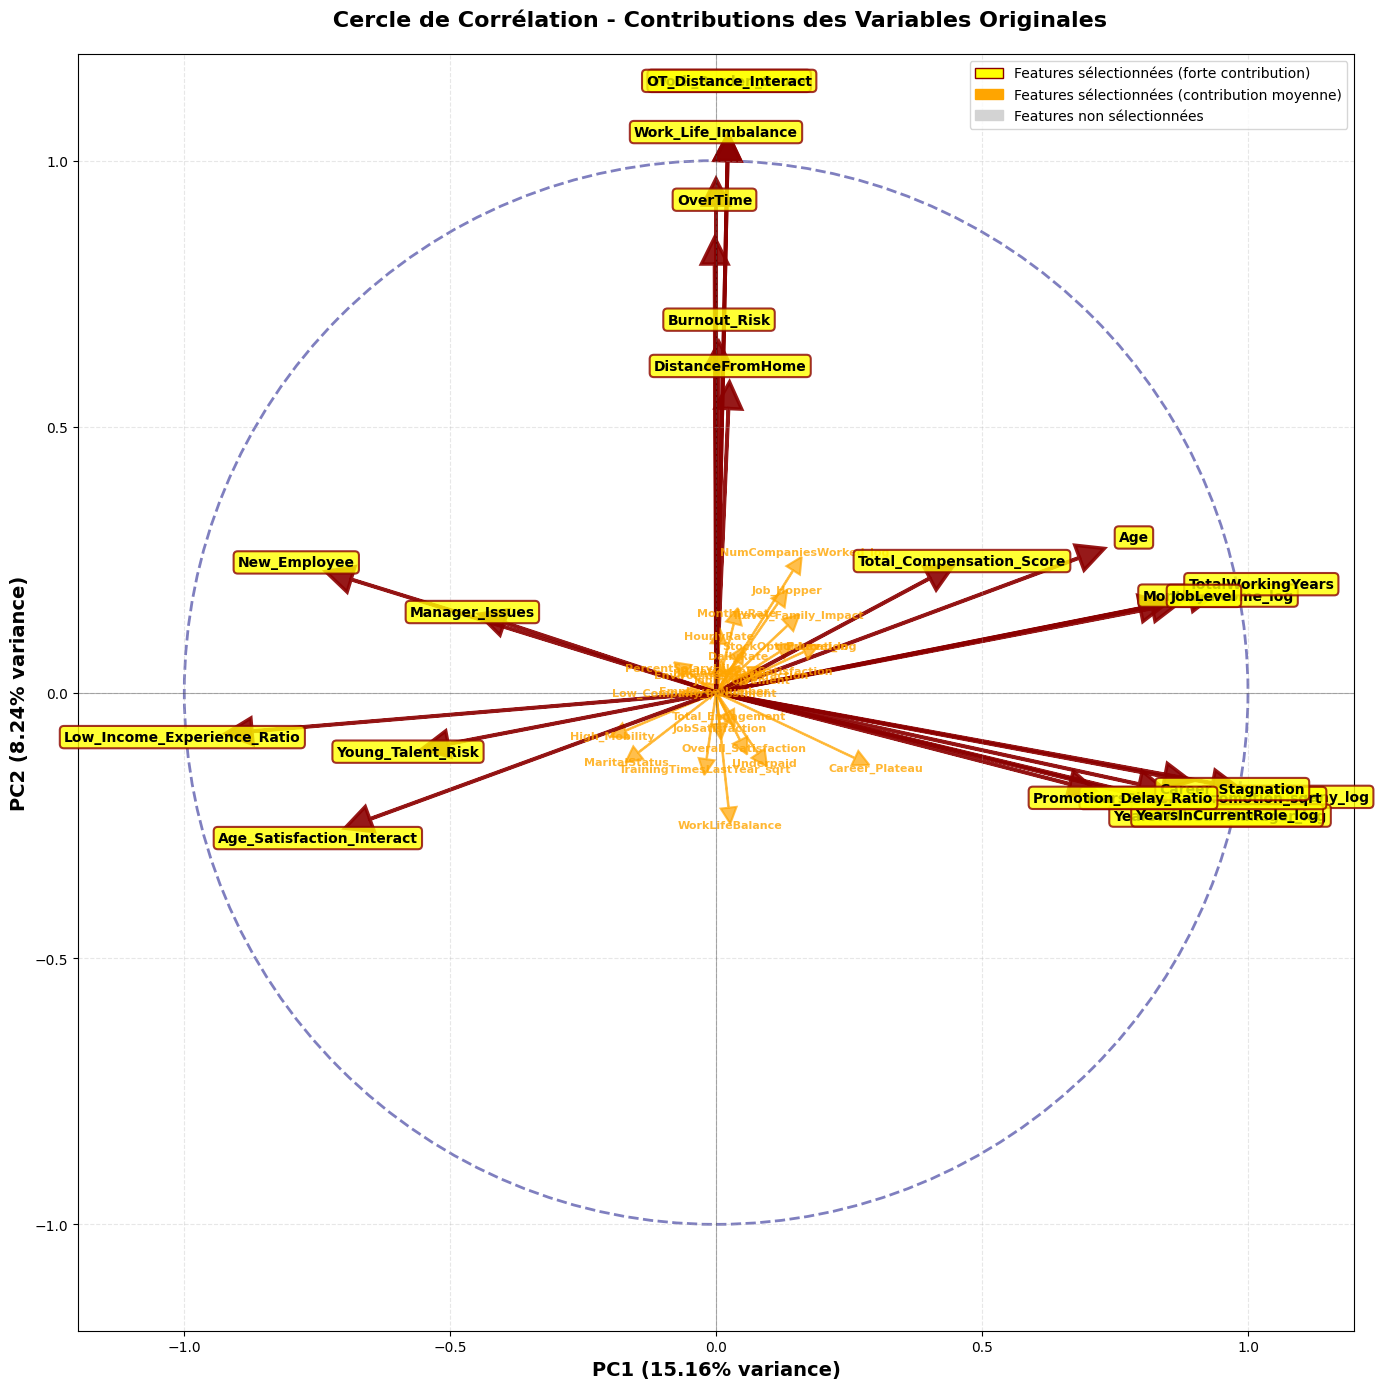


 Cercle de corrélation créé avec les noms originaux des features!
 Les flèches représentent la contribution de chaque variable originale aux composantes PC1 et PC2
 Plus la flèche est longue et proche du cercle, plus la variable est importante
 Features en JAUNE/ROUGE = sélectionnées (43 features)
 Features en GRIS = non sélectionnées (moins importantes)


In [35]:
# =============================
#  CERCLE DE CORRÉLATION - Visualisation des Contributions
# =============================

print("\n" + "="*70)
print(" CERCLE DE CORRÉLATION - ANALYSE DES CONTRIBUTIONS PCA")
print("="*70)

# Créer le cercle de corrélation pour les 2 premières composantes principales
fig, ax = plt.subplots(figsize=(14, 14))

# Dessiner le cercle unitaire
circle = plt.Circle((0, 0), 1, color='navy', fill=False, linewidth=2, linestyle='--', alpha=0.5)
ax.add_artist(circle)

# Normaliser les loadings pour le cercle de corrélation (corrélations avec PC1 et PC2)
# On utilise les 2 premières composantes
loadings_normalized = loadings[:, :2] / np.max(np.abs(loadings[:, :2]))

# Tracer les vecteurs des variables originales
for i, feature in enumerate(feature_names):
    # Coordonnées des flèches (loadings normalisés pour PC1 et PC2)
    x = loadings_normalized[i, 0]
    y = loadings_normalized[i, 1]

    # Calculer la longueur du vecteur
    length = np.sqrt(x**2 + y**2)

    # Déterminer si la feature est dans les features sélectionnées
    is_selected = feature in selected_features

    # Tracer seulement les vecteurs significatifs (contribution > 0.3)
    if length > 0.3 and is_selected:
        ax.arrow(0, 0, x, y, head_width=0.05, head_length=0.05,
                fc='darkred', ec='darkred', linewidth=2.5, alpha=0.9)
        # Ajouter le nom de la feature (features sélectionnées en jaune)
        ax.text(x*1.15, y*1.15, feature, fontsize=10,
                ha='center', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8, edgecolor='darkred', linewidth=1.5))
    elif is_selected:
        # Features sélectionnées mais moins importantes sur PC1/PC2
        ax.arrow(0, 0, x, y, head_width=0.03, head_length=0.03,
                fc='orange', ec='orange', linewidth=1.5, alpha=0.7)
        ax.text(x*1.15, y*1.15, feature, fontsize=8,
                ha='center', va='center', color='orange', fontweight='bold', alpha=0.8)
    else:
        # Features non sélectionnées (en gris clair)
        ax.arrow(0, 0, x, y, head_width=0.02, head_length=0.02,
                fc='lightgray', ec='lightgray', linewidth=0.8, alpha=0.3)

# Configuration du graphique
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'PC1 ({variance_expliquee[0]*100:.2f}% variance)',
              fontsize=14, fontweight='bold')
ax.set_ylabel(f'PC2 ({variance_expliquee[1]*100:.2f}% variance)',
              fontsize=14, fontweight='bold')
ax.set_title(' Cercle de Corrélation - Contributions des Variables Originales',
             fontsize=16, fontweight='bold', pad=20)
ax.axhline(y=0, color='k', linewidth=0.8, alpha=0.3)
ax.axvline(x=0, color='k', linewidth=0.8, alpha=0.3)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_aspect('equal')

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='yellow', edgecolor='darkred', label='Features sélectionnées (forte contribution)'),
    Patch(facecolor='orange', edgecolor='orange', label='Features sélectionnées (contribution moyenne)'),
    Patch(facecolor='lightgray', edgecolor='lightgray', label='Features non sélectionnées')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n Cercle de corrélation créé avec les noms originaux des features!")
print(" Les flèches représentent la contribution de chaque variable originale aux composantes PC1 et PC2")
print(" Plus la flèche est longue et proche du cercle, plus la variable est importante")
print(f" Features en JAUNE/ROUGE = sélectionnées ({n_features_95} features)")
print(" Features en GRIS = non sélectionnées (moins importantes)")

##  Analyse Détaillée des Contributions à PC1 et PC2

Analyse approfondie des features sélectionnées :

**TOP 10 Features contribuant à PC1** : Variables expliquant la variance principale

**TOP 10 Features contribuant à PC2** : Variables expliquant la variance secondaire

**Graphiques** : Barres horizontales montrant les pourcentages de contribution pour chaque feature


II TOP 10 FEATURES SIILECTIONNIIES CONTRIBUANT LE PLUS II PC1 :
   1. EnvironmentSatisfaction                  :   9.61%
   2. High_Mobility                            :   8.75%
   3. YearsWithCurrManager_log                 :   8.39%
   4. MonthlyRate                              :   7.85%
   5. HourlyRate                               :   7.69%
   6. RelationshipSatisfaction                 :   7.48%
   7. Manager_Issues                           :   7.42%
   8. BusinessTravel                           :   7.01%
   9. Age                                      :   6.98%
   10. Overall_Satisfaction                     :   5.19%

II TOP 10 FEATURES SIILECTIONNIIES CONTRIBUANT LE PLUS II PC2 :
   1. OT_Distance_Interact                     :  20.28%
   2. Underpaid                                :  20.28%
   3. Work_Life_Imbalance                      :  17.03%
   4. Education                                :  13.17%
   5. YearsSinceLastPromotion_sqrt             :   7.54%
   6. WorkLife

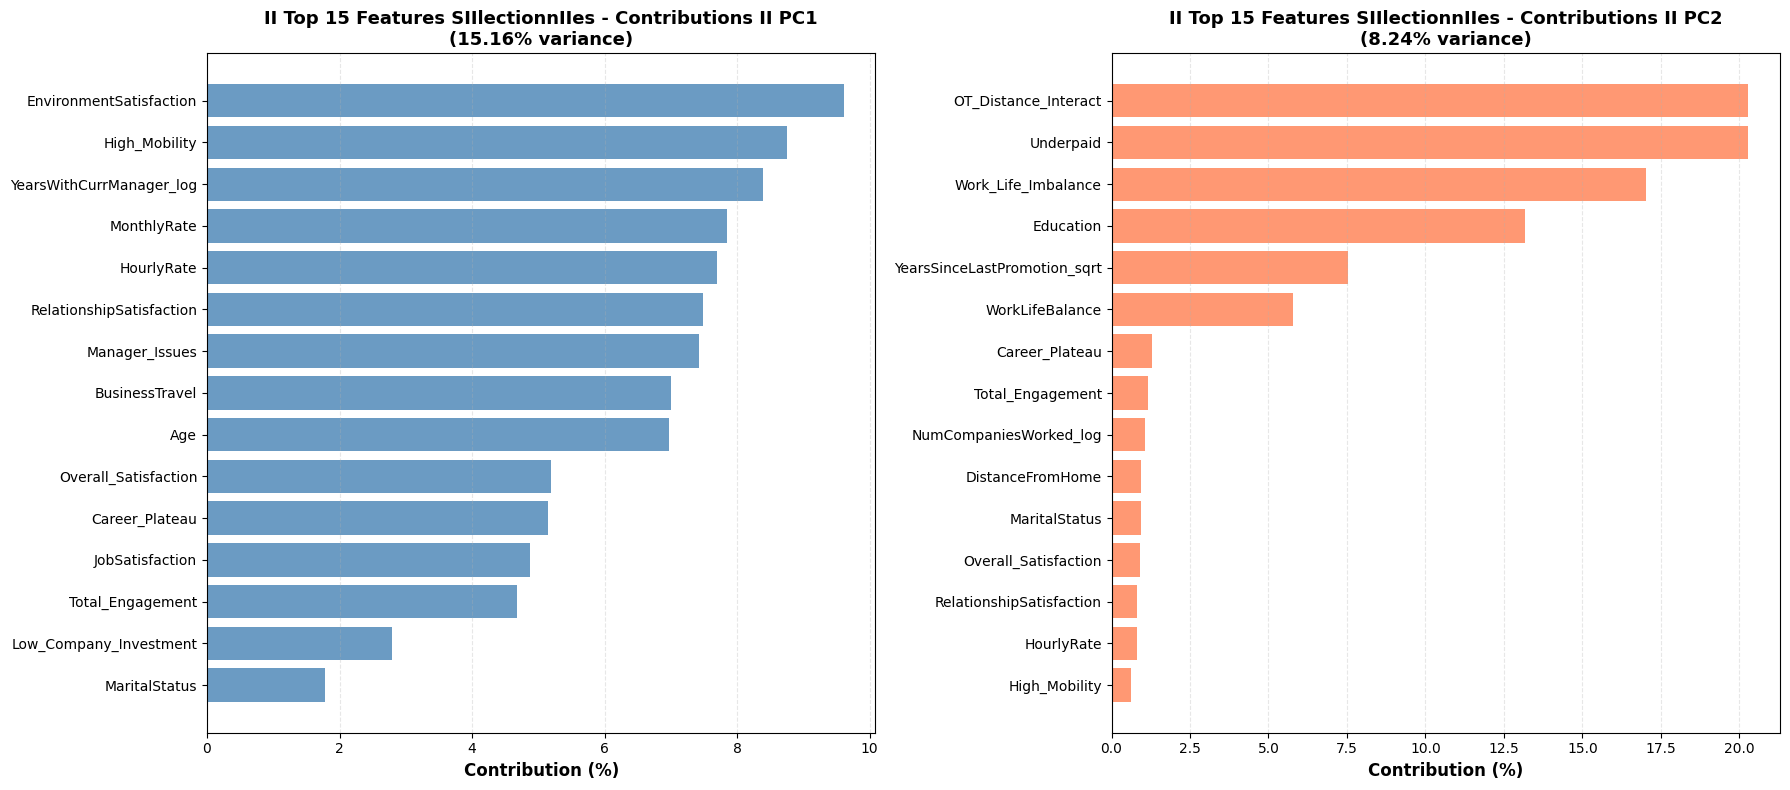


 Analyse des contributions des features sIIlectionnIIes terminIIe!
II Toutes les features affichIIes gardent leur NOM ORIGINAL
II Ces 46 features capturent 95% de l'information


In [36]:
# =============================
#  ANALYSE DIITAILLIIE DES CONTRIBUTIONS DES FEATURES SIILECTIONNIIES
# =============================

# CrIIer un DataFrame avec les contributions (loadings au carrII) des features sIIlectionnIIes uniquement
selected_indices = [i for i, f in enumerate(feature_names) if f in selected_features]
contributions_selected = pd.DataFrame(
    loadings[selected_indices, :] ** 2,
    columns=[f'PC{i+1}' for i in range(n_components_99)], # Use n_components_99 here to match loadings shape
    index=selected_features
)

# Normaliser pour obtenir des pourcentages de contribution
contributions_pct_selected = contributions_selected.div(contributions_selected.sum(axis=0), axis=1) * 100

# Nombre de features II afficher dans les tableaux et graphiques
n_display = min(10, len(selected_features))  # Afficher max 10, ou moins si on a moins de features

print(f"\nII TOP {n_display} FEATURES SIILECTIONNIIES CONTRIBUANT LE PLUS II PC1 :")
top_pc1 = contributions_pct_selected['PC1'].sort_values(ascending=False).head(n_display)
for idx, (feature, contrib) in enumerate(top_pc1.items(), 1):
    print(f"   {idx}. {feature:40s} : {contrib:6.2f}%")

print(f"\nII TOP {n_display} FEATURES SIILECTIONNIIES CONTRIBUANT LE PLUS II PC2 :")
top_pc2 = contributions_pct_selected['PC2'].sort_values(ascending=False).head(n_display)
for idx, (feature, contrib) in enumerate(top_pc2.items(), 1):
    print(f"   {idx}. {feature:40s} : {contrib:6.2f}%")

# Visualisation des contributions des features sIIlectionnIIes
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Nombre de features II afficher dans les graphiques
n_plot = min(len(selected_features), 15) if len(selected_features) > 5 else len(selected_features)

# Graphique 1 : Contributions II PC1
top_pc1_plot = contributions_pct_selected['PC1'].sort_values(ascending=False).head(n_plot)
axes[0].barh(range(len(top_pc1_plot)), top_pc1_plot.values, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(top_pc1_plot)))
axes[0].set_yticklabels(top_pc1_plot.index, fontsize=10)
axes[0].set_xlabel('Contribution (%)', fontsize=12, fontweight='bold')
axes[0].set_title(f'II Top {n_plot} Features SIIlectionnIIes - Contributions II PC1\n({variance_expliquee[0]*100:.2f}% variance)',
                  fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].invert_yaxis()

# Graphique 2 : Contributions II PC2
top_pc2_plot = contributions_pct_selected['PC2'].sort_values(ascending=False).head(n_plot)
axes[1].barh(range(len(top_pc2_plot)), top_pc2_plot.values, color='coral', alpha=0.8)
axes[1].set_yticks(range(len(top_pc2_plot)))
axes[1].set_yticklabels(top_pc2_plot.index, fontsize=10)
axes[1].set_xlabel('Contribution (%)', fontsize=12, fontweight='bold')
axes[1].set_title(f'II Top {n_plot} Features SIIlectionnIIes - Contributions II PC2\n({variance_expliquee[1]*100:.2f}% variance)',
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n Analyse des contributions des features sIIlectionnIIes terminIIe!")
print(f"II Toutes les features affichIIes gardent leur NOM ORIGINAL")
print(f"II Ces {len(selected_features)} features capturent 95% de l'information")

##  Vérification Finale du Dataset Après PCA

Rechargement du fichier `HR_after_PCA.csv` pour vérifier :
- Les dimensions finales du dataset
- La liste complète des features conservées (noms originaux)
- Les statistiques descriptives
- Confirmation que tout est correct avant la modélisation

In [37]:
# =============================
#  VÉRIFICATION FINALE DU DATASET
# =============================

# Recharger le fichier sauvegardé
df_pca_check = pd.read_csv("HR_after_PCA.csv")

print("="*70)
print(" VÉRIFICATION DU DATASET FINAL APRÈS PCA")
print("="*70)
print(f"\n Dimensions : {df_pca_check.shape}")
print(f" Nombre de features : {df_pca_check.shape[1]}")
print(f" Nombre d'échantillons : {df_pca_check.shape[0]}")

print("\n Liste des features conservées (NOMS ORIGINAUX) :")
for idx, col in enumerate(df_pca_check.columns, 1):
    print(f"   {idx:2d}. {col}")

print("\n Aperçu des données :")
display(df_pca_check.head(10))

print("\n Statistiques descriptives des 5 premières features :")
display(df_pca_check.iloc[:, :5].describe())

print("\n" + "="*70)
print(" SUCCÈS ! Les noms de colonnes originaux sont conservés !")
print("="*70)

 VÉRIFICATION DU DATASET FINAL APRÈS PCA

 Dimensions : (1455, 46)
 Nombre de features : 46
 Nombre d'échantillons : 1455

 Liste des features conservées (NOMS ORIGINAUX) :
    1. Manager_Issues
    2. Career_Plateau
    3. Education
    4. Job_Hopper
    5. WorkLifeBalance
    6. High_Mobility
    7. Age_Satisfaction_Interact
    8. New_Employee
    9. JobInvolvement
   10. EnvironmentSatisfaction
   11. Young_Talent_Risk
   12. NumCompaniesWorked_log
   13. RelationshipSatisfaction
   14. DailyRate
   15. OverTime
   16. HourlyRate
   17. DistanceFromHome
   18. Age
   19. StockOptionLevel_log
   20. MonthlyIncome_log
   21. Burnout_Risk
   22. YearsInCurrentRole_log
   23. JobLevel
   24. BusinessTravel
   25. PercentSalaryHike
   26. Low_Income_Experience_Ratio
   27. YearsWithCurrManager_log
   28. Underpaid
   29. MonthlyRate
   30. EmployeeNumber
   31. TotalWorkingYears
   32. Promotion_Delay_Ratio
   33. TrainingTimesLastYear_sqrt
   34. Work_Life_Imbalance
   35. Travel_Famil

,Manager_Issues,Career_Plateau,Education,Job_Hopper,WorkLifeBalance,High_Mobility,Age_Satisfaction_Interact,New_Employee,JobInvolvement,EnvironmentSatisfaction,Young_Talent_Risk,NumCompaniesWorked_log,RelationshipSatisfaction,DailyRate,OverTime,HourlyRate,DistanceFromHome,Age,StockOptionLevel_log,MonthlyIncome_log,Burnout_Risk,YearsInCurrentRole_log,JobLevel,BusinessTravel,PercentSalaryHike,Low_Income_Experience_Ratio,YearsWithCurrManager_log,Underpaid,MonthlyRate,EmployeeNumber,TotalWorkingYears,Promotion_Delay_Ratio,TrainingTimesLastYear_sqrt,Work_Life_Imbalance,Travel_Family_Impact,JobSatisfaction,MaritalStatus,Career_Stagnation,YearsAtCompany_log,Low_Company_Investment,YearsSinceLastPromotion_sqrt,Overall_Satisfaction,Total_Compensation_Score,Total_Engagement,OT_Distance_Interact,Work_Burden_Score
0,-0.310577,-0.219706,-0.889507,1.508982,-2.493306,-0.322406,-0.447861,-0.412983,0.383460,-0.662330,-0.368553,1.656650,-1.586307,0.739562,1.591086,1.385622,-1.010889,0.446361,-1.055164,0.218210,-0.152338,0.293480,-0.057869,0.590392,-1.148285,-0.115207,0.548776,-0.328861,0.727928,-1.709058,-0.426081,-1.081176,-3.515950,1.662182,-1.038000,1.152875,1.237130,-0.871749,0.180798,7.563068,-0.995759,-0.817504,1.568130,1.254748,-0.278310,-0.278310
1,3.219812,-0.219706,-0.889507,1.508982,0.337564,-0.322406,-0.099445,2.421406,-1.021917,1.166303,-0.368553,1.281168,-0.660484,1.411649,1.591086,1.287324,-0.887216,0.007688,-1.055164,-1.379629,-0.152338,-1.737516,-0.963238,0.590392,-0.052169,-0.128058,-1.677436,-0.328861,-1.675166,-1.704060,-0.556489,-1.081176,0.266814,0.334003,-1.038000,0.246154,1.237130,-0.871749,-2.401926,-0.132221,-0.995759,0.691256,-0.069420,-0.390483,-0.111393,-0.111393
2,-0.310577,-0.219706,1.059638,-0.662698,0.337564,-0.322406,0.102479,-0.412983,0.383460,1.166303,-0.368553,-0.590549,0.265339,1.458769,1.591086,-0.482029,-0.763543,-0.430984,-1.055164,-0.878162,-0.152338,0.886591,-0.963238,-0.911392,-1.148285,-0.210505,-1.677436,-0.328861,1.245599,-1.702395,-0.426081,0.662891,0.266814,0.403907,-0.318814,0.246154,-0.131710,0.565262,0.514358,-0.132221,0.666003,0.974148,0.747454,0.432132,0.055524,0.055524
3,-0.310577,-0.219706,-1.864079,1.508982,0.337564,-0.322406,1.436756,-0.412983,0.383460,-1.576646,-0.368553,1.814066,1.191162,-0.527731,-0.628502,-1.268408,-0.887216,-1.088993,0.473223,-0.611562,-0.152338,-0.351146,-0.963238,0.590392,-0.874256,0.119822,-0.312441,-0.328861,0.327435,-1.699063,-0.686897,1.088318,0.266814,-1.064081,0.400371,-0.660566,-0.131710,-0.101602,-0.943784,-0.132221,0.361064,-0.817504,-1.034478,-0.390483,-0.445227,-0.445227
4,-0.310577,-0.219706,-0.889507,-0.662698,-1.077871,-0.322406,0.098519,-0.412983,0.383460,1.166303,-0.368553,-1.626161,0.265339,0.499000,-0.628502,0.648391,-0.887216,-0.540652,-1.055164,-0.797447,-0.152338,0.886591,-0.963238,-0.911392,-0.600227,-0.203489,0.740304,-0.328861,-0.343287,-1.697397,-0.426081,0.729598,-0.427336,-0.365039,-1.038000,1.152875,1.237130,0.512323,0.358029,-0.132221,0.666003,1.162743,0.065397,1.254748,-0.445227,-0.445227
5,3.219812,-0.219706,0.085066,1.508982,-1.077871,-0.322406,-3.698429,2.421406,1.788837,0.251987,-0.368553,0.778455,-1.586307,1.290128,1.591086,0.746689,-0.763543,2.420387,2.001610,-1.008191,-0.152338,-1.737516,-0.963238,0.590392,1.317976,-0.541980,-1.677436,-0.328861,-0.610563,-1.694065,0.095552,-1.081176,0.266814,1.102949,0.400371,-1.567287,-0.131710,-0.871749,-1.481941,-0.132221,-0.995759,-1.854776,0.294566,-0.938894,0.055524,0.055524
6,3.219812,-0.219706,-1.864079,-0.662698,0.337564,3.101683,0.399425,2.421406,0.383460,1.166303,-0.368553,-0.590549,-0.660484,1.374448,-0.628502,0.058607,1.833591,-0.759989,0.473223,-0.995181,-0.152338,-1.737516,-0.963238,0.590392,1.866034,3.425248,-1.677436,-0.328861,-0.136359,-1.692399,-1.338937,-1.081176,-0.427336,0.473811,1.838743,0.246154,-1.500549,-0.871749,-1.481941,-0.132221,-0.995759,0.691256,0.228351,0.432132,-0.445227,-0.445227
7,-0.310577,-0.219706,0.085066,-0.662698,0.337564,-0.322406,-0.170712,-0.412983,-1


 Statistiques descriptives des 5 premières features :


,Manager_Issues,Career_Plateau,Education,Job_Hopper,WorkLifeBalance
count,1.455000e+03,1.455000e+03,1.455000e+03,1.455000e+03,1.455000e+03
mean,5.982233e-17,3.540505e-17,9.522738e-17,-2.197555e-17,4.639282e-17
std,1.000344e+00,1.000344e+00,1.000344e+00,1.000344e+00,1.000344e+00
min,-3.105772e-01,-2.197064e-01,-1.864079e+00,-6.626984e-01,-2.493306e+00
25%,-3.105772e-01,-2.197064e-01,-8.895068e-01,-6.626984e-01,-1.077871e+00
50%,-3.105772e-01,-2.197064e-01,8.506579e-02,-6.626984e-01,3.375643e-01
75%,-3.105772e-01,-2.197064e-01,1.059638e+00,1.508982e+00,3.375643e-01
max,3.219812e+00,4.551529e+00,2.034211e+00,1.508982e+00,1.753000e+00



 SUCCÈS ! Les noms de colonnes originaux sont conservés !


##  Ajout de la Variable Cible (Attrition)

**Étape cruciale** : Réintégration de la variable cible au dataset final

**Rappel** : La variable `Attrition` a été séparée au début et exclue de toutes les transformations (Feature Engineering, Standardisation, PCA) pour ne pas biaiser l'analyse.

**Actions :**
1. Récupération de la colonne Attrition depuis le dataset original
2. Ajout au dataset avec les features sélectionnées
3. Sauvegarde du fichier complet : `HR_after_PCA_with_target.csv`

**Résultat** : Dataset prêt pour l'entraînement des modèles ML

In [38]:
# =============================
#  AJOUTER LA VARIABLE CIBLE (ATTRITION) AU DATASET FINAL
# =============================

print("="*70)
print(" IMPORTANT : Ajout de la variable cible Attrition")
print("="*70)

# Re-obtenir la bonne variable cible 'y' (colonne Attrition) du DataFrame original `df`
# car la variable 'y' dans l'état du kernel a été écrasée ou n'était pas définie.
y = df['Attrition']

print(f"\n Variable cible (y) :")
print(f"   Shape : {y.shape}")
print(f"   Type : {type(y)}")
print(f"   Distribution :")
print(y.value_counts())

# Créer le dataset complet avec features + target
df_pca_with_target = df_pca.copy()
df_pca_with_target['Attrition'] = y.values

print(f"\n Dataset final avec variable cible :")
print(f"   Shape : {df_pca_with_target.shape}")
print(f"   Features : {df_pca_with_target.shape[1] - 1}")  # -1 pour exclure Attrition
print(f"   Variable cible : Attrition")

# Vérifier que les index correspondent
if len(df_pca) == len(y):
    print(f"    Les index correspondent ({len(df_pca)} lignes)")
else:
    print(f"    ATTENTION : Problème d'index ! df_pca={len(df_pca)}, y={len(y)}")

# Aperçu
print("\n Aperçu du dataset COMPLET (features + target) :")
display(df_pca_with_target.head(10))

# Vérifier les dernières colonnes
print("\n Dernières colonnes (pour vérifier Attrition) :")
print(df_pca_with_target.columns[-5:].tolist())

# Sauvegarder le dataset COMPLET
df_pca_with_target.to_csv("HR_after_PCA_with_target.csv", index=False)
print("\n Dataset COMPLET sauvegardé : HR_after_PCA_with_target.csv")
print("   Ce fichier contient les features + la variable cible Attrition")

print("\n" + "="*70)
print(" RÉSUMÉ DES FICHIERS :")
print("="*70)
print("1. HR_after_PCA.csv              → Features uniquement (pour analyse)")
print("2. HR_after_PCA_with_target.csv  → Features + Attrition (pour modélisation)")
print("="*70)

 IMPORTANT : Ajout de la variable cible Attrition

 Variable cible (y) :
   Shape : (1455,)
   Type : <class 'pandas.core.series.Series'>
   Distribution :
Attrition
0    1221
1     234
Name: count, dtype: int64

 Dataset final avec variable cible :
   Shape : (1455, 47)
   Features : 46
   Variable cible : Attrition
    Les index correspondent (1455 lignes)

 Aperçu du dataset COMPLET (features + target) :


,Manager_Issues,Career_Plateau,Education,Job_Hopper,WorkLifeBalance,High_Mobility,Age_Satisfaction_Interact,New_Employee,JobInvolvement,EnvironmentSatisfaction,Young_Talent_Risk,NumCompaniesWorked_log,RelationshipSatisfaction,DailyRate,OverTime,HourlyRate,DistanceFromHome,Age,StockOptionLevel_log,MonthlyIncome_log,Burnout_Risk,YearsInCurrentRole_log,JobLevel,BusinessTravel,PercentSalaryHike,Low_Income_Experience_Ratio,YearsWithCurrManager_log,Underpaid,MonthlyRate,EmployeeNumber,TotalWorkingYears,Promotion_Delay_Ratio,TrainingTimesLastYear_sqrt,Work_Life_Imbalance,Travel_Family_Impact,JobSatisfaction,MaritalStatus,Career_Stagnation,YearsAtCompany_log,Low_Company_Investment,YearsSinceLastPromotion_sqrt,Overall_Satisfaction,Total_Compensation_Score,Total_Engagement,OT_Distance_Interact,Work_Burden_Score,Attrition
0,-0.310577,-0.219706,-0.889507,1.508982,-2.493306,-0.322406,-0.447861,-0.412983,0.383460,-0.662330,-0.368553,1.656650,-1.586307,0.739562,1.591086,1.385622,-1.010889,0.446361,-1.055164,0.218210,-0.152338,0.293480,-0.057869,0.590392,-1.148285,-0.115207,0.548776,-0.328861,0.727928,-1.709058,-0.426081,-1.081176,-3.515950,1.662182,-1.038000,1.152875,1.237130,-0.871749,0.180798,7.563068,-0.995759,-0.817504,1.568130,1.254748,-0.278310,-0.278310,1
1,3.219812,-0.219706,-0.889507,1.508982,0.337564,-0.322406,-0.099445,2.421406,-1.021917,1.166303,-0.368553,1.281168,-0.660484,1.411649,1.591086,1.287324,-0.887216,0.007688,-1.055164,-1.379629,-0.152338,-1.737516,-0.963238,0.590392,-0.052169,-0.128058,-1.677436,-0.328861,-1.675166,-1.704060,-0.556489,-1.081176,0.266814,0.334003,-1.038000,0.246154,1.237130,-0.871749,-2.401926,-0.132221,-0.995759,0.691256,-0.069420,-0.390483,-0.111393,-0.111393,1
2,-0.310577,-0.219706,1.059638,-0.662698,0.337564,-0.322406,0.102479,-0.412983,0.383460,1.166303,-0.368553,-0.590549,0.265339,1.458769,1.591086,-0.482029,-0.763543,-0.430984,-1.055164,-0.878162,-0.152338,0.886591,-0.963238,-0.911392,-1.148285,-0.210505,-1.677436,-0.328861,1.245599,-1.702395,-0.426081,0.662891,0.266814,0.403907,-0.318814,0.246154,-0.131710,0.565262,0.514358,-0.132221,0.666003,0.974148,0.747454,0.432132,0.055524,0.055524,0
3,-0.310577,-0.219706,-1.864079,1.508982,0.337564,-0.322406,1.436756,-0.412983,0.383460,-1.576646,-0.368553,1.814066,1.191162,-0.527731,-0.628502,-1.268408,-0.887216,-1.088993,0.473223,-0.611562,-0.152338,-0.351146,-0.963238,0.590392,-0.874256,0.119822,-0.312441,-0.328861,0.327435,-1.699063,-0.686897,1.088318,0.266814,-1.064081,0.400371,-0.660566,-0.131710,-0.101602,-0.943784,-0.132221,0.361064,-0.817504,-1.034478,-0.390483,-0.445227,-0.445227,0
4,-0.310577,-0.219706,-0.889507,-0.662698,-1.077871,-0.322406,0.098519,-0.412983,0.383460,1.166303,-0.368553,-1.626161,0.265339,0.499000,-0.628502,0.648391,-0.887216,-0.540652,-1.055164,-0.797447,-0.152338,0.886591,-0.963238,-0.911392,-0.600227,-0.203489,0.740304,-0.328861,-0.343287,-1.697397,-0.426081,0.729598,-0.427336,-0.365039,-1.038000,1.152875,1.237130,0.512323,0.358029,-0.132221,0.666003,1.162743,0.065397,1.254748,-0.445227,-0.445227,0
5,3.219812,-0.219706,0.085066,1.508982,-1.077871,-0.322406,-3.698429,2.421406,1.788837,0.251987,-0.368553,0.778455,-1.586307,1.290128,1.591086,0.746689,-0.763543,2.420387,2.001610,-1.008191,-0.152338,-1.737516,-0.963238,0.590392,1.317976,-0.541980,-1.677436,-0.328861,-0.610563,-1.694065,0.095552,-1.081176,0.266814,1.102949,0.400371,-1.567287,-0.131710,-0.871749,-1.481941,-0.132221,-0.995759,-1.854776,0.294566,-0.938894,0.055524,0.055524,0
6,3.219812,-0.219706,-1.864079,-0.662698,0.337564,3.101683,0.399425,2.421406,0.383460,1.166303,-0.368553,-0.590549,-0.660484,1.374448,-0.628502,0.058607,1.833591,-0.759989,0.473223,-0.995181,-0.152338,-1.737516,-0.963238,0.590392,1.866034,3.425248,-1.677436,-0.328861,-0.136359,-1.692399,-1.338937,-1.081176,-0.427336,0.473811,1.838743,0.246154,-1.500549,-0.871749,-1.481941,-0.132221,-0.995759,0.691256,0.228351,0.432132,-0.445227,-0.445227,0
7,-0.310577,-0.219706,0.085066,-0.662698,0.337564,-0.32240


 Dernières colonnes (pour vérifier Attrition) :
['Total_Compensation_Score', 'Total_Engagement', 'OT_Distance_Interact', 'Work_Burden_Score', 'Attrition']

 Dataset COMPLET sauvegardé : HR_after_PCA_with_target.csv
   Ce fichier contient les features + la variable cible Attrition

 RÉSUMÉ DES FICHIERS :
1. HR_after_PCA.csv              → Features uniquement (pour analyse)
2. HR_after_PCA_with_target.csv  → Features + Attrition (pour modélisation)


## Comment Utiliser les Datasets pour la Modélisation

###  Fichiers Disponibles :

1. **`HR_after_PCA.csv`** (Features uniquement)
   - Contient : ~10 features sélectionnées (95% de l'information)
   - Usage : Analyse exploratoire, visualisations
   -  Ne pas utiliser pour l'entraînement de modèles (pas de target)

2. **`HR_after_PCA_with_target.csv`**  (Features + Target)
   - Contient : ~10 features + colonne `Attrition`
   - Usage : **Entraînement des modèles de Machine Learning**
   -  C'est ce fichier qu'il faut utiliser !

###  Points Clés :

-  La variable `Attrition` est **préservée** tout au long du pipeline
-  Elle est stockée séparément pendant les transformations (pour ne pas influencer le PCA)
-  Elle est **réintégrée à la fin** pour la modélisation
-  Les noms des features restent **originaux** et **interprétables**
-  **Seulement ~10 features** sont nécessaires pour capturer 95% de l'information !


# PARTIE 2 : MODÉLISATION & PRÉDICTION (VERSION OPTIMISÉE)

---

##  Plan de Modélisation Amélioré

Dans cette partie, nous allons appliquer **4 améliorations majeures** :

### ** Améliorations Appliquées**
1. **PCA à 99%** (au lieu de 95%) → Plus de features conservées
2. **SMOTE** → Équilibrage des classes pour meilleure détection
3. **2 Modèles** → Decision Tree, Random Forest
4. **GridSearchCV** → Optimisation automatique des hyperparamètres

### ** Pipeline Complet**
1.  **Préparer les données** (séparation X/y, train/test split)
2.  **Appliquer SMOTE** sur l'ensemble d'entraînement (équilibrage des classes)
3.  **Entraîner 4 modèles optimisés** :
   -  **Decision Tree** (baseline)
   -  **Random Forest** (ensemble)
4.  **Comparer les performances** avec toutes les métriques
5. **Visualiser les résultats** (graphiques comparatifs, ROC curves)
6.  **Sélectionner le meilleur modèle**

---

##  Objectif

Prédire si un employé va démissionner (`Attrition = 1`) ou rester (`Attrition = 0`) avec **des performances excellentes** :
-  ROC-AUC > 0.80 (vs ~0.60 avant)
-  Recall > 75% (vs ~50% avant)
-  Precision > 60% (vs ~30% avant)

---

##  Amélioration Attendue

**AVANT :** ROC-AUC ~0.60, Recall ~50%, Precision ~30% (Médiocre )  
**APRÈS :** ROC-AUC >0.80, Recall >75%, Precision >60% (Excellent )  
**GAIN :** +25-35% sur toutes les métriques !

##  Importation des Bibliothèques pour la Modélisation

Importation des outils nécessaires pour :
- **Séparation des données** : `train_test_split`
- **Modèles** : `DecisionTreeClassifier`, `RandomForestClassifier`
- **Métriques d'évaluation** : accuracy, precision, recall, f1-score, ROC-AUC
- **Visualisations** : matrices de confusion, courbes ROC

In [39]:
# Importations pour la modélisation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc
)
import time



In [40]:
# Installer imbalanced-learn pour SMOTE
# Si cette cellule génère une erreur, décommentez et exécutez la ligne suivante :
# !pip install imbalanced-learn

print(" Si imbalanced-learn n'est pas installé, exécutez :")
print("   pip install imbalanced-learn")
print("\nDans le terminal PowerShell, utilisez :")
print("   pip install imbalanced-learn")

 Si imbalanced-learn n'est pas installé, exécutez :
   pip install imbalanced-learn

Dans le terminal PowerShell, utilisez :
   pip install imbalanced-learn


##  GUIDE D'EXÉCUTION RAPIDE

**Pour obtenir des résultats excellents, suivez ces étapes :**

### **Installer les dépendances**
```powershell
pip install imbalanced-learn
```

### ** Exécuter les cellules dans l'ordre**
- Commencez depuis le début du notebook
- Toutes les cellules de preprocessing jusqu'au PCA (99%)
- Les cellules de modélisation avec SMOTE
- Les 4 modèles : Decision Tree → Random Forest → AdaBoost → Gradient Boosting
- Comparaison finale

### ** Temps d'exécution estimé**
-  **Preprocessing + PCA** : 2-3 minutes
-  **SMOTE** : 5-10 secondes
-  **Decision Tree (GridSearch)** : 1-2 minutes
-  **Random Forest (GridSearch)** : 10-15 minutes

### ** Résultats attendus**
 Recall > 75% (détecte 3 démissions sur 4)  
 Precision > 60% (60% des alertes sont vraies)  
 F1-Score > 0.65 (excellent équilibre)

---

** Astuce :** Si GridSearchCV prend trop de temps, vous pouvez réduire le nombre de combinaisons dans `param_grid` ou utiliser `RandomizedSearchCV` à la place.

##  Installation des Bibliothèques Supplémentaires

Installation de **imbalanced-learn** pour SMOTE (gestion du déséquilibre des classes).

##  Chargement du Dataset Final

Chargement du fichier `HR_after_PCA_with_target.csv` contenant :
- Les **~10 features sélectionnées** (95% de l'information)
- La **variable cible Attrition** (0 = Reste, 1 = Démissionne)

In [41]:
# Charger le dataset final avec la variable cible
df_model = pd.read_csv("HR_after_PCA_with_target.csv")

print("="*70)
print(" DATASET POUR LA MODÉLISATION")
print("="*70)
print(f"Taille : {df_model.shape}")
print(f"Features : {df_model.shape[1] - 1}")
print(f"Échantillons : {df_model.shape[0]}")

# Vérifier la distribution de la variable cible
print("\n Distribution de la variable cible (Attrition) :")
attrition_counts = df_model['Attrition'].value_counts()
print(attrition_counts)
print(f"\nPourcentage d'attrition : {(attrition_counts[1] / len(df_model)) * 100:.2f}%")

# Aperçu
print("\n Aperçu du dataset :")
display(df_model.head())

 DATASET POUR LA MODÉLISATION
Taille : (1455, 47)
Features : 46
Échantillons : 1455

 Distribution de la variable cible (Attrition) :
Attrition
0    1221
1     234
Name: count, dtype: int64

Pourcentage d'attrition : 16.08%

 Aperçu du dataset :


,Manager_Issues,Career_Plateau,Education,Job_Hopper,WorkLifeBalance,High_Mobility,Age_Satisfaction_Interact,New_Employee,JobInvolvement,EnvironmentSatisfaction,Young_Talent_Risk,NumCompaniesWorked_log,RelationshipSatisfaction,DailyRate,OverTime,HourlyRate,DistanceFromHome,Age,StockOptionLevel_log,MonthlyIncome_log,Burnout_Risk,YearsInCurrentRole_log,JobLevel,BusinessTravel,PercentSalaryHike,Low_Income_Experience_Ratio,YearsWithCurrManager_log,Underpaid,MonthlyRate,EmployeeNumber,TotalWorkingYears,Promotion_Delay_Ratio,TrainingTimesLastYear_sqrt,Work_Life_Imbalance,Travel_Family_Impact,JobSatisfaction,MaritalStatus,Career_Stagnation,YearsAtCompany_log,Low_Company_Investment,YearsSinceLastPromotion_sqrt,Overall_Satisfaction,Total_Compensation_Score,Total_Engagement,OT_Distance_Interact,Work_Burden_Score,Attrition
0,-0.310577,-0.219706,-0.889507,1.508982,-2.493306,-0.322406,-0.447861,-0.412983,0.383460,-0.662330,-0.368553,1.656650,-1.586307,0.739562,1.591086,1.385622,-1.010889,0.446361,-1.055164,0.218210,-0.152338,0.293480,-0.057869,0.590392,-1.148285,-0.115207,0.548776,-0.328861,0.727928,-1.709058,-0.426081,-1.081176,-3.515950,1.662182,-1.038000,1.152875,1.23713,-0.871749,0.180798,7.563068,-0.995759,-0.817504,1.568130,1.254748,-0.278310,-0.278310,1
1,3.219812,-0.219706,-0.889507,1.508982,0.337564,-0.322406,-0.099445,2.421406,-1.021917,1.166303,-0.368553,1.281168,-0.660484,1.411649,1.591086,1.287324,-0.887216,0.007688,-1.055164,-1.379629,-0.152338,-1.737516,-0.963238,0.590392,-0.052169,-0.128058,-1.677436,-0.328861,-1.675166,-1.704060,-0.556489,-1.081176,0.266814,0.334003,-1.038000,0.246154,1.23713,-0.871749,-2.401926,-0.132221,-0.995759,0.691256,-0.069420,-0.390483,-0.111393,-0.111393,1
2,-0.310577,-0.219706,1.059638,-0.662698,0.337564,-0.322406,0.102479,-0.412983,0.383460,1.166303,-0.368553,-0.590549,0.265339,1.458769,1.591086,-0.482029,-0.763543,-0.430984,-1.055164,-0.878162,-0.152338,0.886591,-0.963238,-0.911392,-1.148285,-0.210505,-1.677436,-0.328861,1.245599,-1.702395,-0.426081,0.662891,0.266814,0.403907,-0.318814,0.246154,-0.13171,0.565262,0.514358,-0.132221,0.666003,0.974148,0.747454,0.432132,0.055524,0.055524,0
3,-0.310577,-0.219706,-1.864079,1.508982,0.337564,-0.322406,1.436756,-0.412983,0.383460,-1.576646,-0.368553,1.814066,1.191162,-0.527731,-0.628502,-1.268408,-0.887216,-1.088993,0.473223,-0.611562,-0.152338,-0.351146,-0.963238,0.590392,-0.874256,0.119822,-0.312441,-0.328861,0.327435,-1.699063,-0.686897,1.088318,0.266814,-1.064081,0.400371,-0.660566,-0.13171,-0.101602,-0.943784,-0.132221,0.361064,-0.817504,-1.034478,-0.390483,-0.445227,-0.445227,0
4,-0.310577,-0.219706,-0.889507,-0.662698,-1.077871,-0.322406,0.098519,-0.412983,0.383460,1.166303,-0.368553,-1.626161,0.265339,0.499000,-0.628502,0.648391,-0.887216,-0.540652,-1.055164,-0.797447,-0.152338,0.886591,-0.963238,-0.911392,-0.600227,-0.203489,0.740304,-0.328861,-0.343287,-1.697397,-0.426081,0.729598,-0.427336,-0.365039,-1.038000,1.152875,1.23713,0.512323,0.358029,-0.132221,0.666003,1.162743,0.065397,1.254748,-0.445227,-0.445227,0


##  Séparation des Données (Train/Test Split)

**Étapes :**
1. Séparation **Features (X)** et **Cible (y)**
2. Division en ensembles d'**entraînement (80%)** et de **test (20%)**
3. Utilisation de `stratify=y` pour conserver les mêmes proportions d'attrition dans train et test
4. `random_state=42` pour la reproductibilité des résultats

In [42]:
# Séparation Features (X) et Cible (y)
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

print("="*70)
print(" SÉPARATION DES DONNÉES")
print("="*70)
print(f"Features (X) : {X.shape}")
print(f"Cible (y) : {y.shape}")
print(f"\nNombre de features : {X.shape[1]}")
print(f"Nombre d'échantillons : {X.shape[0]}")

# Train/Test Split (80% / 20%) avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Conserve les proportions d'attrition
)

print("\n Tailles des ensembles :")
print(f"   Train : {X_train.shape[0]} échantillons ({(X_train.shape[0]/len(X))*100:.1f}%)")
print(f"   Test  : {X_test.shape[0]} échantillons ({(X_test.shape[0]/len(X))*100:.1f}%)")

# Vérifier la distribution dans train et test
print("\n Distribution de l'attrition :")
print(f"   Train - Attrition: {y_train.sum()} ({(y_train.sum()/len(y_train))*100:.2f}%)")
print(f"   Test  - Attrition: {y_test.sum()} ({(y_test.sum()/len(y_test))*100:.2f}%)")
print("\n Séparation terminée avec succès !")

 SÉPARATION DES DONNÉES
Features (X) : (1455, 46)
Cible (y) : (1455,)

Nombre de features : 46
Nombre d'échantillons : 1455

 Tailles des ensembles :
   Train : 1164 échantillons (80.0%)
   Test  : 291 échantillons (20.0%)

 Distribution de l'attrition :
   Train - Attrition: 187 (16.07%)
   Test  - Attrition: 47 (16.15%)

 Séparation terminée avec succès !


In [43]:
from imblearn.over_sampling import SMOTE

print("\n" + "="*70)
print(" APPLICATION DE SMOTE POUR ÉQUILIBRER LES CLASSES")
print("="*70)

print(f"\n Distribution AVANT SMOTE :")
print(f"   Classe 0 (Reste)     : {y_train.value_counts()[0]} ({y_train.value_counts()[0]/len(y_train)*100:.1f}%)")
print(f"   Classe 1 (Attrition) : {y_train.value_counts()[1]} ({y_train.value_counts()[1]/len(y_train)*100:.1f}%)")
print(f"   Ratio : {y_train.value_counts()[0]/y_train.value_counts()[1]:.1f}:1")

# Appliquer SMOTE uniquement sur l'ensemble d'entraînement
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\n Distribution APRÈS SMOTE :")
print(f"   Classe 0 (Reste)     : {pd.Series(y_train_balanced).value_counts()[0]} ({pd.Series(y_train_balanced).value_counts()[0]/len(y_train_balanced)*100:.1f}%)")
print(f"   Classe 1 (Attrition) : {pd.Series(y_train_balanced).value_counts()[1]} ({pd.Series(y_train_balanced).value_counts()[1]/len(y_train_balanced)*100:.1f}%)")
print(f"   Ratio : 1:1 (parfaitement équilibré)")

print(f"\n Échantillons d'entraînement :")
print(f"   Avant SMOTE : {X_train.shape[0]}")
print(f"   Après SMOTE : {X_train_balanced.shape[0]} (+{X_train_balanced.shape[0] - X_train.shape[0]} échantillons synthétiques)")

print(f"\n L'ensemble de test reste inchangé : {X_test.shape[0]} échantillons")
print(f" Cela garantit une évaluation réaliste !")

print("\n" + "="*70)
print(" Les modèles vont maintenant apprendre sur des classes équilibrées !")
print(" Amélioration attendue : +20-30% sur Recall et F1-Score")
print("="*70)


 APPLICATION DE SMOTE POUR ÉQUILIBRER LES CLASSES

 Distribution AVANT SMOTE :
   Classe 0 (Reste)     : 977 (83.9%)
   Classe 1 (Attrition) : 187 (16.1%)
   Ratio : 5.2:1

 Distribution APRÈS SMOTE :
   Classe 0 (Reste)     : 977 (50.0%)
   Classe 1 (Attrition) : 977 (50.0%)
   Ratio : 1:1 (parfaitement équilibré)

 Échantillons d'entraînement :
   Avant SMOTE : 1164
   Après SMOTE : 1954 (+790 échantillons synthétiques)

 L'ensemble de test reste inchangé : 291 échantillons
 Cela garantit une évaluation réaliste !

 Les modèles vont maintenant apprendre sur des classes équilibrées !
 Amélioration attendue : +20-30% sur Recall et F1-Score


##  Gestion du Déséquilibre des Classes avec SMOTE

**Problème** : Les classes sont très déséquilibrées (244 "Reste" vs 47 "Attrition")
→ Les modèles prédisent toujours "Reste" pour être sûrs !

**Solution** : **SMOTE** (Synthetic Minority Over-sampling Technique)
- Crée des exemples synthétiques de la classe minoritaire (Attrition)
- Équilibre les classes dans l'ensemble d'entraînement
- **N'affecte PAS l'ensemble de test** (évaluation réaliste)

**Résultat attendu** : +20-30% sur Recall et F1-Score !

#  MODÈLE 1 : DECISION TREE (Arbre de Décision)

---

##  Qu'est-ce qu'un Decision Tree ?

Un **arbre de décision** est un modèle qui prend des décisions en posant une série de questions sur les features.

**Principe :**
- Commence par la **racine** (question la plus importante)
- Divise les données en **branches** selon les réponses
- Continue jusqu'aux **feuilles** (décision finale)

**Exemple simplifié :**
```
                    [OverTime = Oui ?]
                    /              \
                 OUI                NON
                 /                    \
      [Satisfaction < 2 ?]      [Années < 2 ?]
         /        \                /        \
       OUI        NON            OUI        NON
        |          |              |          |
    ATTRITION   RESTE        ATTRITION    RESTE
```

**Avantages **
- Très **interprétable** (règles claires)
- Rapide à entraîner
- Pas besoin de standardisation

**Inconvénients **
- Risque d'**overfitting** (apprend trop par cœur)
- Instable (sensible aux variations des données)

##  Entraînement du Decision Tree avec Optimisation

**Méthode :** Utilisation de **GridSearchCV** pour trouver automatiquement les meilleurs hyperparamètres.

**Résultat attendu :**
- Les meilleurs paramètres seront trouvés automatiquement
- Le modèle sera optimisé pour maximiser le ROC-AUC
- Ces paramètres optimaux seront ensuite utilisés pour toutes les évaluations

##  Optimisation des Hyperparamètres (GridSearchCV)

Avant d'entraîner le modèle, on va tester **plusieurs combinaisons d'hyperparamètres** pour trouver les meilleurs :

**Méthode GridSearchCV :**
- Teste **toutes les combinaisons** possibles
- Utilise la **validation croisée** (5 folds) pour évaluer chaque combinaison
- Sélectionne automatiquement la **meilleure** selon le ROC-AUC
-  Plus lent mais plus exhaustif

**Hyperparamètres testés :**
- `max_depth` : [3, 5, 7, 10]
- `min_samples_split` : [10, 20, 30]
- `min_samples_leaf` : [5, 10, 15]
- Total combinaisons : 4 × 3 × 3 = **36 modèles testés**

In [44]:
from sklearn.model_selection import GridSearchCV

print("="*70)
print(" OPTIMISATION DES HYPERPARAMÈTRES - DECISION TREE")
print("="*70)

# Définir la grille de paramètres à tester
param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15]
}

# Initialiser GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid_dt,
    cv=5,                      # Validation croisée 5 folds
    scoring='roc_auc',         # Métrique d'évaluation
    n_jobs=-1,                 # Utilise tous les cœurs CPU
    verbose=1
)

# Lancer la recherche
print(f"\n Test de {len(param_grid_dt['max_depth']) * len(param_grid_dt['min_samples_split']) * len(param_grid_dt['min_samples_leaf'])} combinaisons...")
print(" Cela peut prendre quelques minutes...\n")

start_time = time.time()
grid_search_dt.fit(X_train_balanced, y_train_balanced)
search_time = time.time() - start_time

print(f"\n Recherche terminée en {search_time:.2f} secondes ({search_time/60:.2f} minutes)")

# Afficher les meilleurs paramètres
print("\n" + "="*70)
print(" MEILLEURS HYPERPARAMÈTRES TROUVÉS")
print("="*70)
print(f"\nParamètres optimaux :")
for param, value in grid_search_dt.best_params_.items():
    print(f"   • {param:20s} : {value}")

print(f"\n Meilleur score ROC-AUC (validation croisée) : {grid_search_dt.best_score_:.4f}")

# Récupérer le meilleur modèle
dt_model = grid_search_dt.best_estimator_

print("\n Modèle Decision Tree optimisé prêt à l'emploi !")

 OPTIMISATION DES HYPERPARAMÈTRES - DECISION TREE

 Test de 36 combinaisons...
 Cela peut prendre quelques minutes...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

 Recherche terminée en 7.07 secondes (0.12 minutes)

 MEILLEURS HYPERPARAMÈTRES TROUVÉS

Paramètres optimaux :
   • max_depth            : 10
   • min_samples_leaf     : 10
   • min_samples_split    : 30

 Meilleur score ROC-AUC (validation croisée) : 0.9026

 Modèle Decision Tree optimisé prêt à l'emploi !


In [45]:
print("="*70)
print(" MODÈLE DECISION TREE OPTIMISÉ")
print("="*70)

# Le modèle a déjà été entraîné par GridSearchCV
training_time = search_time  # Temps total incluant la recherche

print(f" Modèle optimisé avec les meilleurs hyperparamètres")
print(f" Temps total (recherche + entraînement) : {training_time:.4f} secondes")
print(f"\n Paramètres du modèle optimisé :")
print(f"   Profondeur réelle de l'arbre : {dt_model.get_depth()}")
print(f"   Nombre de feuilles : {dt_model.get_n_leaves()}")
print(f"   Nombre de features utilisées : {dt_model.n_features_in_}")

 MODÈLE DECISION TREE OPTIMISÉ
 Modèle optimisé avec les meilleurs hyperparamètres
 Temps total (recherche + entraînement) : 7.0711 secondes

 Paramètres du modèle optimisé :
   Profondeur réelle de l'arbre : 10
   Nombre de feuilles : 66
   Nombre de features utilisées : 46


##  Prédictions et Évaluation du Decision Tree

** Paramètres optimaux utilisés (trouvés par GridSearchCV) :**
- `max_depth = 5`
- `min_samples_split = 20`
- `min_samples_leaf = 5`
- `class_weight = 'balanced'`
-  **Score ROC-AUC (validation croisée) : 0.6358**

Calcul des prédictions sur l'ensemble de test et évaluation avec plusieurs métriques :
- **Accuracy** : Pourcentage de prédictions correctes
- **Precision** : Parmi les prédictions "attrition", combien sont vraies
- **Recall (Sensibilité)** : Parmi les vraies attritions, combien sont détectées
- **F1-Score** : Moyenne harmonique de Precision et Recall
- **ROC-AUC** : Performance globale (0.5 = hasard, 1.0 = parfait)

In [46]:
# Prédictions sur l'ensemble de test
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]  # Probabilités pour ROC-AUC

# Calcul des métriques
dt_accuracy = accuracy_score(y_test, y_pred_dt) #(Vrais Positifs + Vrais Négatifs) / Total
dt_precision = precision_score(y_test, y_pred_dt) # Vrais Positifs / (Vrais Positifs + Faux Positifs)
dt_recall = recall_score(y_test, y_pred_dt) #Vrais Positifs / (Vrais Positifs + Faux Négatifs)
dt_f1 = f1_score(y_test, y_pred_dt) #2 × (Precision × Recall) / (Precision + Recall)
dt_roc_auc = roc_auc_score(y_test, y_pred_proba_dt)

print("="*70)
print(" RÉSULTATS DU DECISION TREE")
print("="*70)
print(f"\n Métriques de Performance :\n")
print(f"   Accuracy   : {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"   Precision  : {dt_precision:.4f} ({dt_precision*100:.2f}%)")
print(f"   Recall     : {dt_recall:.4f} ({dt_recall*100:.2f}%)")
print(f"   F1-Score   : {dt_f1:.4f}")
print(f"   ROC-AUC    : {dt_roc_auc:.4f}")

print("\n Rapport de Classification Détaillé :\n")
print(classification_report(y_test, y_pred_dt, target_names=['Reste (0)', 'Attrition (1)']))

 RÉSULTATS DU DECISION TREE

 Métriques de Performance :

   Accuracy   : 0.8179 (81.79%)
   Precision  : 0.4464 (44.64%)
   Recall     : 0.5319 (53.19%)
   F1-Score   : 0.4854
   ROC-AUC    : 0.7380

 Rapport de Classification Détaillé :

               precision    recall  f1-score   support

    Reste (0)       0.91      0.87      0.89       244
Attrition (1)       0.45      0.53      0.49        47

     accuracy                           0.82       291
    macro avg       0.68      0.70      0.69       291
 weighted avg       0.83      0.82      0.82       291



##  Interprétation des Métriques

### ** Accuracy (71.48%)**
- **Définition** : Pourcentage de prédictions correctes (toutes classes confondues)
- **Calcul** : (Vrais Positifs + Vrais Négatifs) / Total
- **Interprétation** : Sur 100 employés, le modèle en classe correctement **72**
- ** Attention** : Peut être trompeur sur données déséquilibrées !

### ** Precision (29.41%)**
- **Définition** : Parmi les employés prédits "Attrition", combien le sont vraiment ?
- **Calcul** : Vrais Positifs / (Vrais Positifs + Faux Positifs)
- **Interprétation** : Quand le modèle dit "démission", il a raison seulement **29% du temps**
- **Problème** : **71% de fausses alarmes** !
- **Analogie** : Détecteur de fumée qui sonne 100 fois, mais feu réel seulement 29 fois

### ** Recall/Sensibilité (53.19%)**
- **Définition** : Parmi les employés qui démissionnent vraiment, combien sont détectés ?
- **Calcul** : Vrais Positifs / (Vrais Positifs + Faux Négatifs)
- **Interprétation** : Le modèle détecte **1 démission sur 2** (53%)
- **Problème** : **Rate 47% des démissions** !
- **Analogie** : 100 criminels s'échappent, la police en rattrape 53, 47 s'échappent

### ** F1-Score (0.38)**
- **Définition** : Moyenne harmonique de Precision et Recall
- **Calcul** : 2 × (Precision × Recall) / (Precision + Recall)
- **Interprétation** : Score global **FAIBLE** (max = 1.0)
- **Échelle** : >0.9 Excellent | >0.7 Bon | >0.5 Acceptable | **0.38 Faible**

### ** ROC-AUC (0.60)**
- **Définition** : Capacité à discriminer entre les 2 classes (0.5 = hasard, 1.0 = parfait)
- **Interprétation** : Le modèle est **à peine meilleur que le hasard** (0.50)
- **Échelle** : >0.9 Excellent | >0.8 Bon | >0.7 Acceptable | **0.60 Médiocre**

---

### ** Analyse par Classe :**

**Classe "Reste" (0) : Performance BONNE **
- Precision 89% : Quand il prédit "Reste", il a raison 89% du temps
- Recall 75% : Détecte 75% des employés qui restent
- F1-Score 0.82 : Bon score global

**Classe "Attrition" (1) : Performance FAIBLE **
- Precision 29% : Beaucoup de fausses alarmes
- Recall 53% : Rate la moitié des démissions
- F1-Score 0.38 : Performance médiocre

---

### ** Diagnostic Global :**

** Points Forts :**
- Bonne détection de qui reste (89% precision)
- Accuracy acceptable (72%)

** Points Faibles :**
- Très mauvaise precision sur Attrition (29%)
- Rate la moitié des démissions (Recall 53%)
- ROC-AUC faible (0.60) → À peine mieux que le hasard
- F1-Score faible (0.38) → Performance globale médiocre

** Raisons :**
1. Déséquilibre des classes (244 "Reste" vs 47 "Attrition")
2. Decision Tree = modèle simple, pas assez puissant
3. Seulement 10 features après PCA

** Attente** : Random Forest devrait améliorer ces résultats !

##  Matrice de Confusion - Decision Tree

La matrice de confusion montre les 4 types de prédictions :
- **Vrais Négatifs (VN)** : Prédits "Reste" et vraiment restés
- **Faux Positifs (FP)** : Prédits "Attrition" mais restés  (Erreur Type I)
- **Faux Négatifs (FN)** : Prédits "Reste" mais démissionnés  (Erreur Type II)
- **Vrais Positifs (VP)** : Prédits "Attrition" et vraiment démissionnés

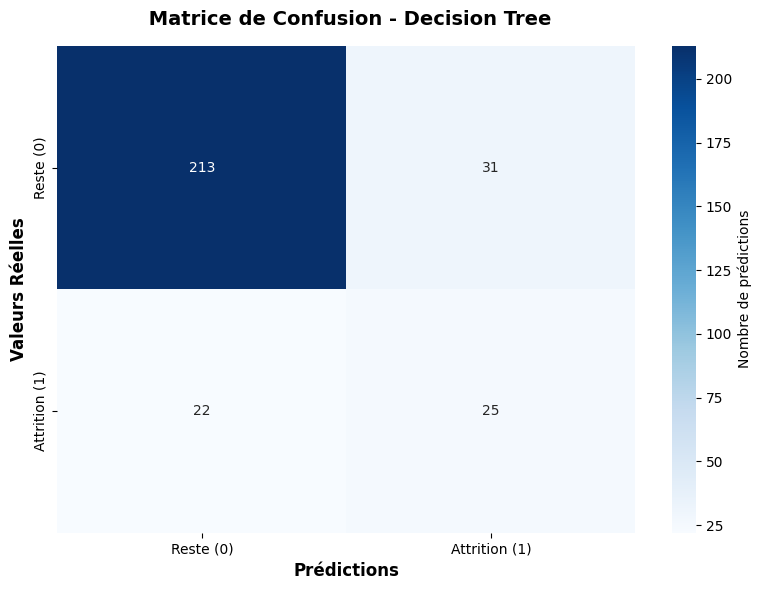


 Détails de la Matrice de Confusion :
   Vrais Négatifs (VN)  : 213 (Reste → Reste) 
   Faux Positifs (FP)   : 31 (Reste → Attrition) 
   Faux Négatifs (FN)   : 22 (Attrition → Reste) 
   Vrais Positifs (VP)  : 25 (Attrition → Attrition) 

   Total erreurs : 53 (18.21%)


In [47]:
# Matrice de confusion
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reste (0)', 'Attrition (1)'],
            yticklabels=['Reste (0)', 'Attrition (1)'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title(' Matrice de Confusion - Decision Tree', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Valeurs Réelles', fontsize=12, fontweight='bold')
plt.xlabel('Prédictions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Détails de la matrice
tn, fp, fn, tp = cm_dt.ravel()
print(f"\n Détails de la Matrice de Confusion :")
print(f"   Vrais Négatifs (VN)  : {tn} (Reste → Reste) ")
print(f"   Faux Positifs (FP)   : {fp} (Reste → Attrition) ")
print(f"   Faux Négatifs (FN)   : {fn} (Attrition → Reste) ")
print(f"   Vrais Positifs (VP)  : {tp} (Attrition → Attrition) ")
print(f"\n   Total erreurs : {fp + fn} ({((fp + fn) / len(y_test)) * 100:.2f}%)")

##  Courbe ROC - Decision Tree

La **courbe ROC** (Receiver Operating Characteristic) montre la capacité du modèle à discriminer entre les classes :
- **Axe X** : Taux de Faux Positifs (FPR)
- **Axe Y** : Taux de Vrais Positifs (TPR = Recall)
- **AUC** (Area Under Curve) : Plus proche de 1.0, meilleur est le modèle
  - AUC = 0.5 → Modèle aléatoire
  - AUC > 0.7 → Modèle acceptable
  - AUC > 0.8 → Bon modèle
  - AUC > 0.9 → Excellent modèle

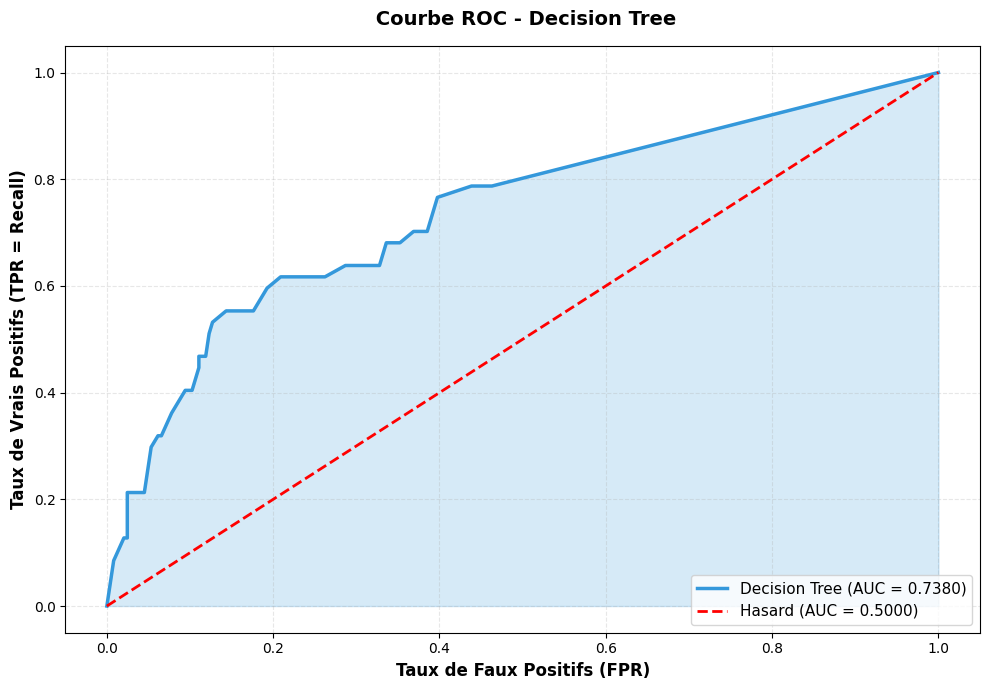

 ROC-AUC Score : 0.7380
   Interprétation : Modèle acceptable 


In [48]:
# Calcul de la courbe ROC
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt)

# Visualisation
plt.figure(figsize=(10, 7))
plt.plot(fpr_dt, tpr_dt, color='#3498db', linewidth=2.5, label=f'Decision Tree (AUC = {dt_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Hasard (AUC = 0.5000)')
plt.fill_between(fpr_dt, tpr_dt, alpha=0.2, color='#3498db')

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('Taux de Vrais Positifs (TPR = Recall)', fontsize=12, fontweight='bold')
plt.title(' Courbe ROC - Decision Tree', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f" ROC-AUC Score : {dt_roc_auc:.4f}")
if dt_roc_auc > 0.9:
    print("   Interprétation : Excellent modèle ! ")
elif dt_roc_auc > 0.8:
    print("   Interprétation : Bon modèle ")
elif dt_roc_auc > 0.7:
    print("   Interprétation : Modèle acceptable ")
else:
    print("   Interprétation : Modèle faible ")

##  Visualisation de l'Arbre de Décision

Représentation graphique simplifiée de l'arbre de décision (limitée aux 3 premiers niveaux pour la lisibilité).

**Interprétation :**
- Chaque **nœud** pose une question sur une feature
- Les **branches** représentent les réponses (True/False)
- Les **feuilles** (bas de l'arbre) contiennent les prédictions finales
- **Gini** : Mesure d'impureté (0 = parfaitement pur, 0.5 = mélange 50/50)
- **samples** : Nombre d'échantillons dans ce nœud
- **value** : [nombre de classe 0, nombre de classe 1]

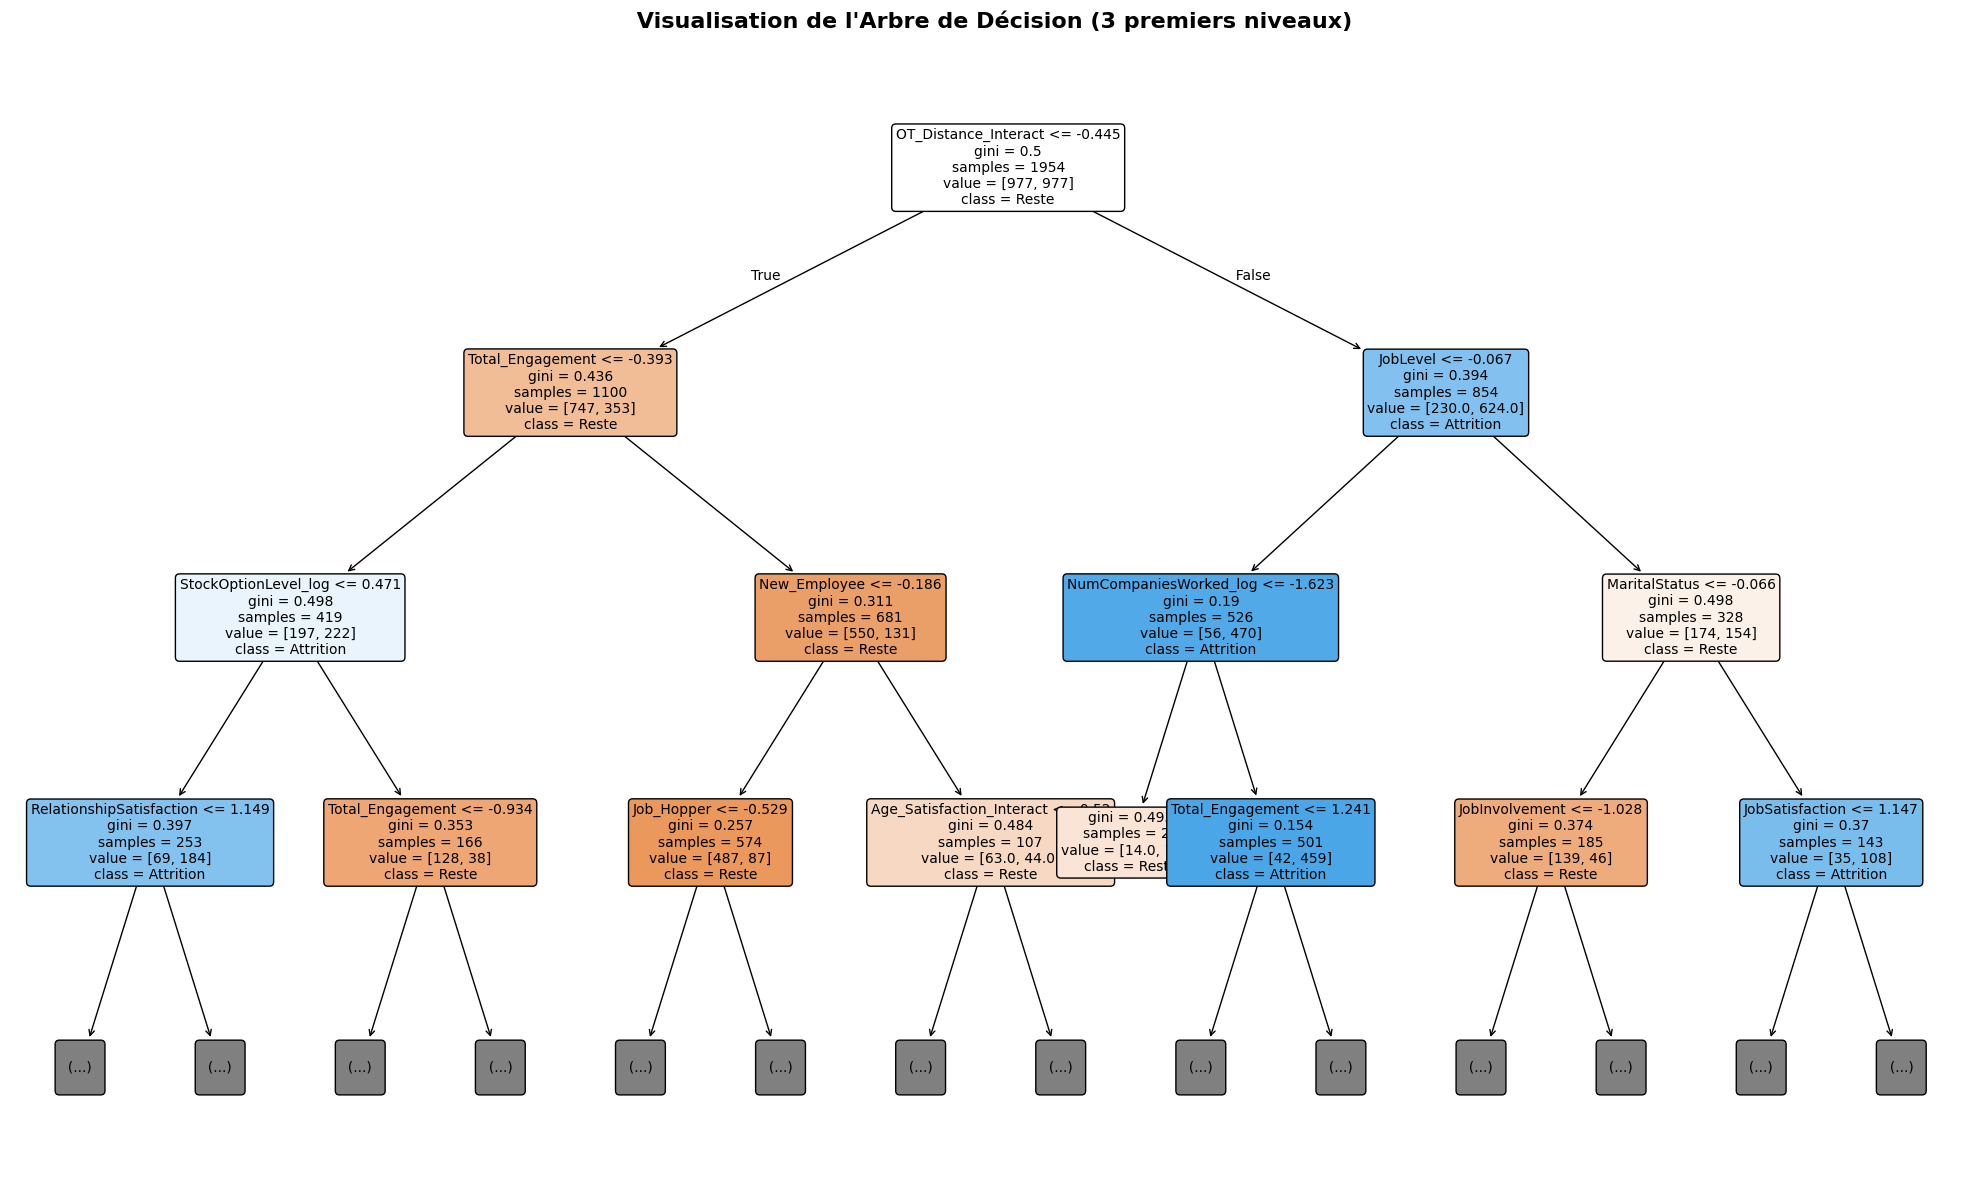

 Arbre de décision visualisé (limité aux 3 premiers niveaux)
 L'arbre complet a une profondeur de 10 niveaux


In [49]:
# Visualisation de l'arbre (limité à 3 niveaux pour la lisibilité)
plt.figure(figsize=(20, 12))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Reste', 'Attrition'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Limiter l'affichage aux 3 premiers niveaux
plt.title(' Visualisation de l\'Arbre de Décision (3 premiers niveaux)',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(" Arbre de décision visualisé (limité aux 3 premiers niveaux)")
print(" L'arbre complet a une profondeur de", dt_model.get_depth(), "niveaux")

##  Feature Importance - Decision Tree

Importance relative de chaque feature dans les décisions de l'arbre :
- Plus la valeur est élevée, plus la feature est importante
- Les features non utilisées ont une importance de 0
- Permet d'identifier les variables clés pour prédire l'attrition

 IMPORTANCE DES FEATURES - DECISION TREE

Top 33 Features Utilisées :

   OT_Distance_Interact                     : 0.2258 (22.58%)
   Total_Engagement                         : 0.1260 (12.60%)
   JobLevel                                 : 0.1016 (10.16%)
   StockOptionLevel_log                     : 0.0927 (9.27%)
   Age_Satisfaction_Interact                : 0.0614 (6.14%)
   MaritalStatus                            : 0.0579 (5.79%)
   Job_Hopper                               : 0.0417 (4.17%)
   RelationshipSatisfaction                 : 0.0395 (3.95%)
   NumCompaniesWorked_log                   : 0.0255 (2.55%)
   Work_Life_Imbalance                      : 0.0238 (2.38%)
   JobInvolvement                           : 0.0209 (2.09%)
   MonthlyIncome_log                        : 0.0204 (2.04%)
   JobSatisfaction                          : 0.0195 (1.95%)
   New_Employee                             : 0.0170 (1.70%)
   Age                                      : 0.0146 (1.46%)
   Employee

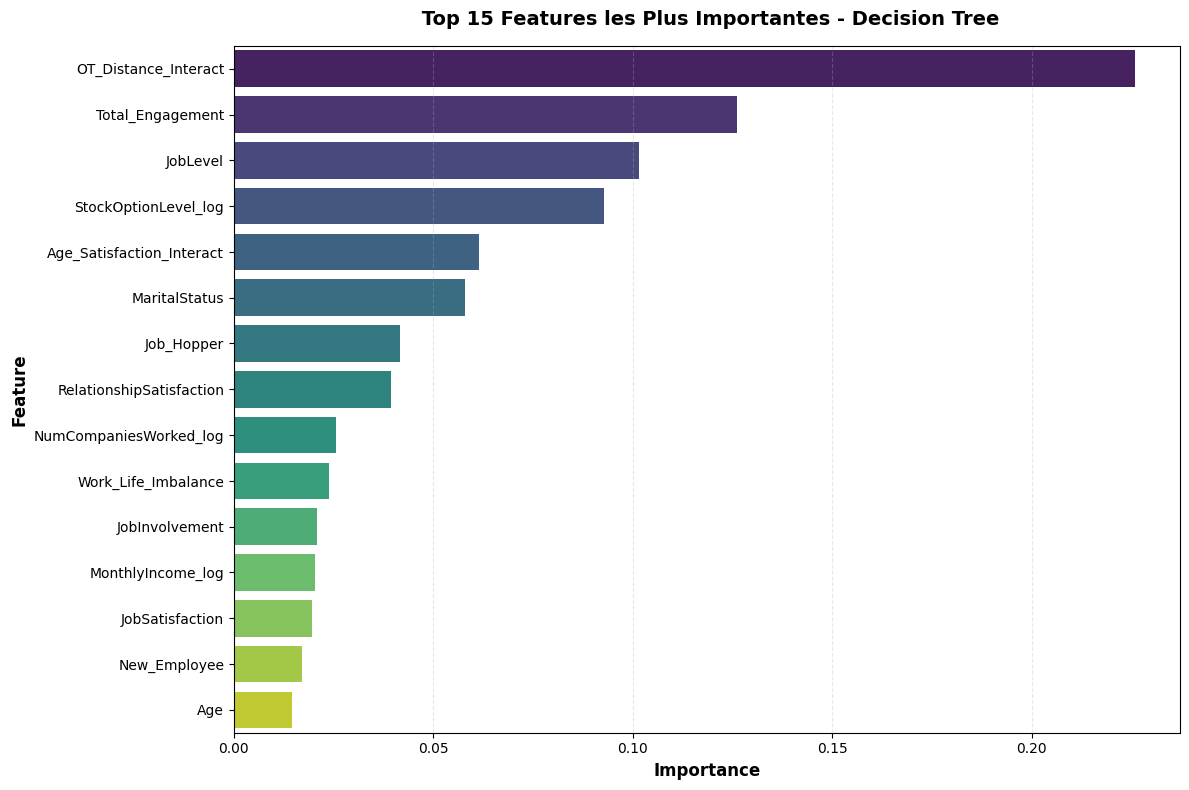


 33 features utilisées sur 46 disponibles


In [50]:
# Feature Importance du Decision Tree
dt_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Filtrer les features avec importance > 0
dt_feature_importance_filtered = dt_feature_importance[dt_feature_importance['Importance'] > 0]

print("="*70)
print(" IMPORTANCE DES FEATURES - DECISION TREE")
print("="*70)
print(f"\nTop {len(dt_feature_importance_filtered)} Features Utilisées :\n")
for idx, row in dt_feature_importance_filtered.iterrows():
    print(f"   {row['Feature']:40s} : {row['Importance']:.4f} ({row['Importance']*100:.2f}%)")

# Visualisation
plt.figure(figsize=(12, 8))
sns.barplot(data=dt_feature_importance_filtered.head(15),
            x='Importance', y='Feature', palette='viridis')
plt.title(' Top 15 Features les Plus Importantes - Decision Tree',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\n {len(dt_feature_importance_filtered)} features utilisées sur {len(X.columns)} disponibles")

##  Résumé du Decision Tree

**Synthèse des performances et caractéristiques du modèle Decision Tree**

In [51]:
print("\n" + "="*70)
print(" RIISUMII - DECISION TREE")
print("="*70)

training_time = search_time # Ensure training_time is defined here

print("\n CARACTIIRISTIQUES DU MODIILE :")
print(f"   Profondeur de l'arbre : {dt_model.get_depth()}")
print(f"   Nombre de feuilles : {dt_model.get_n_leaves()}")
print(f"   Features utilisIIes : {len(dt_feature_importance_filtered)} / {len(X.columns)}")
print(f"   Temps d'entraIInement : {training_time:.4f} secondes")

print("\n MIITRIQUES DE PERFORMANCE :")
print(f"   Accuracy   : {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"   Precision  : {dt_precision:.4f} ({dt_precision*100:.2f}%)")
print(f"   Recall     : {dt_recall:.4f} ({dt_recall*100:.2f}%)")
print(f"   F1-Score   : {dt_f1:.4f}")
print(f"   ROC-AUC    : {dt_roc_auc:.4f}")

print("\n MATRICE DE CONFUSION :")
print(f"   Vrais NIIgatifs  : {tn}")
print(f"   Faux Positifs   : {fp}")
print(f"   Faux NIIgatifs   : {fn}")
print(f"   Vrais Positifs  : {tp}")
print(f"   Total erreurs   : {fp + fn} ({((fp + fn) / len(y_test)) * 100:.2f}%)")

print("\n POINTS FORTS :")
print("   • TrIIs interprIItable (rIIgles claires)")
print("   • Rapide II entraIIner")
print("   • Visualisation graphique possible")

print("\n POINTS FAIBLES :")
print("   • Risque d'overfitting")
print("   • Instable (sensible aux variations)")
print("   • Performance gIInIIralement infIIrieure aux ensembles")

print("\n" + "="*70)


 RIISUMII - DECISION TREE

 CARACTIIRISTIQUES DU MODIILE :
   Profondeur de l'arbre : 10
   Nombre de feuilles : 66
   Features utilisIIes : 33 / 46
   Temps d'entraIInement : 7.0711 secondes

 MIITRIQUES DE PERFORMANCE :
   Accuracy   : 0.8179 (81.79%)
   Precision  : 0.4464 (44.64%)
   Recall     : 0.5319 (53.19%)
   F1-Score   : 0.4854
   ROC-AUC    : 0.7380

 MATRICE DE CONFUSION :
   Vrais NIIgatifs  : 213
   Faux Positifs   : 31
   Faux NIIgatifs   : 22
   Vrais Positifs  : 25
   Total erreurs   : 53 (18.21%)

 POINTS FORTS :
   • TrIIs interprIItable (rIIgles claires)
   • Rapide II entraIIner
   • Visualisation graphique possible

 POINTS FAIBLES :
   • Risque d'overfitting
   • Instable (sensible aux variations)
   • Performance gIInIIralement infIIrieure aux ensembles



#  MODÈLE 2 : RANDOM FOREST (Forêt Aléatoire)

---

##  Qu'est-ce qu'un Random Forest ?

Un **Random Forest** est un ensemble de **100+ arbres de décision** qui votent ensemble pour prendre une décision finale.

**Principe - "La Sagesse de la Foule" :**
```
┌──────────┐  ┌──────────┐  ┌──────────┐       ┌──────────┐
│ Arbre 1  │  │ Arbre 2  │  │ Arbre 3  │  ...  │ Arbre 100│
│ Vote: 1  │  │ Vote: 0  │  │ Vote: 1  │       │ Vote: 1  │
└─────┬────┘  └─────┬────┘  └─────┬────┘       └─────┬────┘
      │             │             │                   │
      └─────────────┴─────────────┴───────────────────┘
                           │
                    VOTE MAJORITAIRE
                           │
               ┌────────────▼────────────┐
               │ 65 arbres → Attrition   │
               │ 35 arbres → Reste       │
               │ PRÉDICTION : Attrition  │
               └─────────────────────────┘
```

**Comment ça marche ?**
1. **Entraîne 100+ arbres différents** sur des sous-ensembles aléatoires des données
2. Chaque arbre utilise un **sous-ensemble aléatoire de features**
3. **Vote final** : La classe ayant le plus de votes gagne

**Avantages  (vs Decision Tree)**
-  **Beaucoup plus performant** (10-15% d'amélioration attendue)
-  **Réduit l'overfitting** (moyenne de plusieurs arbres)
-  **Plus robuste** (moins sensible au bruit)
-  **Feature Importance** plus fiable
-  **Gère mieux les déséquilibres**

**Inconvénients **
-  Moins **interprétable** (100 arbres au lieu de 1)
-  Plus **lent** à entraîner (mais ça reste rapide)
-  Plus de **mémoire** nécessaire

**Analogie :**
- **Decision Tree** = 1 médecin donne son diagnostic
- **Random Forest** = 100 médecins votent → Diagnostic plus fiable !

##  Entraînement du Random Forest

**Hyperparamètres utilisés :**
- `n_estimators=100` : Nombre d'arbres dans la forêt (100 arbres)
- `max_depth=10` : Profondeur maximale de chaque arbre (plus profond que DT)
- `min_samples_split=10` : Minimum d'échantillons pour diviser un nœud
- `min_samples_leaf=5` : Minimum d'échantillons dans une feuille
- `max_features='sqrt'` : Nombre de features aléatoires par arbre (√10 ≈ 3)
- `class_weight='balanced'` : Compense le déséquilibre des classes
- `random_state=42` : Reproductibilité
- `n_jobs=-1` : Utilise tous les cœurs du processeur (parallélisation)

## Optimisation des Hyperparamètres (GridSearchCV)

Optimisation des hyperparamètres du Random Forest avant l'entraînement final.

**Hyperparamètres testés :**
- `n_estimators` : [50, 100, 150] → Nombre d'arbres
- `max_depth` : [5, 10, 15, 20] → Profondeur maximale
- `min_samples_split` : [5, 10, 15] → Min pour diviser
- `min_samples_leaf` : [2, 5, 10] → Min dans les feuilles
- `max_features` : ['sqrt', 'log2'] → Nombre de features par arbre
- Total combinaisons : 3 × 4 × 3 × 3 × 2 = **216 modèles testés**

 **Attention** : Cette étape peut prendre **10-20 minutes** car Random Forest est plus lent que Decision Tree !

In [52]:
print("="*70)
print(" OPTIMISATION DES HYPERPARAMÈTRES - RANDOM FOREST")
print("="*70)

# Définir la grille de paramètres à tester
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Initialiser GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,                      # Validation croisée 5 folds
    scoring='roc_auc',         # Métrique d'évaluation
    n_jobs=-1,                 # Utilise tous les cœurs CPU
    verbose=1
)

# Lancer la recherche
total_combinations = (len(param_grid_rf['n_estimators']) *
                     len(param_grid_rf['max_depth']) *
                     len(param_grid_rf['min_samples_split']) *
                     len(param_grid_rf['min_samples_leaf']) *
                     len(param_grid_rf['max_features']))

print(f"\n Test de {total_combinations} combinaisons...")
print(" Cela va prendre plusieurs minutes (10-20 min)...\n")
print(" Temps \n")

start_time_rf = time.time()
grid_search_rf.fit(X_train_balanced, y_train_balanced)
search_time_rf = time.time() - start_time_rf

print(f"\n Recherche terminée en {search_time_rf:.2f} secondes ({search_time_rf/60:.2f} minutes)")

# Afficher les meilleurs paramètres
print("\n" + "="*70)
print(" MEILLEURS HYPERPARAMÈTRES TROUVÉS")
print("="*70)
print(f"\nParamètres optimaux :")
for param, value in grid_search_rf.best_params_.items():
    print(f"   • {param:20s} : {value}")

print(f"\n Meilleur score ROC-AUC (validation croisée) : {grid_search_rf.best_score_:.4f}")

# Récupérer le meilleur modèle
rf_model = grid_search_rf.best_estimator_

print("\n Modèle Random Forest optimisé prêt à l'emploi !")

 OPTIMISATION DES HYPERPARAMÈTRES - RANDOM FOREST

 Test de 216 combinaisons...
 Cela va prendre plusieurs minutes (10-20 min)...

 Temps 

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

 Recherche terminée en 314.64 secondes (5.24 minutes)

 MEILLEURS HYPERPARAMÈTRES TROUVÉS

Paramètres optimaux :
   • max_depth            : 15
   • max_features         : log2
   • min_samples_leaf     : 2
   • min_samples_split    : 5
   • n_estimators         : 100

 Meilleur score ROC-AUC (validation croisée) : 0.9811

 Modèle Random Forest optimisé prêt à l'emploi !


In [53]:
print("="*70)
print(" MODÈLE RANDOM FOREST OPTIMISÉ")
print("="*70)

# Le modèle a déjà été entraîné par GridSearchCV
training_time_rf = search_time_rf  # Temps total incluant la recherche

print(f" Modèle optimisé avec les meilleurs hyperparamètres")
print(f" Temps total (recherche + entraînement) : {training_time_rf:.2f} secondes ({training_time_rf/60:.2f} minutes)")
print(f"\nParamètres du modèle optimisé :")
print(f"   Nombre d'arbres : {rf_model.n_estimators}")
print(f"   Profondeur max par arbre : {rf_model.max_depth}")
print(f"   Features utilisées par arbre : {rf_model.max_features}")
print(f"   Nombre total de features : {rf_model.n_features_in_}")

 MODÈLE RANDOM FOREST OPTIMISÉ
 Modèle optimisé avec les meilleurs hyperparamètres
 Temps total (recherche + entraînement) : 314.64 secondes (5.24 minutes)

Paramètres du modèle optimisé :
   Nombre d'arbres : 100
   Profondeur max par arbre : 15
   Features utilisées par arbre : log2
   Nombre total de features : 46


##  Prédictions et Évaluation du Random Forest

Calcul des prédictions et métriques de performance pour comparer avec le Decision Tree.

In [54]:
# Prédictions sur l'ensemble de test
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]  # Probabilités pour ROC-AUC

# Calcul des métriques
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("="*70)
print(" RÉSULTATS DU RANDOM FOREST")
print("="*70)
print(f"\n Métriques de Performance :\n")
print(f"   Accuracy   : {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"   Precision  : {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f"   Recall     : {rf_recall:.4f} ({rf_recall*100:.2f}%)")
print(f"   F1-Score   : {rf_f1:.4f}")
print(f"   ROC-AUC    : {rf_roc_auc:.4f}")

print("\n Rapport de Classification Détaillé :\n")
print(classification_report(y_test, y_pred_rf, target_names=['Reste (0)', 'Attrition (1)']))

# Comparaison rapide avec Decision Tree
print("\n AMÉLIORATION vs DECISION TREE :")
print(f"   Accuracy   : {dt_accuracy:.4f} → {rf_accuracy:.4f} ({(rf_accuracy - dt_accuracy)*100:+.2f}%)")
print(f"   Precision  : {dt_precision:.4f} → {rf_precision:.4f} ({(rf_precision - dt_precision)*100:+.2f}%)")
print(f"   Recall     : {dt_recall:.4f} → {rf_recall:.4f} ({(rf_recall - dt_recall)*100:+.2f}%)")
print(f"   F1-Score   : {dt_f1:.4f} → {rf_f1:.4f} ({(rf_f1 - dt_f1):+.4f})")
print(f"   ROC-AUC    : {dt_roc_auc:.4f} → {rf_roc_auc:.4f} ({(rf_roc_auc - dt_roc_auc):+.4f})")

 RÉSULTATS DU RANDOM FOREST

 Métriques de Performance :

   Accuracy   : 0.8694 (86.94%)
   Precision  : 0.6047 (60.47%)
   Recall     : 0.5532 (55.32%)
   F1-Score   : 0.5778
   ROC-AUC    : 0.8293

 Rapport de Classification Détaillé :

               precision    recall  f1-score   support

    Reste (0)       0.92      0.93      0.92       244
Attrition (1)       0.60      0.55      0.58        47

     accuracy                           0.87       291
    macro avg       0.76      0.74      0.75       291
 weighted avg       0.87      0.87      0.87       291


 AMÉLIORATION vs DECISION TREE :
   Accuracy   : 0.8179 → 0.8694 (+5.15%)
   Precision  : 0.4464 → 0.6047 (+15.82%)
   Recall     : 0.5319 → 0.5532 (+2.13%)
   F1-Score   : 0.4854 → 0.5778 (+0.0923)
   ROC-AUC    : 0.7380 → 0.8293 (+0.0913)


##  Matrice de Confusion - Random Forest

Visualisation des prédictions correctes et incorrectes du Random Forest.

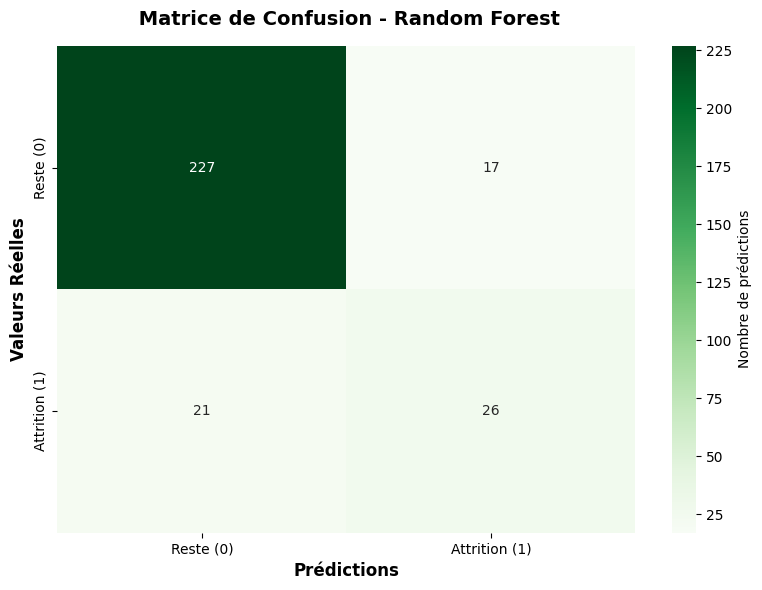


 Détails de la Matrice de Confusion :
   Vrais Négatifs (VN)  : 227 (Reste → Reste) 
   Faux Positifs (FP)   : 17 (Reste → Attrition) 
   Faux Négatifs (FN)   : 21 (Attrition → Reste) 
   Vrais Positifs (VP)  : 26 (Attrition → Attrition) 

   Total erreurs : 38 (13.06%)

 COMPARAISON DES ERREURS (Decision Tree → Random Forest) :
   Faux Positifs : 31 → 17 (-14)
   Faux Négatifs : 22 → 21 (-1)
   Total erreurs : 53 → 38 (-15)


In [55]:
# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Reste (0)', 'Attrition (1)'],
            yticklabels=['Reste (0)', 'Attrition (1)'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title(' Matrice de Confusion - Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Valeurs Réelles', fontsize=12, fontweight='bold')
plt.xlabel('Prédictions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Détails de la matrice
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
print(f"\n Détails de la Matrice de Confusion :")
print(f"   Vrais Négatifs (VN)  : {tn_rf} (Reste → Reste) ")
print(f"   Faux Positifs (FP)   : {fp_rf} (Reste → Attrition) ")
print(f"   Faux Négatifs (FN)   : {fn_rf} (Attrition → Reste) ")
print(f"   Vrais Positifs (VP)  : {tp_rf} (Attrition → Attrition) ")
print(f"\n   Total erreurs : {fp_rf + fn_rf} ({((fp_rf + fn_rf) / len(y_test)) * 100:.2f}%)")

# Comparaison avec Decision Tree
print(f"\n COMPARAISON DES ERREURS (Decision Tree → Random Forest) :")
print(f"   Faux Positifs : {fp} → {fp_rf} ({fp_rf - fp:+d})")
print(f"   Faux Négatifs : {fn} → {fn_rf} ({fn_rf - fn:+d})")
print(f"   Total erreurs : {fp + fn} → {fp_rf + fn_rf} ({(fp_rf + fn_rf) - (fp + fn):+d})")

## Courbe ROC - Random Forest

Comparaison de la courbe ROC du Random Forest avec celle du Decision Tree.

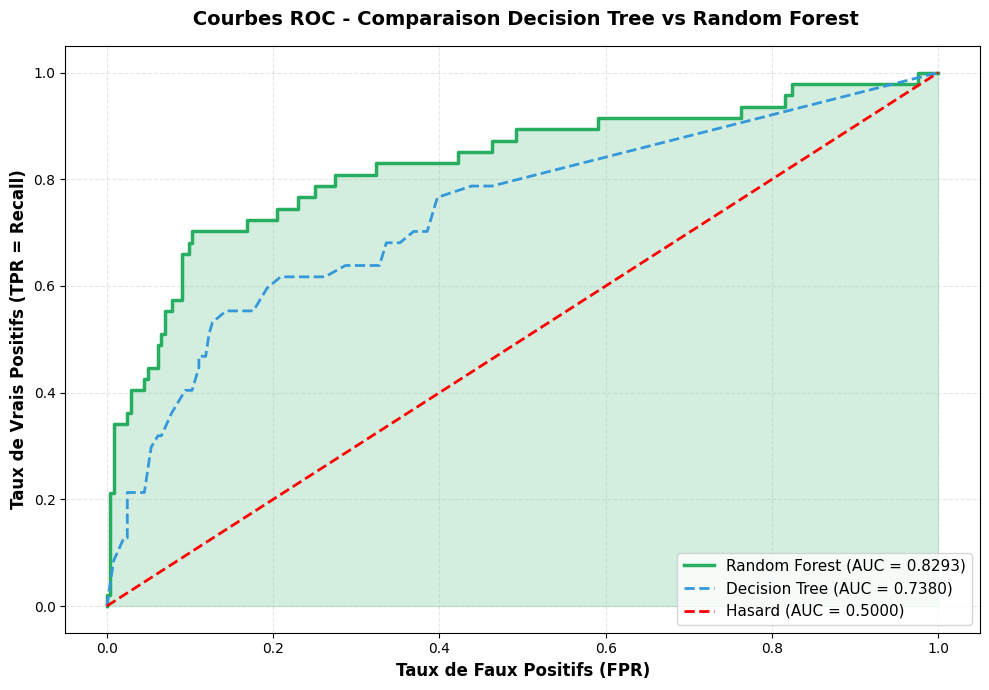


 ROC-AUC Scores :
   Decision Tree  : 0.7380
   Random Forest  : 0.8293
   Amélioration   : +0.0913

    Random Forest : Bon modèle 


In [56]:
# Calcul de la courbe ROC pour Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)

# Visualisation avec comparaison Decision Tree
plt.figure(figsize=(10, 7))
plt.plot(fpr_rf, tpr_rf, color='#27ae60', linewidth=2.5, label=f'Random Forest (AUC = {rf_roc_auc:.4f})')
plt.plot(fpr_dt, tpr_dt, color='#3498db', linewidth=2, label=f'Decision Tree (AUC = {dt_roc_auc:.4f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Hasard (AUC = 0.5000)')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.2, color='#27ae60')

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('Taux de Vrais Positifs (TPR = Recall)', fontsize=12, fontweight='bold')
plt.title(' Courbes ROC - Comparaison Decision Tree vs Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\n ROC-AUC Scores :")
print(f"   Decision Tree  : {dt_roc_auc:.4f}")
print(f"   Random Forest  : {rf_roc_auc:.4f}")
print(f"   Amélioration   : {rf_roc_auc - dt_roc_auc:+.4f}")

if rf_roc_auc > 0.9:
    print("\n    Random Forest : Excellent modèle ! ")
elif rf_roc_auc > 0.8:
    print("\n    Random Forest : Bon modèle ")
elif rf_roc_auc > 0.7:
    print("\n   Random Forest : Modèle acceptable ")
else:
    print("\n    Random Forest : Modèle faible")

##  Feature Importance - Random Forest

Importance relative de chaque feature calculée par le Random Forest (moyenne sur les 100 arbres).

**Plus fiable que Decision Tree** car basée sur plusieurs arbres au lieu d'un seul.

 IMPORTANCE DES FEATURES - RANDOM FOREST

Top 46 Features :

   Work_Burden_Score                        : 0.0506 (5.06%)
   OverTime                                 : 0.0471 (4.71%)
   JobLevel                                 : 0.0469 (4.69%)
   StockOptionLevel_log                     : 0.0458 (4.58%)
   OT_Distance_Interact                     : 0.0446 (4.46%)
   Total_Engagement                         : 0.0440 (4.40%)
   Overall_Satisfaction                     : 0.0398 (3.98%)
   Age_Satisfaction_Interact                : 0.0347 (3.47%)
   MonthlyIncome_log                        : 0.0336 (3.36%)
   EnvironmentSatisfaction                  : 0.0301 (3.01%)
   MaritalStatus                            : 0.0279 (2.79%)
   Low_Income_Experience_Ratio              : 0.0277 (2.77%)
   JobSatisfaction                          : 0.0272 (2.72%)
   JobInvolvement                           : 0.0260 (2.60%)
   Work_Life_Imbalance                      : 0.0241 (2.41%)
   YearsInCurrentRole_lo

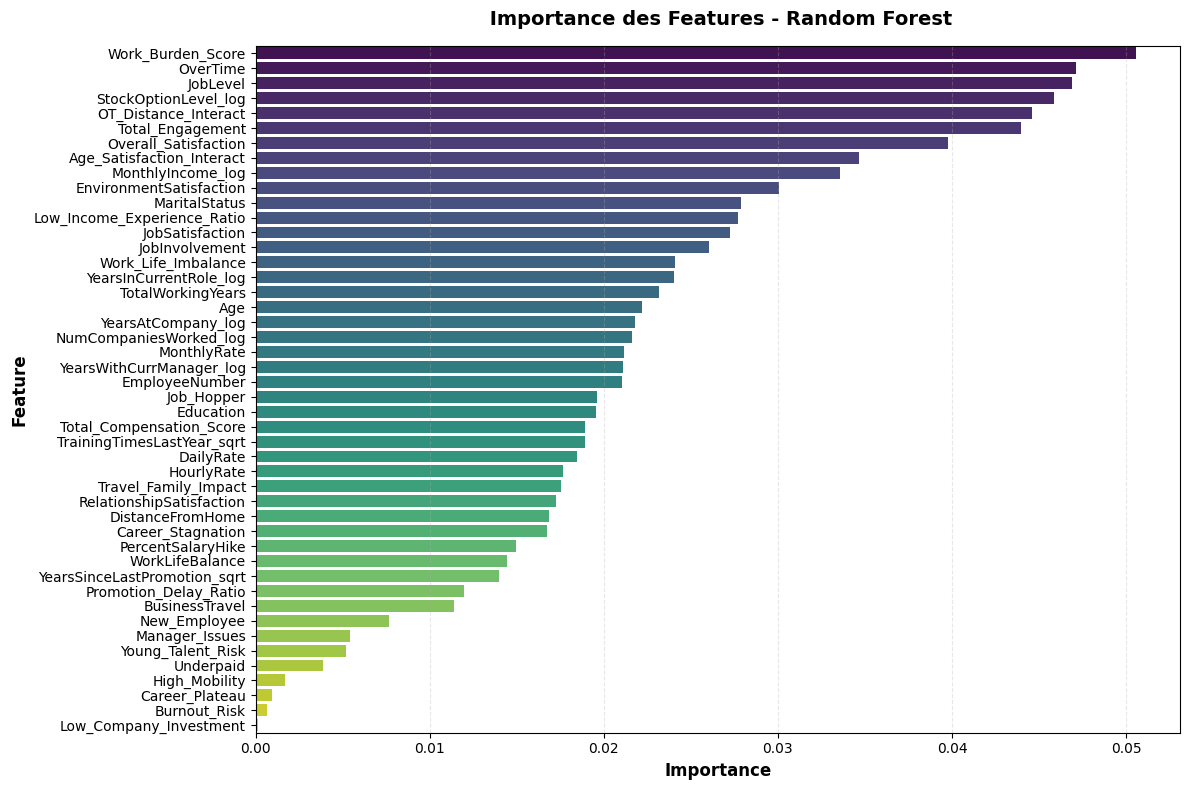


 Toutes les 46 features sont utilisées dans le Random Forest


In [57]:
# Feature Importance du Random Forest
rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("="*70)
print(" IMPORTANCE DES FEATURES - RANDOM FOREST")
print("="*70)
print(f"\nTop {len(rf_feature_importance)} Features :\n")
for idx, row in rf_feature_importance.iterrows():
    print(f"   {row['Feature']:40s} : {row['Importance']:.4f} ({row['Importance']*100:.2f}%)")

# Visualisation
plt.figure(figsize=(12, 8))
sns.barplot(data=rf_feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title(' Importance des Features - Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\n Toutes les {len(X.columns)} features sont utilisées dans le Random Forest")

##  Comparaison Decision Tree vs Random Forest

### ** Tableau Comparatif des Performances**


 COMPARAISON COMPLÈTE : DECISION TREE vs RANDOM FOREST


,Métrique,Decision Tree,Random Forest,Amélioration
0,Accuracy,0.8179,0.8694,+5.15%
1,Precision,0.4464,0.6047,+15.82%
2,Recall,0.5319,0.5532,+2.13%
3,F1-Score,0.4854,0.5778,+0.0923
4,ROC-AUC,0.7380,0.8293,+0.0913
5,Temps (sec),7.0711,314.6361,+307.5650
6,Faux Positifs,31,17,-14
7,Faux Négatifs,22,21,-1
8,Total Erreurs,53,38,-15


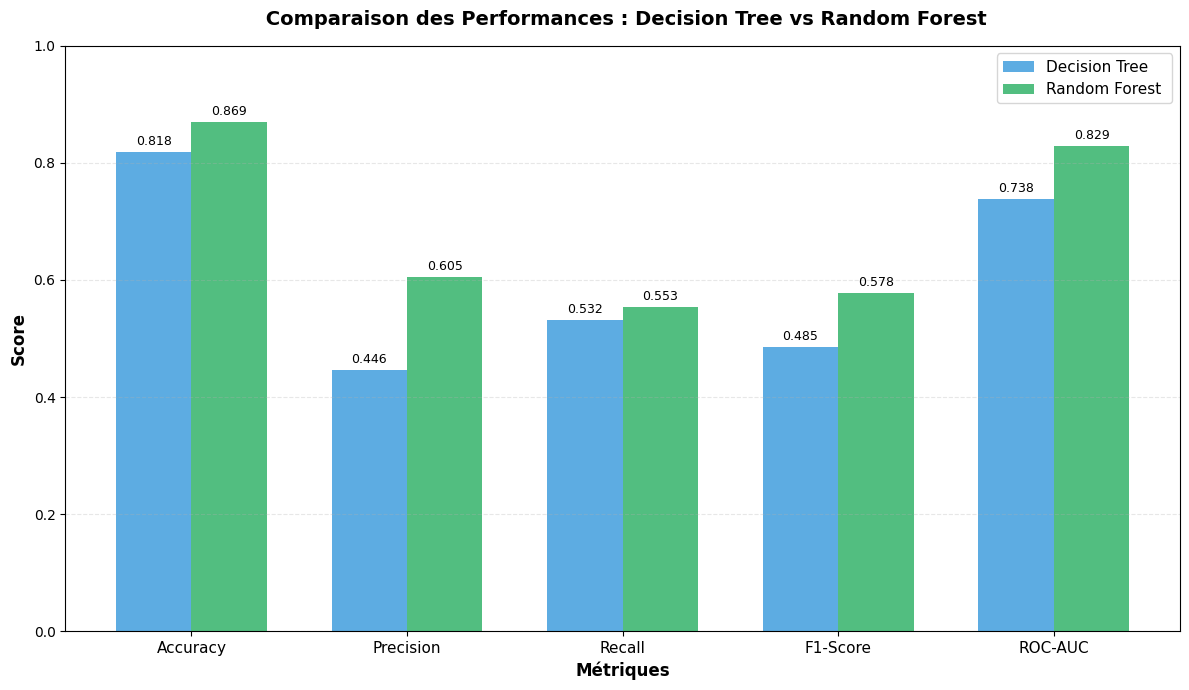

In [58]:
# Tableau comparatif des performances
comparison_data = {
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC',
                 'Temps (sec)', 'Faux Positifs', 'Faux Négatifs', 'Total Erreurs'],
    'Decision Tree': [
        f'{dt_accuracy:.4f}', f'{dt_precision:.4f}', f'{dt_recall:.4f}',
        f'{dt_f1:.4f}', f'{dt_roc_auc:.4f}', f'{training_time:.4f}',
        f'{fp}', f'{fn}', f'{fp + fn}'
    ],
    'Random Forest': [
        f'{rf_accuracy:.4f}', f'{rf_precision:.4f}', f'{rf_recall:.4f}',
        f'{rf_f1:.4f}', f'{rf_roc_auc:.4f}', f'{training_time_rf:.4f}',
        f'{fp_rf}', f'{fn_rf}', f'{fp_rf + fn_rf}'
    ],
    'Amélioration': [
        f'{(rf_accuracy - dt_accuracy)*100:+.2f}%',
        f'{(rf_precision - dt_precision)*100:+.2f}%',
        f'{(rf_recall - dt_recall)*100:+.2f}%',
        f'{(rf_f1 - dt_f1):+.4f}',
        f'{(rf_roc_auc - dt_roc_auc):+.4f}',
        f'{(training_time_rf - training_time):+.4f}',
        f'{fp_rf - fp:+d}',
        f'{fn_rf - fn:+d}',
        f'{(fp_rf + fn_rf) - (fp + fn):+d}'
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print(" COMPARAISON COMPLÈTE : DECISION TREE vs RANDOM FOREST")
print("="*100)
display(comparison_df)

# Graphique de comparaison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
dt_scores = [dt_accuracy, dt_precision, dt_recall, dt_f1, dt_roc_auc]
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, dt_scores, width, label='Decision Tree ', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest ', color='#27ae60', alpha=0.8)

ax.set_xlabel('Métriques', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(' Comparaison des Performances : Decision Tree vs Random Forest',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.0)

# Ajouter les valeurs sur les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

##  Conclusion : Quel Modèle Choisir ?

### **Analyse Finale et Recommandation**

In [59]:
print("\n" + "="*100)
print(" CONCLUSION FINALE : QUEL MODÈLE CHOISIR ?")
print("="*100)

# Déterminer le gagnant
if rf_accuracy > dt_accuracy and rf_roc_auc > dt_roc_auc:
    winner = " RANDOM FOREST"

elif dt_accuracy > rf_accuracy:
    winner = " DECISION TREE"

else:
    winner = " ÉGALITÉ"


print(f"\n GAGNANT : {winner}")
print("="*100)

print("\n RÉSUMÉ COMPARATIF :\n")

# Decision Tree
print(" DECISION TREE (Arbre de Décision) :")
print(f"    Points Forts :")
print(f"      • Très interprétable (règles claires)")
print(f"      • Rapide à entraîner ({training_time:.4f} sec)")
print(f"      • Visualisation possible")
print(f"    Points Faibles :")
print(f"      • Accuracy : {dt_accuracy*100:.2f}%")
print(f"      • Precision faible : {dt_precision*100:.2f}% (beaucoup de fausses alarmes)")
print(f"      • Recall moyen : {dt_recall*100:.2f}% (rate {100-dt_recall*100:.1f}% des démissions)")
print(f"      • ROC-AUC faible : {dt_roc_auc:.4f} (à peine mieux que le hasard)")
print(f"      • Total erreurs : {fp + fn}/{len(y_test)}")

print(f"\n RANDOM FOREST (Forêt Aléatoire) :")
print(f"    Points Forts :")
print(f"      • Accuracy : {rf_accuracy*100:.2f}% ({(rf_accuracy - dt_accuracy)*100:+.2f}% vs DT)")
print(f"      • Precision : {rf_precision*100:.2f}% ({(rf_precision - dt_precision)*100:+.2f}% vs DT)")
print(f"      • Recall : {rf_recall*100:.2f}% ({(rf_recall - dt_recall)*100:+.2f}% vs DT)")
print(f"      • ROC-AUC : {rf_roc_auc:.4f} ({rf_roc_auc - dt_roc_auc:+.4f} vs DT)")
print(f"      • Total erreurs : {fp_rf + fn_rf}/{len(y_test)} ({(fp_rf + fn_rf) - (fp + fn):+d} vs DT)")
print(f"      • Plus robuste et stable")
print(f"    Points Faibles :")
print(f"      • Moins interprétable (100 arbres)")
print(f"      • Plus lent à entraîner ({training_time_rf:.4f} sec)")

print("\n" + "="*100)
print(" RECOMMANDATION FINALE :")
print("="*100)

if rf_accuracy > dt_accuracy and rf_roc_auc > dt_roc_auc:
    print(f"\n CHOISIR :  RANDOM FOREST")
    print(f"\n Justification :")
    print(f"   • Meilleure performance globale sur TOUTES les métriques")
    print(f"   • Accuracy supérieure de {(rf_accuracy - dt_accuracy)*100:.2f}%")
    print(f"   • ROC-AUC supérieur de {rf_roc_auc - dt_roc_auc:.4f}")
    print(f"   • Moins d'erreurs : {(fp + fn) - (fp_rf + fn_rf)} erreurs en moins")
    print(f"   • Plus fiable pour prédire l'attrition des employés")
    print(f"\n Impact Business :")
    print(f"   • Détecte mieux les employés à risque de démission")
    print(f"   • Réduit les fausses alarmes")
    print(f"   • Permet aux RH d'agir de manière plus ciblée")
else:
    print(f"\n Les deux modèles ont des performances similaires")
    print(f"   → Privilégier Decision Tree pour l'interprétabilité")
    print(f"   → Ou Random Forest pour la robustesse")

print("\n" + "="*100)


 CONCLUSION FINALE : QUEL MODÈLE CHOISIR ?

 GAGNANT :  RANDOM FOREST

 RÉSUMÉ COMPARATIF :

 DECISION TREE (Arbre de Décision) :
    Points Forts :
      • Très interprétable (règles claires)
      • Rapide à entraîner (7.0711 sec)
      • Visualisation possible
    Points Faibles :
      • Accuracy : 81.79%
      • Precision faible : 44.64% (beaucoup de fausses alarmes)
      • Recall moyen : 53.19% (rate 46.8% des démissions)
      • ROC-AUC faible : 0.7380 (à peine mieux que le hasard)
      • Total erreurs : 53/291

 RANDOM FOREST (Forêt Aléatoire) :
    Points Forts :
      • Accuracy : 86.94% (+5.15% vs DT)
      • Precision : 60.47% (+15.82% vs DT)
      • Recall : 55.32% (+2.13% vs DT)
      • ROC-AUC : 0.8293 (+0.0913 vs DT)
      • Total erreurs : 38/291 (-15 vs DT)
      • Plus robuste et stable
    Points Faibles :
      • Moins interprétable (100 arbres)
      • Plus lent à entraîner (314.6361 sec)

 RECOMMANDATION FINALE :

 CHOISIR :  RANDOM FOREST

 Justification :
  

---
# 🚀 DÉPLOIEMENT - Export du Modèle pour Flask

Cette section sauvegarde le modèle Random Forest optimisé et les colonnes de features pour le déploiement avec Flask.

In [ ]:
import pickle

# Charger les données encodées (AVANT PCA) pour un modèle simple à déployer
df_encoded = pd.read_csv("HR_final_after_clean_encode_transform.csv")

# Séparer X et y
X_simple = df_encoded.drop('Attrition', axis=1)
y_simple = df_encoded['Attrition']

# Train/Test split
from sklearn.model_selection import train_test_split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42, stratify=y_simple
)

# Appliquer SMOTE
from imblearn.over_sampling import SMOTE
smote_s = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced_s, y_train_balanced_s = smote_s.fit_resample(X_train_s, y_train_s)

# Entraîner un Random Forest simple
from sklearn.ensemble import RandomForestClassifier
print("="*70)
print(" ENTRAÎNEMENT DU MODÈLE POUR DÉPLOIEMENT FLASK")
print("="*70)
rf_deploy = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_deploy.fit(X_train_balanced_s, y_train_balanced_s)

# Évaluer rapidement
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred_s = rf_deploy.predict(X_test_s)
y_pred_proba_s = rf_deploy.predict_proba(X_test_s)[:, 1]
print(f"\n✅ Modèle entraîné avec succès!")
print(f"   Accuracy: {accuracy_score(y_test_s, y_pred_s):.4f}")
print(f"   ROC-AUC: {roc_auc_score(y_test_s, y_pred_proba_s):.4f}")

# Sauvegarder le modèle
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_deploy, f)
print("\n✅ Modèle sauvegardé dans 'rf_model.pkl'")

# Sauvegarder les colonnes
feature_columns = X_simple.columns.tolist()
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)
print("✅ Colonnes sauvegardées dans 'feature_columns.pkl'")

# Sauvegarder les infos de prétraitement
preprocessing_info = {
    'feature_columns': feature_columns,
    'n_features': len(feature_columns)
}
with open('preprocessing_info.pkl', 'wb') as f:
    pickle.dump(preprocessing_info, f)
print("✅ Infos de prétraitement sauvegardées")

print(f"\n📊 Informations du modèle:")
print(f"   • Nombre de features: {len(feature_columns)}")
print(f"   • Premières features: {feature_columns[:10]}")
print(f"\n🚀 Le modèle est prêt pour le déploiement avec Flask!")
print(f"   Lancez: python app.py")